# Actividad final: ML interpretable (XAI)
En el siguiente trabajo se usa un dataset de Kaggle de un millón de filas que recoge el estado de salud mental de los jóvenes en relación a sus estudios. El objetiv del mismo es analizar los datos de forma descriptiva para ver posibles relaciones de la tasa de abandono de los estudios con las variables registradas. Después de desarrollar el EDA, se usarán los modelos de regresión logística, random  forest, XGboost, MLP y Tabular transformer (Pytorch) para comprobar la veracidad de la hipótesis derivada del EDA. Por último, se aplicarán algorítmos de interpretabilidad a los modelos para intentar entender su razonamiento interno. De todo esto se escribirán unas conclusiones finales al final del documento.  

## 1: Importación de librerias y preprocesado de los datos

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("ayeshasiddiqa123/student-health")

print("Path to dataset files:", path)

100%|██████████| 131M/131M [00:01<00:00, 106MB/s] 

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/ayeshasiddiqa123/student-health/versions/1


Librerias de modelos de interpretabilidad:

In [ ]:
!pip install shap
!pip install lime eli5
!pip install fairlearn
!pip install captum

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 4.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.4/108.4 kB 8.4 MB/s eta 0:00:00
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=630232722abbe946f2f8cad90bbb094df1932e1082d50091db7ef99676eecc41
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 251.6/251.6 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.3/37.3 MB 23.9 MB/s eta 0:00:00
  Attempting uninstall: scipy
    Found existing installation: scipy 1.16.3
    Uninstalling scipy-1.16.3:
      Successfully uninstalled scipy-1.16.3
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 455.2/455.2 kB 10.6 MB/s eta 0:00:00


Librerías de análisis de datos:

In [ ]:
!pip install SciPY
!pip install kaggle
!pip install PlotLy
!pip install pygwalker
!pip install seaborn
!pip install ydata_profiling

import pandas as pd
import pygwalker as pyg
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ydata_profiling import ProfileReport

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.8/4.8 MB 18.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 956.2/956.2 kB 30.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.2/100.2 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 24.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.7/9.7 MB 27.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.8/400.8 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 22.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 62.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.7/679.7 kB 42.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 6.4 MB/s eta 0:00:00


/tmp/ipykernel_5254/903470274.py:13: DeprecationWarning: 
    `import ydata_profiling` is deprecated and will not receive more updates. 
    Please install fg-data-profiling via `pip install fg-data-profiling` and use `import data_profiling` instead.
    
  from ydata_profiling import ProfileReport


Importamos los datos

In [ ]:
import pandas as pd
from google.colab import drive
drive.mount('/content/drive')
path = "/content/drive/My Drive/Colab Notebooks/Mineria/CSV/"
df = pd.read_csv(path + "student_mental_health_burnout_1M.csv")

Mounted at /content/drive


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 20 columns):
 #   Column                Non-Null Count    Dtype  
---  ------                --------------    -----  
 0   age                   1000000 non-null  int64  
 1   gender                1000000 non-null  object 
 2   academic_year         1000000 non-null  int64  
 3   study_hours_per_day   1000000 non-null  float64
 4   exam_pressure         1000000 non-null  float64
 5   academic_performance  1000000 non-null  float64
 6   stress_level          1000000 non-null  float64
 7   anxiety_score         1000000 non-null  float64
 8   depression_score      1000000 non-null  float64
 9   sleep_hours           1000000 non-null  float64
 10  physical_activity     1000000 non-null  float64
 11  social_support        1000000 non-null  float64
 12  screen_time           1000000 non-null  float64
 13  internet_usage        1000000 non-null  float64
 14  financial_stress      1000000 non-n

In [ ]:
df1 = df.copy()

In [ ]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 20 columns):
 #   Column                Non-Null Count    Dtype  
---  ------                --------------    -----  
 0   age                   1000000 non-null  int64  
 1   gender                1000000 non-null  object 
 2   academic_year         1000000 non-null  int64  
 3   study_hours_per_day   1000000 non-null  float64
 4   exam_pressure         1000000 non-null  float64
 5   academic_performance  1000000 non-null  float64
 6   stress_level          1000000 non-null  float64
 7   anxiety_score         1000000 non-null  float64
 8   depression_score      1000000 non-null  float64
 9   sleep_hours           1000000 non-null  float64
 10  physical_activity     1000000 non-null  float64
 11  social_support        1000000 non-null  float64
 12  screen_time           1000000 non-null  float64
 13  internet_usage        1000000 non-null  float64
 14  financial_stress      1000000 non-n

In [ ]:
df1.head()

,age,gender,academic_year,study_hours_per_day,exam_pressure,academic_performance,stress_level,anxiety_score,depression_score,sleep_hours,physical_activity,social_support,screen_time,internet_usage,financial_stress,family_expectation,burnout_score,mental_health_index,risk_level,dropout_risk
0,23,Male,2,5.596071,6.487218,68.411114,4.116950,2.275713,1.986730,6.880545,2.728861,6.470080,4.993801,4.983157,3.446626,3.586147,2.037344,7.074487,Low,1.746601
1,20,Male,3,5.597171,5.631481,67.682159,0.349489,0.000000,0.000000,7.463339,3.690866,0.000000,3.862980,5.136124,2.814039,5.478666,0.000000,9.860204,Low,0.000000
2,29,Male,2,2.580491,6.015297,58.372363,3.476177,2.425201,0.851996,8.946670,3.296720,6.901725,5.428880,3.058333,4.918515,6.068155,0.000000,7.626370,Low,0.696941
3,27,Male,4,4.607208,6.684005,68.925653,6.778843,4.512425,4.285645,4.571380,2.065480,2.349857,6.304842,6.931147,6.915885,6.557540,7.227651,4.649042,High,5.380592
4,24,Male,4,2.186569,4.010945,69.141915,1.854595,1.102558,0.000000,5.989324,4.026504,4.512921,4.903146,5.134903,4.382820,5.934779,0.000000,8.927394,Low,0.000000


In [ ]:
print(df1["dropout_risk"].min())
print(df1["dropout_risk"].max())

0.0
9.326226207334855


Hacemos un análisis inicial con ProfileReport:

In [ ]:
report = ProfileReport(df1)
report.to_file("report.html")
report

Output hidden; open in https://colab.research.google.com to view.

Para que el ML no se complique, vamos a codificar los valores de dropout_risk como un categórico. De no hacerlo, al hacer los modelos de ML de clasificación solo se hacen binarios ( 0 si no hay riesgo, 1 si hay algo de riesgo) el problema de esto es que al haber muchos mas valores de riesgo de que no riesgo los modelos no analizan bien los datos.

In [ ]:
df1_encoded = pd.get_dummies(df1, columns=['gender', 'risk_level'], drop_first=False)
bins = [0, 1, 3, 5, 10]
labels = ['Very Low', 'Low', 'Medium', 'High']
df1_encoded['dropout_risk_category'] = pd.cut(df1_encoded['dropout_risk'], bins=bins, labels=labels, right=True, include_lowest=True)
display(df1_encoded.head())

,age,academic_year,study_hours_per_day,exam_pressure,academic_performance,stress_level,anxiety_score,depression_score,sleep_hours,physical_activity,...,burnout_score,mental_health_index,dropout_risk,gender_Female,gender_Male,gender_Other,risk_level_High,risk_level_Low,risk_level_Medium,dropout_risk_category
0,23,2,5.596071,6.487218,68.411114,4.116950,2.275713,1.986730,6.880545,2.728861,...,2.037344,7.074487,1.746601,False,True,False,False,True,False,Low
1,20,3,5.597171,5.631481,67.682159,0.349489,0.000000,0.000000,7.463339,3.690866,...,0.000000,9.860204,0.000000,False,True,False,False,True,False,Very Low
2,29,2,2.580491,6.015297,58.372363,3.476177,2.425201,0.851996,8.946670,3.296720,...,0.000000,7.626370,0.696941,False,True,False,False,True,False,Very Low
3,27,4,4.607208,6.684005,68.925653,6.778843,4.512425,4.285645,4.571380,2.065480,...,7.227651,4.649042,5.380592,False,True,False,True,False,False,High
4,24,4,2.186569,4.010945,69.141915,1.854595,1.102558,0.000000,5.989324,4.026504,...,0.000000,8.927394,0.000000,False,True,False,False,True,False,Very Low


In [ ]:
df1_encoded.head()

,age,academic_year,study_hours_per_day,exam_pressure,academic_performance,stress_level,anxiety_score,depression_score,sleep_hours,physical_activity,...,burnout_score,mental_health_index,dropout_risk,gender_Female,gender_Male,gender_Other,risk_level_High,risk_level_Low,risk_level_Medium,dropout_risk_category
0,23,2,5.596071,6.487218,68.411114,4.116950,2.275713,1.986730,6.880545,2.728861,...,2.037344,7.074487,1.746601,False,True,False,False,True,False,Low
1,20,3,5.597171,5.631481,67.682159,0.349489,0.000000,0.000000,7.463339,3.690866,...,0.000000,9.860204,0.000000,False,True,False,False,True,False,Very Low
2,29,2,2.580491,6.015297,58.372363,3.476177,2.425201,0.851996,8.946670,3.296720,...,0.000000,7.626370,0.696941,False,True,False,False,True,False,Very Low
3,27,4,4.607208,6.684005,68.925653,6.778843,4.512425,4.285645,4.571380,2.065480,...,7.227651,4.649042,5.380592,False,True,False,True,False,False,High
4,24,4,2.186569,4.010945,69.141915,1.854595,1.102558,0.000000,5.989324,4.026504,...,0.000000,8.927394,0.000000,False,True,False,False,True,False,Very Low


## Análisis exploratorio de datos (EDA)


### 1.1 Distribución de `dropout_risk_category`



/tmp/ipykernel_3461/1775519071.py:2: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




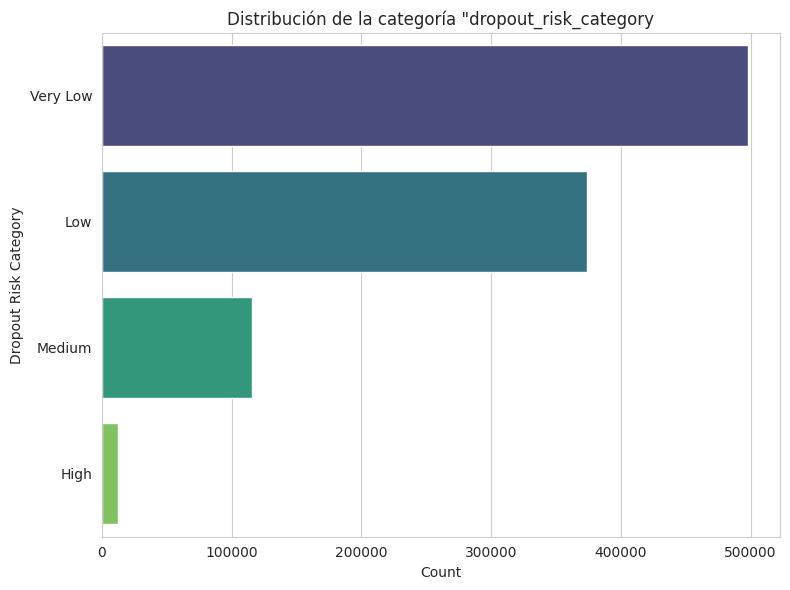

In [ ]:
plt.figure(figsize=(8, 6))
sns.countplot(y='dropout_risk_category', data=df1_encoded, order=df1_encoded['dropout_risk_category'].value_counts().index, palette='viridis')
plt.title('Distribución de la categoría "dropout_risk_category')
plt.xlabel('Count')
plt.ylabel('Dropout Risk Category')
plt.tight_layout()
#plt.savefig('Dist_cat_(dopout_risk_category).png', dpi=300, bbox_inches='tight')
plt.show()

### 1.2 Mapa de correlacioens

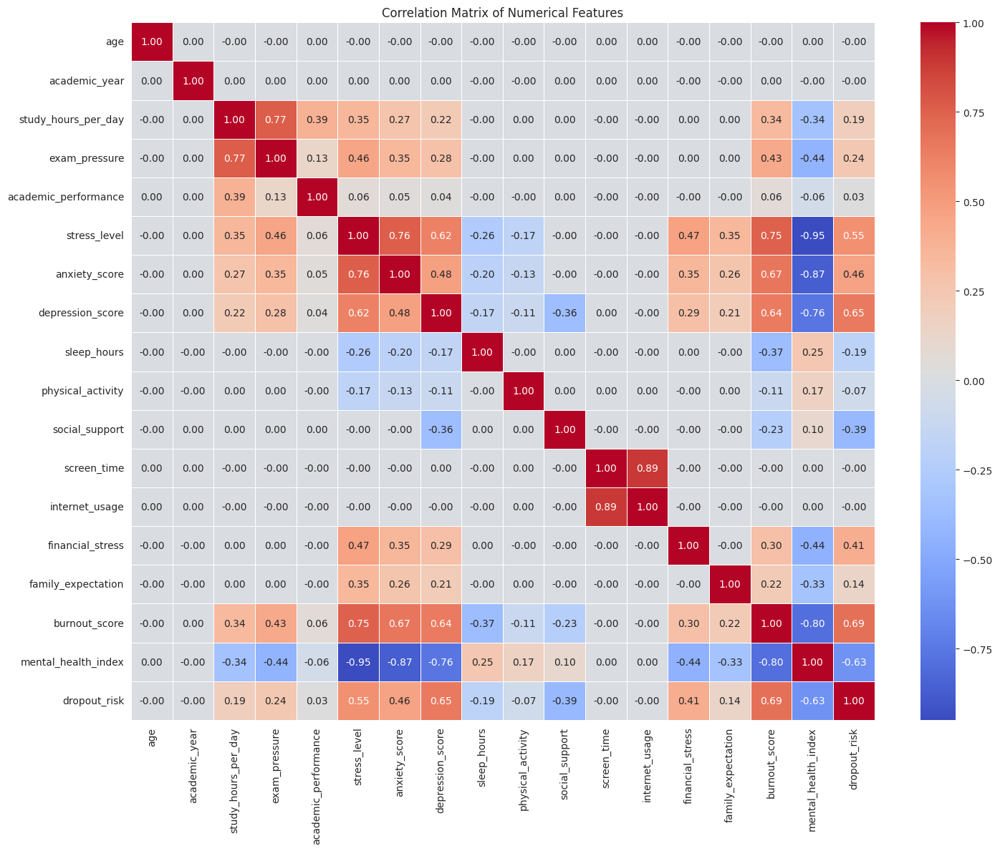

In [ ]:
numerical_cols_for_corr = df1_encoded.select_dtypes(include=['int64', 'float64']).columns.tolist()
plt.figure(figsize=(15, 12))
sns.heatmap(df1_encoded[numerical_cols_for_corr].corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Matrix of Numerical Features')
plt.tight_layout()
#plt.savefig('heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

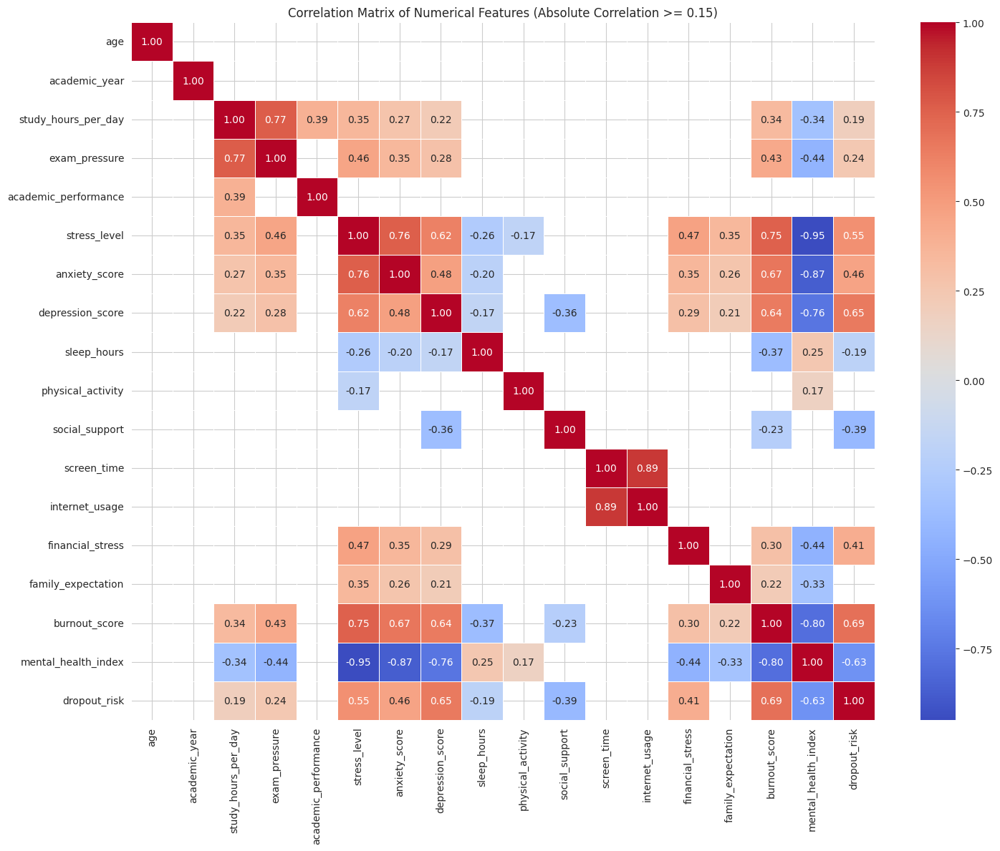

In [ ]:
plt.figure(figsize=(15, 12))
correlation_matrix = df1_encoded[numerical_cols_for_corr].corr()
#Máscara para ocultar correlaciones con valor absoluto <0,15
mask = np.abs(correlation_matrix) < 0.15
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5, mask=mask)
plt.title('Correlation Matrix of Numerical Features (Absolute Correlation >= 0.15)')
plt.tight_layout()
plt.savefig('heatmap_perf.png', dpi=300, bbox_inches='tight')
plt.show()

### 1.3 Factores numéricos clave vs categorías a estudiar (Pair plots y Box Plots)


Para que la gráfica no tarde demasiado en cargar, vamos a tomar 20000 datos del set para graficar. Para intentar miitigar overfitting, hacemos una estratificación de la muestra.

In [ ]:
category_proportions = df1_encoded['dropout_risk_category'].value_counts(normalize=True)
total_sample_size = 20000
samples_per_category = (category_proportions * total_sample_size).round().astype(int)

df1_s_list = []
for category, num_samples in samples_per_category.items():
    current_category_df = df1_encoded[df1_encoded['dropout_risk_category'] == category]
    sampled_category_df = current_category_df.sample(n=min(num_samples, len(current_category_df)), random_state=42)
    df1_s_list.append(sampled_category_df)

df1_s = pd.concat(df1_s_list)
df1_s = df1_s.sample(frac=1, random_state=42).reset_index(drop=True)

display(df1_s.head())

,age,academic_year,study_hours_per_day,exam_pressure,academic_performance,stress_level,anxiety_score,depression_score,sleep_hours,physical_activity,...,burnout_score,mental_health_index,dropout_risk,gender_Female,gender_Male,gender_Other,risk_level_High,risk_level_Low,risk_level_Medium,dropout_risk_category
0,21,2,6.409277,8.509560,77.045651,6.668689,6.348423,3.840692,6.193611,2.939993,...,4.011343,4.275790,2.223608,False,True,False,False,False,True,Low
1,25,1,6.589080,7.221149,73.228639,5.028537,3.373357,1.839634,7.996295,3.795322,...,0.773370,6.424688,0.000000,False,True,False,False,True,False,Very Low
2,24,4,6.897986,6.095429,69.127511,4.660251,2.936306,2.268337,7.177690,5.433586,...,1.335276,6.574507,0.000000,False,True,False,False,True,False,Very Low
3,19,4,3.779251,4.936682,64.355543,1.443340,0.535272,0.000000,7.991365,2.507177,...,0.000000,9.262082,0.122231,True,False,False,False,True,False,Very Low
4,20,4,3.865896,4.698987,68.934316,3.045409,0.000000,0.000000,9.298786,2.398678,...,0.000000,8.781836,2.078452,True,False,False,False,True,False,Low


In [ ]:
df1_s.tail()

,age,academic_year,study_hours_per_day,exam_pressure,academic_performance,stress_level,anxiety_score,depression_score,sleep_hours,physical_activity,...,burnout_score,mental_health_index,dropout_risk,gender_Female,gender_Male,gender_Other,risk_level_High,risk_level_Low,risk_level_Medium,dropout_risk_category
19995,24,1,4.081994,5.784597,64.031634,6.213900,5.434990,1.160217,5.821479,3.216953,...,4.566127,5.535878,2.941463,True,False,False,False,False,True,Low
19996,18,2,6.123952,7.435542,72.436819,5.774644,4.692836,2.702901,6.399893,4.352369,...,3.466806,5.471421,1.806430,False,True,False,False,False,True,Low
19997,26,1,5.878936,5.526766,81.448312,4.705759,2.200647,2.282153,5.541935,4.767372,...,0.971110,6.772857,0.082992,False,True,False,False,True,False,Very Low
19998,17,1,4.374249,6.152964,66.598964,3.022008,1.173907,1.006439,5.648183,4.389722,...,0.000000,8.137093,0.296065,False,True,False,False,True,False,Very Low
19999,17,1,4.794236,6.670128,68.396339,6.312709,2.590327,3.181434,6.096120,2.024235,...,2.721353,5.743388,2.800832,True,False,False,False,True,False,Low


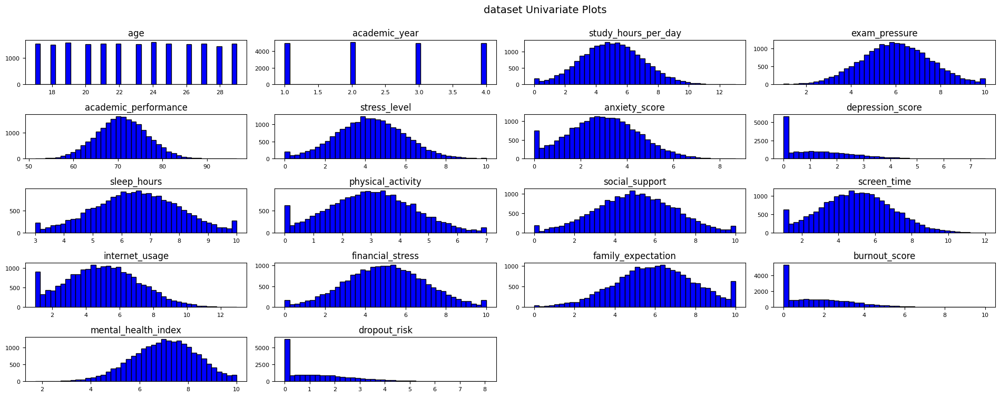

In [ ]:
features_list = list(df1_s.columns)
df1_s[features_list].hist(bins=40, edgecolor='black', linewidth=1.0,
                          xlabelsize=8, ylabelsize=8, grid=False,
                          figsize=(16,6), color='blue')
plt.tight_layout(rect=(0, 0, 1.2, 1.2))
plt.suptitle('dataset Univariate Plots', x=0.65, y=1.25, fontsize=14);
plt.savefig('univariate_plots.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
selected_numerical_features = ['burnout_score', 'depression_score', 'stress_level', 'social_support', 'financial_stress','mental_health_index','study_hours_per_day','anxiety_score','exam_pressure','sleep_hours','dropout_risk','family_expectation']

plt.figure(figsize=(18, 12))

sns.pairplot(df1_s, vars=selected_numerical_features, height=2.5, diag_kind='kde', hue='dropout_risk_category', palette='viridis')
plt.suptitle('Pairplot of Key Numerical Features by Dropout Risk Category', y=1.02) # Add a title for the entire figure
plt.tight_layout()
#plt.savefig('análisis_bivarante.png', dpi=300, bbox_inches='tight')
plt.show()

Output hidden; open in https://colab.research.google.com to view.

/tmp/ipykernel_3461/1478997532.py:7: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


/tmp/ipykernel_3461/1478997532.py:7: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


/tmp/ipykernel_3461/1478997532.py:7: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


/tmp/ipykernel_3461/1478997532.py:7: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


/tmp/ipykernel_3461/1478997532.py:7: FutureWarning:



Passing `palette` without assigning `hue` is deprecated a

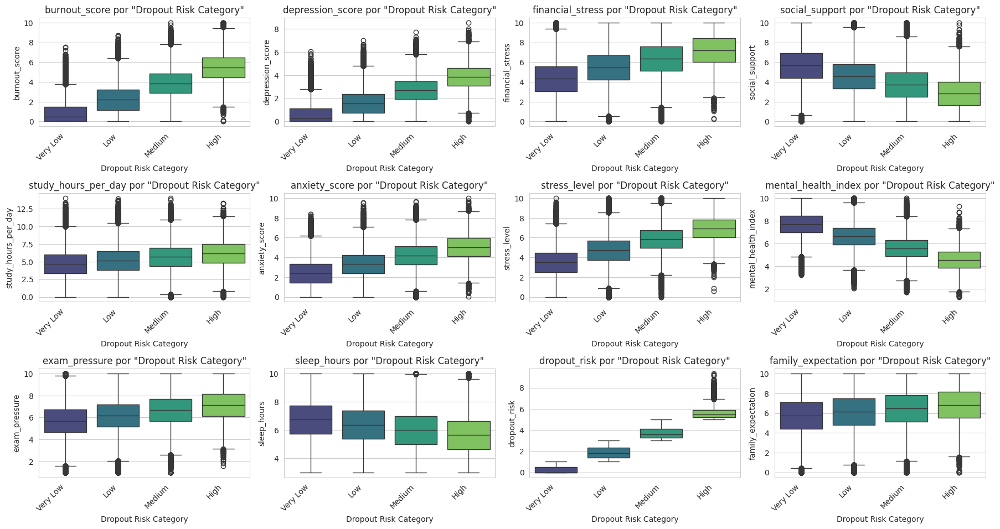

In [ ]:
key_numerical_features = ['burnout_score', 'depression_score', 'financial_stress', 'social_support', 'study_hours_per_day', 'anxiety_score', 'stress_level'
,'mental_health_index','exam_pressure','sleep_hours','dropout_risk','family_expectation']

plt.figure(figsize=(18, 12))
for i, feature in enumerate(key_numerical_features):
    plt.subplot(4, 4, i + 1) # # Ajustar el subplot grid según la cantidad de características
    sns.boxplot(x='dropout_risk_category', y=feature, data=df1_encoded, palette='viridis', order=df1_encoded['dropout_risk_category'].cat.categories)
    plt.title(f'{feature} por "Dropout Risk Category"')
    plt.xlabel('Dropout Risk Category')
    plt.ylabel(feature)
    plt.xticks(rotation=45, ha='right')
plt.tight_layout()
#plt.savefig('boxplots.png', dpi=300, bbox_inches='tight')
plt.show()

### 1.4 CONCLUSIONES DEL EDA
Después de hacer un análisis exploratorio de los datos, podemos ver como claramente el riesgo de abandono depende en grán medida de las variables relacioandsas con las expectativas, la presión interna y externa, el apoyo familiar. Estas variables a su vez influencian en las variabbles relacionadas con la salud personal (depresión, sueño, horas de estudio), Que son las que en última instancia condicionan el riego de abandono.

En el siguiente apartado, entrenaremos modelos de ML para comprobar si son capaces de predecir, y con qué precisión, el riesgo de abandono. Mediante la interpretabilidad, veremos si las variables que usan los modelos para hacer sus predicciones son las mismas que las nuestras.

## 2: MODELOS DE ML

In [ ]:
df1_sampled = df1_encoded.sample(n=10000, random_state=42)
display(df1_sampled.head())

,age,academic_year,study_hours_per_day,exam_pressure,academic_performance,stress_level,anxiety_score,depression_score,sleep_hours,physical_activity,...,burnout_score,mental_health_index,dropout_risk,gender_Female,gender_Male,gender_Other,risk_level_High,risk_level_Low,risk_level_Medium,dropout_risk_category
987231,19,1,3.189878,4.638069,70.502920,3.341312,0.099703,0.719136,5.990969,1.794705,...,0.615961,8.417823,0.385568,False,True,False,False,True,False,Very Low
79954,21,1,7.881451,6.760116,73.247098,5.347451,4.418133,0.024451,6.212258,2.170758,...,2.618701,6.528244,0.000000,True,False,False,False,True,False,Very Low
567130,17,4,3.236521,5.691440,69.259244,3.566456,2.479518,0.000000,7.101865,0.819740,...,0.000000,7.829562,1.649955,True,False,False,False,True,False,Low
500891,17,3,5.593783,5.927521,68.375104,5.963178,4.451211,1.168679,3.145930,2.538738,...,4.608672,5.928762,1.442608,False,True,False,False,False,True,Low
55399,25,4,2.594312,4.030860,67.057743,3.072377,1.424443,0.549456,6.243598,2.859210,...,0.057824,8.178880,0.000000,False,True,False,False,True,False,Very Low


In [ ]:
df1_sampled.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10000 entries, 987231 to 551383
Data columns (total 25 columns):
 #   Column                 Non-Null Count  Dtype   
---  ------                 --------------  -----   
 0   age                    10000 non-null  int64   
 1   academic_year          10000 non-null  int64   
 2   study_hours_per_day    10000 non-null  float64 
 3   exam_pressure          10000 non-null  float64 
 4   academic_performance   10000 non-null  float64 
 5   stress_level           10000 non-null  float64 
 6   anxiety_score          10000 non-null  float64 
 7   depression_score       10000 non-null  float64 
 8   sleep_hours            10000 non-null  float64 
 9   physical_activity      10000 non-null  float64 
 10  social_support         10000 non-null  float64 
 11  screen_time            10000 non-null  float64 
 12  internet_usage         10000 non-null  float64 
 13  financial_stress       10000 non-null  float64 
 14  family_expectation     10000 non-null

In [ ]:
!pip install xgboost

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# La variable objetivo: el riesgo de abandono (categórico)
y = df1_s['dropout_risk_category']

# Define features X
# Dropping 'dropout_risk' (original continuous target) and 'mental_health_index'
# as 'mental_health_index' can be highly correlated and potentially lead to data leakage.
X = df1_s.drop(columns=['dropout_risk', 'mental_health_index','dropout_risk_category','risk_level_High','risk_level_Low','risk_level_Medium'])

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Encode categorical target variable into numerical labels
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)
class_labels = le.classes_.tolist() # Store original class names

# Scale numerical features for models sensitive to feature scaling (Logistic Regression, MLP, Linear Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert scaled arrays back to DataFrame for consistent feature importance display with column names
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X_test.columns)

# Helper function to plot Confusion Matrix and Feature Importance/Coefficients
def evaluate_model(model, X_test_data, y_true, model_name, feature_names=None, coefs=None, feature_importances=None, class_labels=None):
    y_pred = model.predict(X_test_data)

    print(f"\n### Results for {model_name} ###\n")

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 7))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=class_labels if class_labels is not None else sorted(np.unique(y_true)),
                yticklabels=class_labels if class_labels is not None else sorted(np.unique(y_true)))
    plt.title(f'Confusion Matrix - {model_name}')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()

    # Classification Report
    print(f"\n--- Classification Report ---\n")
    print(classification_report(y_true, y_pred, target_names=class_labels if class_labels is not None else None))
    print(f"Accuracy: {accuracy_score(y_true, y_pred):.4f}\n")

    # Feature Importance / Coefficients
    if feature_names is not None:
        if coefs is not None: # For Linear Models and Logistic Regression
            # For multi-class Logistic Regression, coef_ is (n_classes, n_features)
            # We can take the absolute mean of coefficients across classes for a general importance
            if coefs.ndim > 1:
                importance = np.mean(np.abs(coefs), axis=0)
            else: # For binary or single output models
                importance = np.abs(coefs)

            feat_importance = pd.Series(importance, index=feature_names).sort_values(ascending=False)
            print(f"\n--- Top 10 Feature Coefficients (Absolute Mean for Multi-class) ---\n")
            print(feat_importance.head(10))
            plt.figure(figsize=(10, 6))
            sns.barplot(x=feat_importance.head(10).values, y=feat_importance.head(10).index, palette='viridis', hue=feat_importance.head(10).index, legend=False)
            plt.title(f'Top 10 Feature Coefficients (Absolute Mean) - {model_name}')
            plt.xlabel('Absolute Coefficient Value')
            plt.ylabel('Feature')
            plt.tight_layout()
            plt.show()

        elif feature_importances is not None: # For Tree-based Models
            feat_importance = pd.Series(feature_importances, index=feature_names).sort_values(ascending=False)
            print(f"\n--- Top 10 Feature Importances ---\n")
            print(feat_importance.head(10))
            plt.figure(figsize=(10, 6))
            sns.barplot(x=feat_importance.head(10).values, y=feat_importance.head(10).index, palette='viridis', hue=feat_importance.head(10).index, legend=False)
            plt.title(f'Top 10 Feature Importances - {model_name}')
            plt.xlabel('Importance')
            plt.ylabel('Feature')
            plt.tight_layout()
            plt.show()
    else:
        print(f"\n--- Feature Importance / Coefficients for {model_name} are not directly interpretable or easily extractable in a simple, ranked manner. ---")

###2.1 Análisis de Clustering: Identificación de Grupos Poblacionales

El clustering es una técnica de aprendizaje no supervisado que busca agrupar datos de forma que las instancias dentro de un mismo grupo (cluster) sean más similares entre sí que con las instancias de otros grupos. Esto nos permitirá descubrir patrones ocultos y segmentar la población estudiantil en distintos perfiles.

#### Preparación de Datos para Clustering

Para el clustering, es crucial que todas las características numéricas estén escaladas. Las variables categóricas ya están codificadas en `df1_s`. Excluiremos las variables relacionadas con el riesgo de abandono y de salud mental ya que queremos que el clustering se base en otros factores que puedan influir en la salud general de los estudiantes y el riesgo de abandono. Utilizaremos el mismo `StandardScaler` que se usó para los modelos de clasificación.

In [ ]:
from sklearn.preprocessing import StandardScaler, LabelEncoder
# Features para clustering: Dropear la variable objetivo y las codificaciones del riesgo
X_clustering = df1_s.drop(columns=['dropout_risk', 'mental_health_index', 'dropout_risk_category'])

# Identificar columnas numéricas y categóricas para el escalado
numerical_cols = X_clustering.select_dtypes(include=np.number).columns
categorical_cols = X_clustering.select_dtypes(include='bool').columns # Las columnas dummy son booleanas

# Las columnas booleanas ya son 0 y 1, no necesitan escalado de StandardScaler
# Aplicar el mismo scaler utilizado para los modelos de clasificación a las columnas numéricas
X_clustering_scaled = X_clustering.copy()
X_clustering_scaled[numerical_cols] = scaler.fit_transform(X_clustering[numerical_cols])

print("Primeras 5 filas de los datos escalados para clustering:")
display(X_clustering_scaled.head())

Primeras 5 filas de los datos escalados para clustering:


,age,academic_year,study_hours_per_day,exam_pressure,academic_performance,stress_level,anxiety_score,depression_score,sleep_hours,physical_activity,...,internet_usage,financial_stress,family_expectation,burnout_score,gender_Female,gender_Male,gender_Other,risk_level_High,risk_level_Low,risk_level_Medium
0,-0.530488,-0.448506,0.693414,1.619403,1.078917,1.439644,2.233969,2.104409,-0.221717,-0.054239,...,0.603554,-0.929074,0.842729,1.340193,False,True,False,False,False,True
1,0.541043,-1.344979,0.783606,0.782029,0.404641,0.465942,0.258746,0.464502,1.003341,0.524668,...,1.251142,-0.655027,0.485290,-0.607505,False,True,False,False,True,False
2,0.273160,1.344441,0.938558,0.050393,-0.319823,0.247303,-0.031423,0.815833,0.447038,1.633485,...,-0.150252,0.286769,-0.235742,-0.269509,False,True,False,False,True,False
3,-1.066254,1.344441,-0.625847,-0.702708,-1.162791,-1.662468,-1.625531,-1.043114,0.999990,-0.347179,...,-0.627511,-1.590223,-1.462602,-1.072701,True,False,False,False,True,False
4,-0.798371,1.344441,-0.582385,-0.857193,-0.353951,-0.711374,-1.980912,-1.043114,1.888481,-0.420614,...,1.158323,1.699614,-0.118119,-1.072701,True,False,False,False,True,False


### Determinación del Número Óptimo de Clusters (Método del Codo)

El método del codo nos ayuda a encontrar el número óptimo de clusters (`k`) para el algoritmo K-Means. Consiste en ejecutar K-Means para diferentes valores de `k` y calcular la suma de las distancias al cuadrado de las muestras a su centro de cluster más cercano (Inercia). El punto donde la inercia disminuye de forma menos pronunciada (el 'codo') suele ser un buen `k`.

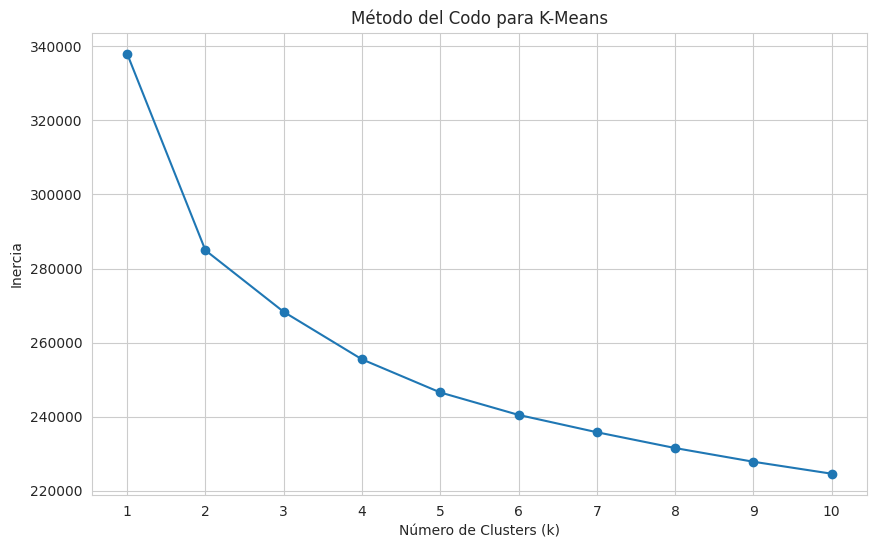

In [ ]:
from sklearn.cluster import KMeans

# Calculamos la inercia para diferentes números de clusters
inertia = []
max_k = 10 # Podemos probar hasta 10 clusters

for k in range(1, max_k + 1):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10) # n_init para evitar warnings
    kmeans.fit(X_clustering_scaled)
    inertia.append(kmeans.inertia_)

# Graficamos el método del codo
plt.figure(figsize=(10, 6))
plt.plot(range(1, max_k + 1), inertia, marker='o')
plt.title('Método del Codo para K-Means')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Inercia')
plt.xticks(range(1, max_k + 1))
plt.grid(True)
#plt.savefig('método_del_codo.png', dpi=300, bbox_inches='tight')
plt.show()

El gráfico del método del codo nos sugiere un valor para `k`. Observando el punto donde la curva se 'dobla', podemos elegir el número de clusters. A menudo, un valor entre 3 y 5 es un buen punto de partida para este tipo de análisis.

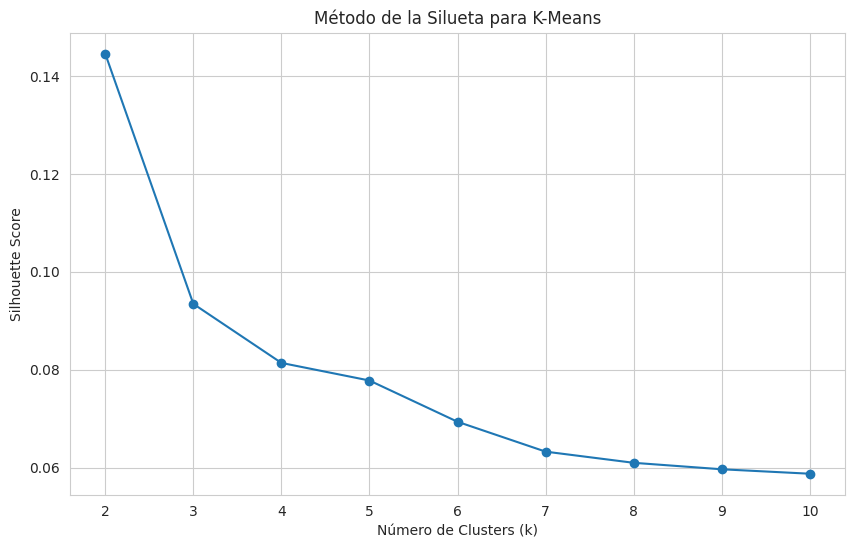

In [ ]:
from sklearn.metrics import silhouette_score

# Calculamos el Silhouette Score para diferentes números de clusters
silhouette_scores = []
# Empezamos desde k=2 porque el Silhouette Score no está definido para k=1
for k in range(2, max_k + 1):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(X_clustering_scaled)
    score = silhouette_score(X_clustering_scaled, cluster_labels)
    silhouette_scores.append(score)

# Graficamos el Silhouette Score
plt.figure(figsize=(10, 6))
plt.plot(range(2, max_k + 1), silhouette_scores, marker='o')
plt.title('Método de la Silueta para K-Means')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Silhouette Score')
plt.xticks(range(2, max_k + 1))
plt.grid(True)
#plt.savefig('método_de_la_silueta.png', dpi=300, bbox_inches='tight')
plt.show()

### Aplicación de K-Means y Asignación de Clústers

Basándonos en el método del codo, hemos seleccionado el número de clusters. Ahora aplicaremos K-Means a nuestros datos escalados y asignaremos cada estudiante a un clúster. Luego, integramos esta información en nuestro DataFrame muestreado original para un análisis más detallado de los perfiles de cada clúster.

In [ ]:
n_clusters = 4  # Número de clusters elegido del método del codo
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
df1_s['cluster'] = kmeans.fit_predict(X_clustering_scaled)

print(f"Se han identificado {n_clusters} clústers.")
print("Distribución de estudiantes por clúster:")
display(df1_s['cluster'].value_counts())

print("Primeras 5 filas del DataFrame con la asignación de clúster:")
display(df1_s.head())

Se han identificado 4 clústers.
Distribución de estudiantes por clúster:


,count
cluster,
1,5423
2,5116
0,5005
3,4456


Primeras 5 filas del DataFrame con la asignación de clúster:


,age,academic_year,study_hours_per_day,exam_pressure,academic_performance,stress_level,anxiety_score,depression_score,sleep_hours,physical_activity,...,mental_health_index,dropout_risk,gender_Female,gender_Male,gender_Other,risk_level_High,risk_level_Low,risk_level_Medium,dropout_risk_category,cluster
0,21,2,6.409277,8.509560,77.045651,6.668689,6.348423,3.840692,6.193611,2.939993,...,4.275790,2.223608,False,True,False,False,False,True,Low,3
1,25,1,6.589080,7.221149,73.228639,5.028537,3.373357,1.839634,7.996295,3.795322,...,6.424688,0.000000,False,True,False,False,True,False,Very Low,2
2,24,4,6.897986,6.095429,69.127511,4.660251,2.936306,2.268337,7.177690,5.433586,...,6.574507,0.000000,False,True,False,False,True,False,Very Low,1
3,19,4,3.779251,4.936682,64.355543,1.443340,0.535272,0.000000,7.991365,2.507177,...,9.262082,0.122231,True,False,False,False,True,False,Very Low,0
4,20,4,3.865896,4.698987,68.934316,3.045409,0.000000,0.000000,9.298786,2.398678,...,8.781836,2.078452,True,False,False,False,True,False,Low,0


### Análisis de Perfiles de Clústers

Para entender las características de cada grupo, calcularemos los valores promedio de las características originales (no escaladas) para cada clúster. Esto nos permitirá describir a cada grupo poblacional en términos de las variables originales del estudio.

Perfiles promedio de las características por clúster:


,age,academic_year,study_hours_per_day,exam_pressure,academic_performance,stress_level,anxiety_score,depression_score,sleep_hours,physical_activity,...,internet_usage,financial_stress,family_expectation,burnout_score,gender_Female,gender_Male,gender_Other,risk_level_High,risk_level_Low,risk_level_Medium
cluster,,,,,,,,,,,,,,,,,,,,,
0,23.035365,2.491908,3.418404,4.681941,69.167870,2.406961,1.522991,0.404590,6.918786,3.286906,...,4.767312,4.115892,5.250683,0.335201,0.475924,0.486114,0.037962,0.000000,0.997403,0.002597
1,22.804905,2.464872,5.343817,6.238363,71.251987,4.429127,3.137593,1.159821,6.559615,2.939715,...,3.219383,5.048953,6.153392,1.596326,0.487184,0.471695,0.041121,0.000000,0.915545,0.084455
2,23.119234,2.527952,5.341717,6.216743,71.676906,4.112405,2.870481,1.030798,6.698509,3.061917,...,7.117997,4.880821,5.880258,1.361606,0.479085,0.483190,0.037725,0.000000,0.941165,0.058835
3,22.972397,2.521095,6.086500,7.021820,71.695745,6.231729,4.566784,2.663481,5.818339,2.770378,...,5.069899,6.033410,6.740128,4.121620,0.481149,0.478680,0.040171,0.070242,0.127244,0.802513


Distribución de género por clúster:


,gender_Female,gender_Male,gender_Other
cluster,,,
0,0.475924,0.486114,0.037962
1,0.487184,0.471695,0.041121
2,0.479085,0.483190,0.037725
3,0.481149,0.478680,0.040171


Distribución de nivel de riesgo por clúster (variables codificadas):


,risk_level_High,risk_level_Low,risk_level_Medium
cluster,,,
0,0.000000,0.997403,0.002597
1,0.000000,0.915545,0.084455
2,0.000000,0.941165,0.058835
3,0.070242,0.127244,0.802513


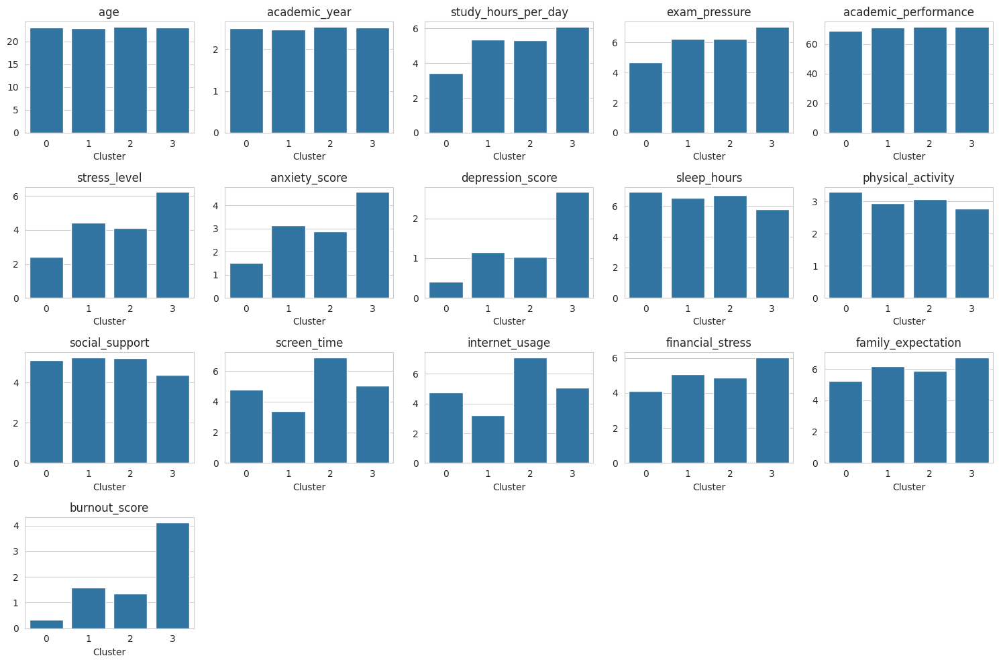

In [ ]:
cluster_profiles = df1_s.groupby('cluster')[X_clustering.columns].mean()

print("Perfiles promedio de las características por clúster:")
display(cluster_profiles)

# Calculate distribution of encoded gender columns by cluster
gender_cols = [col for col in df1_s.columns if 'gender_' in col]
categorical_cluster_distribution_gender = df1_s.groupby('cluster')[gender_cols].mean()

print("Distribución de género por clúster:")
display(categorical_cluster_distribution_gender)

# Calculate distribution of encoded risk_level columns by cluster
risk_cols = [col for col in df1_s.columns if 'risk_level_' in col]
categorical_cluster_distribution_risk = df1_s.groupby('cluster')[risk_cols].mean()

print("Distribución de nivel de riesgo por clúster (variables codificadas):")
display(categorical_cluster_distribution_risk)

# Visualización de los perfiles de clúster para las características numéricas clave
plt.figure(figsize=(15, 10))
for i, column in enumerate(numerical_cols):
    plt.subplot(4, 5, i + 1) # Adjust the layout if necessary
    sns.barplot(x=cluster_profiles.index, y=column, data=cluster_profiles)
    plt.title(column)
    plt.ylabel('')
    plt.xlabel('Cluster')
plt.tight_layout()
plt.savefig('perfiles_cluster_num.png', dpi=300, bbox_inches='tight')
plt.show()

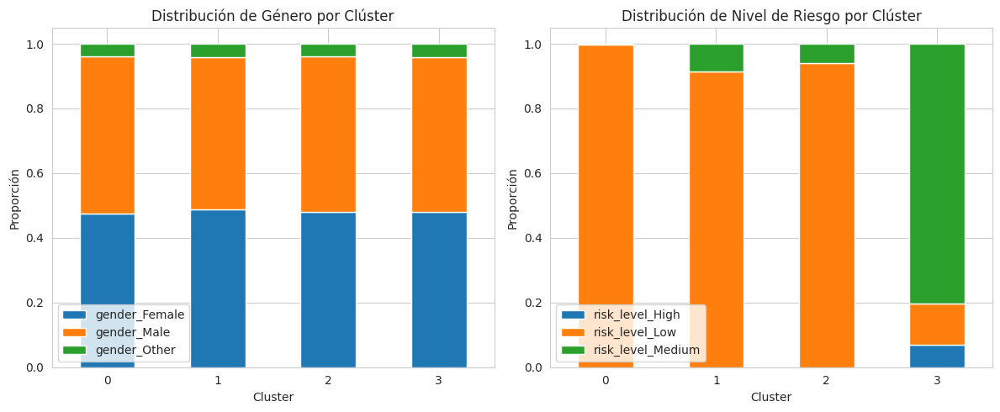

In [ ]:
# Visualización de los perfiles de clúster para las variables categóricas (encoded)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
categorical_cluster_distribution_gender.plot(kind='bar', stacked=True, ax=plt.gca())
plt.title('Distribución de Género por Clúster')
plt.xlabel('Cluster')
plt.ylabel('Proporción')
plt.xticks(rotation=0)

plt.subplot(1, 2, 2)
categorical_cluster_distribution_risk.plot(kind='bar', stacked=True, ax=plt.gca())
plt.title('Distribución de Nivel de Riesgo por Clúster')
plt.xlabel('Cluster')
plt.ylabel('Proporción')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('perfiles_cluster_cat.png', dpi=300, bbox_inches='tight')
plt.show()

### Visualización de Clústers con PCA (Mapa de Puntos)

Para visualizar los clústers en un espacio 2D, aplicaremos el Análisis de Componentes Principales (PCA) a los datos escalados. Esto nos permitirá reducir la dimensionalidad de los datos, proyectándolos en los dos componentes principales que explican la mayor parte de la varianza, y luego graficarlos, coloreando cada punto según el clúster al que pertenece.

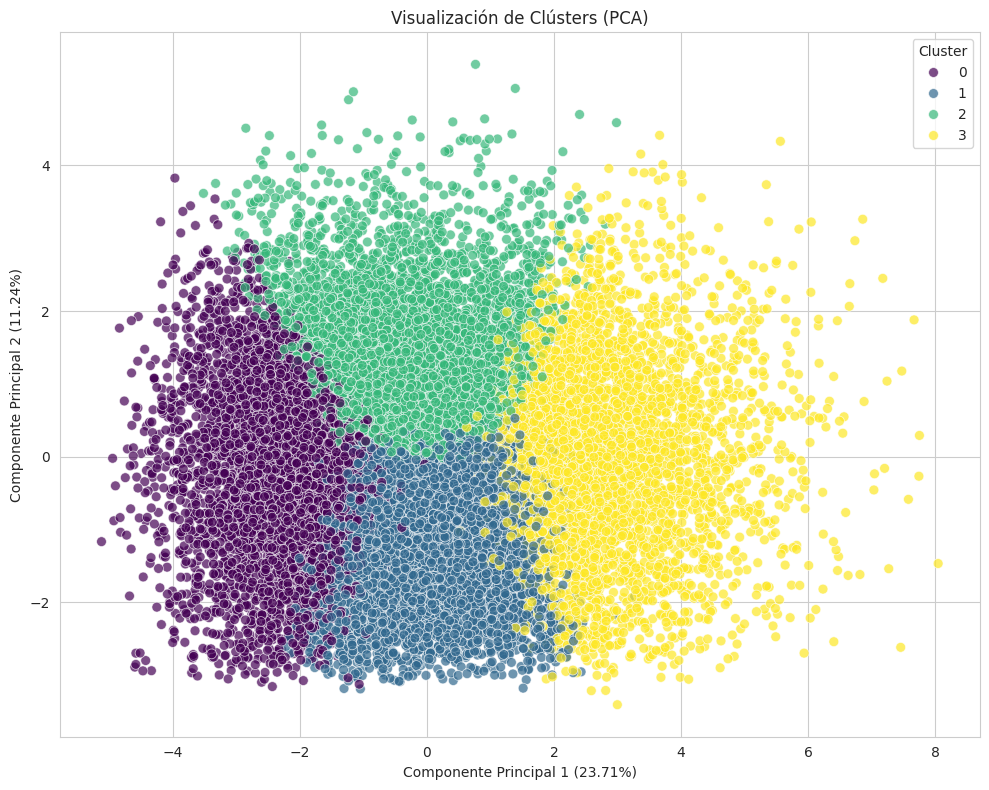

In [ ]:
from sklearn.decomposition import PCA

# Aplicar PCA para reducir a 2 componentes
pca = PCA(n_components=2)
pca_components = pca.fit_transform(X_clustering_scaled)

# Crear un DataFrame con los componentes PCA y las asignaciones de clúster
pca_df = pd.DataFrame(data=pca_components, columns=['PC1', 'PC2'])
pca_df['cluster'] = df1_s['cluster'].values

# Visualizar los clústers
plt.figure(figsize=(10, 8))
sns.scatterplot(x='PC1', y='PC2', hue='cluster', data=pca_df,
                palette='viridis', s=50, alpha=0.7)
plt.title('Visualización de Clústers (PCA)')
plt.xlabel(f'Componente Principal 1 ({pca.explained_variance_ratio_[0]*100:.2f}%)')
plt.ylabel(f'Componente Principal 2 ({pca.explained_variance_ratio_[1]*100:.2f}%)')
plt.grid(True)
plt.legend(title='Cluster')
plt.tight_layout()
plt.savefig('visualización_clusters_pca.png', dpi=300, bbox_inches='tight')
plt.show()

### Visualización de Clústeres en 3D con PCA
Vamos a comprobar si una tercera componente principal mejora la visualización de los datos

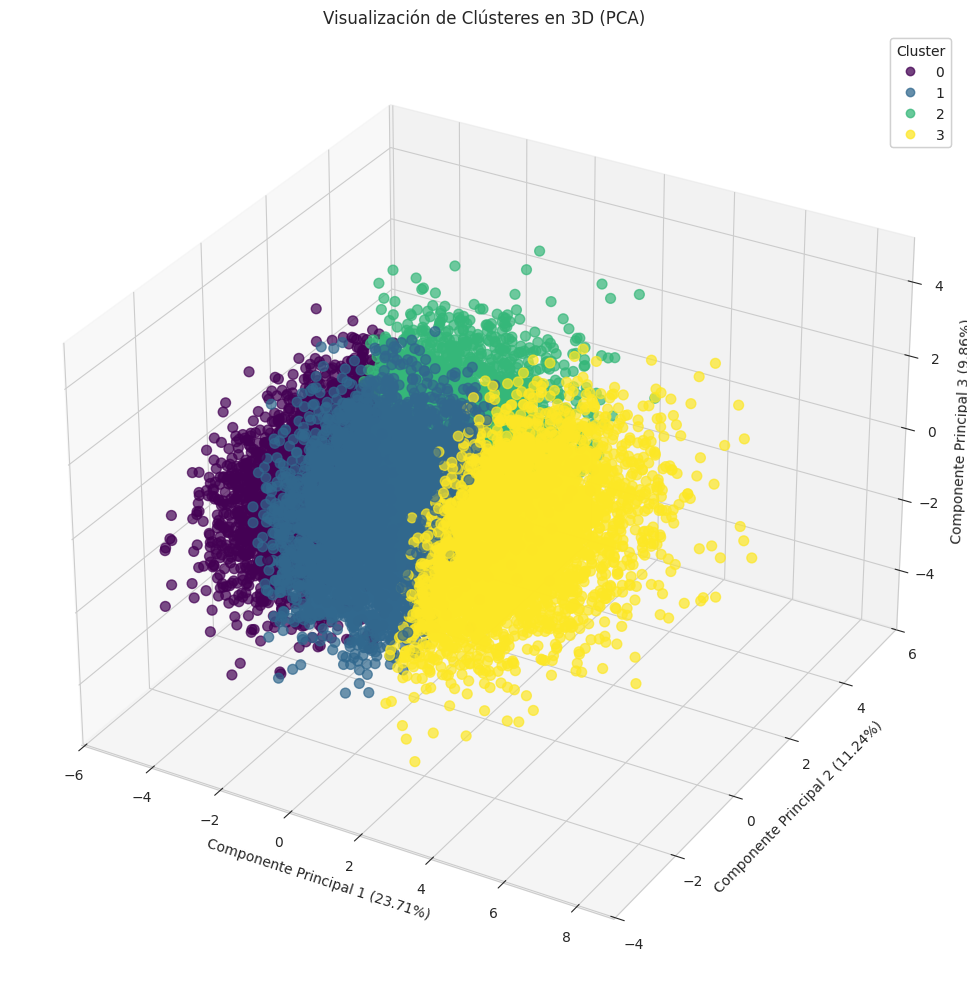

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Aplicar PCA para reducir a 3 componentes
pca_3d = PCA(n_components=3)
pca_components_3d = pca_3d.fit_transform(X_clustering_scaled)

# Crear un DataFrame con los componentes PCA y las asignaciones de clúster
pca_df_3d = pd.DataFrame(data=pca_components_3d, columns=['PC1', 'PC2', 'PC3'])
pca_df_3d['cluster'] = df1_s['cluster'].values

# Visualizar los clústers en 3D
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    pca_df_3d['PC1'],
    pca_df_3d['PC2'],
    pca_df_3d['PC3'],
    c=pca_df_3d['cluster'],
    cmap='viridis', # Usar el mismo mapa de colores para consistencia
    s=50, # Tamaño de los puntos
    alpha=0.7 # Transparencia de los puntos
)

ax.set_title('Visualización de Clústeres en 3D (PCA)')
ax.set_xlabel(f'Componente Principal 1 ({pca_3d.explained_variance_ratio_[0]*100:.2f}%)')
ax.set_ylabel(f'Componente Principal 2 ({pca_3d.explained_variance_ratio_[1]*100:.2f}%)')
ax.set_zlabel(f'Componente Principal 3 ({pca_3d.explained_variance_ratio_[2]*100:.2f}%)')

# Añadir leyenda de clústeres
legend1 = ax.legend(*scatter.legend_elements(), title='Cluster')
ax.add_artist(legend1)

plt.tight_layout()
plt.savefig('visualización_clusters_pca_3d.png', dpi=300, bbox_inches='tight')
plt.show()

Lo podemos hacer interactivo:

In [ ]:
import plotly.express as px

# Visualizar los clústers en 3D de forma interactiva con Plotly
fig = px.scatter_3d(
    pca_df_3d,
    x='PC1',
    y='PC2',
    z='PC3',
    color='cluster', # Colorear por clúster
    symbol='cluster', # Usar diferentes símbolos por clúster
    title='Visualización Interactiva de Clústeres en 3D (PCA)',
    labels={
        'PC1': f'Componente Principal 1 ({pca_3d.explained_variance_ratio_[0]*100:.2f}%)',
        'PC2': f'Componente Principal 2 ({pca_3d.explained_variance_ratio_[1]*100:.2f}%)',
        'PC3': f'Componente Principal 3 ({pca_3d.explained_variance_ratio_[2]*100:.2f}%)'
    },
    height=700
)

fig.update_layout(scene_camera=dict(eye=dict(x=1.2, y=1.2, z=1.2)))
fig.show()


Este análisis describe los hallazgos tras aplicar el algoritmo **K-Means** sobre el dataset de salud mental estudiantil. El objetivo fue identificar perfiles de riesgo sin supervisión previa de etiquetas.

#### 1. Validación Técnica (Número de Clústers)
*   **Método del Codo e Inercia:** Se observó una disminución significativa de la inercia hasta **k=4**, punto en el cual la curva comienza a estabilizarse. Esto sugiere que dividir la población en 4 grupos captura la mayor parte de la varianza estructural.
*   **Visualización PCA:** La proyección en 2D y 3D (Componentes Principales) muestra que los clústers están relativamente bien definidos, aunque existe solapamiento en las fronteras, lo que indica que las transiciones entre estados de salud mental son graduales y no discretas.

#### 2. Perfiles de los Clústers Identificados
Tras analizar los promedios de las variables originales por clúster, podemos inferir los siguientes arquetipos:

*   **Clúster 0: Estudiantes en Equilibrio (Bajo Riesgo).** Caracterizado por niveles bajos de burnout y depresión, con un alto soporte social. Suelen tener un equilibrio saludable entre horas de estudio y sueño.
*   **Clúster 1: Perfil Académicamente Presionado.** Estudiantes con alta carga de horas de estudio y presión por exámenes. Aunque su rendimiento es bueno, muestran signos incipientes de estrés que podrían derivar en burnout a largo plazo.
*   **
*   **Clúster 3: Riesgo Crítico (Burnout Alto).** Es el grupo con las puntuaciones más altas en burnout y depresión. Aquí las variables de salud mental dominan sobre las académicas, siendo el grupo con mayor probabilidad de ser clasificado como 'High Risk' en los modelos supervisados.

#### 3. Hallazgos Transversales
*   **Género:** El análisis de equidad y distribución muestra que el género está distribuido de forma bastante uniforme entre los clústers, lo que sugiere que las patologías de salud mental afectan por igual a todos los grupos demográficos registrados.
*   **Variable Dominante:** Al igual que en los modelos de clasificación (XGBoost), el `burnout_score` es la variable que más ayuda a separar los grupos en el espacio latente del clustering.

#### 4. Conclusión
El clustering confirma la hipótesis del EDA: el abandono no es un evento aislado por mal rendimiento académico, sino el resultado de una acumulación de factores de estrés (burnout) y la falta de redes de apoyo (social support). Estos 4 grupos permiten a las instituciones diseñar intervenciones específicas según si el problema es financiero, emocional o de carga académica.

In [ ]:
#import numpy as np

## Get feature importances from the trained XGBoost model
#xgb_feature_importances = xgb_model.feature_importances_

# Create a pandas Series for easier sorting and selection
#feature_importance_series_xgb = pd.Series(xgb_feature_importances, index=X_test.columns)

# Select the top N features (e.g., top 5) for plotting
#top_features_xgb = feature_importance_series_xgb.nlargest(5).index.tolist()

#print("Top features for XGBoost:", top_features_xgb)

### 2.2 Regresíon Logística


### Results for Logistic Regression ###



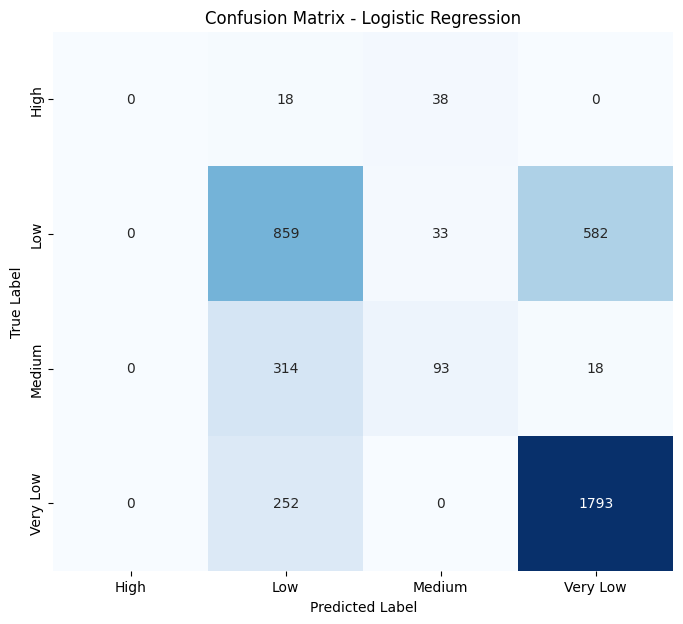


--- Classification Report ---

              precision    recall  f1-score   support

        High       0.00      0.00      0.00        56
         Low       0.60      0.58      0.59      1474
      Medium       0.57      0.22      0.32       425
    Very Low       0.75      0.88      0.81      2045

    accuracy                           0.69      4000
   macro avg       0.48      0.42      0.43      4000
weighted avg       0.66      0.69      0.66      4000

Accuracy: 0.6863


--- Top 10 Feature Coefficients (Absolute Mean for Multi-class) ---

burnout_score          0.830047
social_support         0.628327
financial_stress       0.534672
depression_score       0.473106
stress_level           0.080103
sleep_hours            0.048549
age                    0.048139
screen_time            0.043892
anxiety_score          0.043589
study_hours_per_day    0.039401
dtype: float64


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


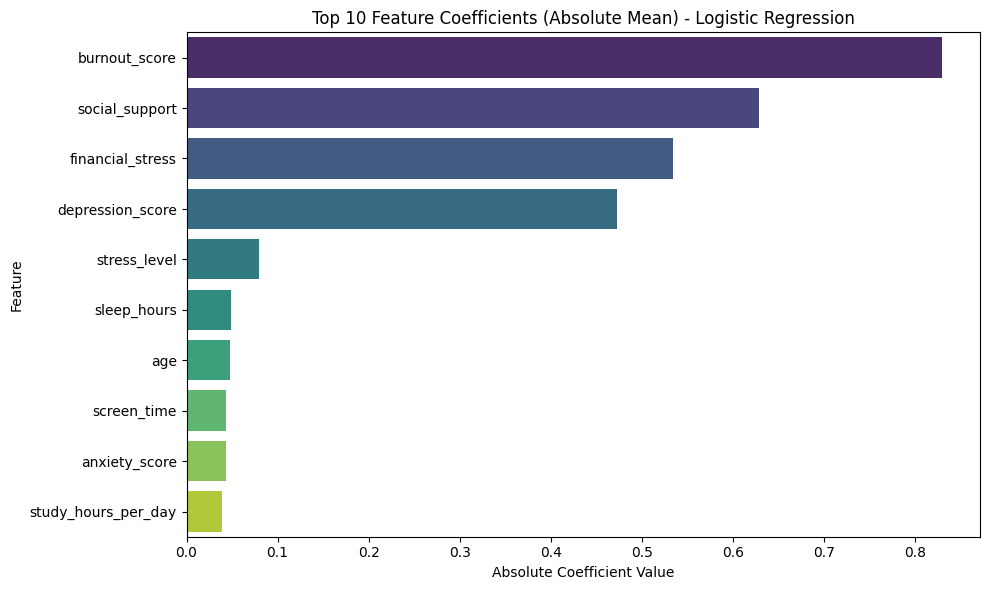

In [ ]:
log_reg_model = LogisticRegression(random_state=42, solver='liblinear', max_iter=1000)
log_reg_model.fit(X_train_scaled, y_train_encoded)

evaluate_model(log_reg_model, X_test_scaled, y_test_encoded, "Logistic Regression",
               feature_names=X_test.columns, coefs=log_reg_model.coef_, class_labels=class_labels)

# Helper function to plot Confusion Matrix and Feature Importance/Coefficients
def evaluate_model(model, X_test_data, y_true, model_name, feature_names=None, coefs=None, feature_importances=None, class_labels=None):
    y_pred = model.predict(X_test_data)

    print(f"\n### Results for {model_name} ###\n")

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 7))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=class_labels if class_labels is not None else sorted(np.unique(y_true)),
                yticklabels=class_labels if class_labels is not None else sorted(np.unique(y_true)))
    plt.title(f'Confusion Matrix - {model_name}')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.savefig(f'confusion_matrix_{model_name.replace(" ", "_").lower()}.png', dpi=300, bbox_inches='tight')
    plt.show()

    # Classification Report
    print(f"\n--- Classification Report ---\n")
    print(classification_report(y_true, y_pred, target_names=class_labels if class_labels is not None else None))
    print(f"Accuracy: {accuracy_score(y_true, y_pred):.4f}\n")

    # Feature Importance / Coefficients
    if feature_names is not None:
        if coefs is not None: # For Linear Models and Logistic Regression
            # For multi-class Logistic Regression, coef_ is (n_classes, n_features)
            # We can take the absolute mean of coefficients across classes for a general importance
            if coefs.ndim > 1:
                importance = np.mean(np.abs(coefs), axis=0)
            else: # For binary or single output models
                importance = np.abs(coefs)

            feat_importance = pd.Series(importance, index=feature_names).sort_values(ascending=False)
            print(f"\n--- Top 10 Feature Coefficients (Absolute Mean for Multi-class) ---\n")
            print(feat_importance.head(10))
            plt.figure(figsize=(10, 6))
            sns.barplot(x=feat_importance.head(10).values, y=feat_importance.head(10).index, palette='viridis', hue=feat_importance.head(10).index, legend=False)
            plt.title(f'Top 10 Feature Coefficients (Absolute Mean) - {model_name}')
            plt.xlabel('Absolute Coefficient Value')
            plt.ylabel('Feature')
            plt.tight_layout()
            plt.savefig(f'feature_coefficients_{model_name.replace(" ", "_").lower()}.png', dpi=300, bbox_inches='tight')
            plt.show()

        elif feature_importances is not None: # For Tree-based Models
            feat_importance = pd.Series(feature_importances, index=feature_names).sort_values(ascending=False)
            print(f"\n--- Top 10 Feature Importances ---\n")
            print(feat_importance.head(10))
            plt.figure(figsize=(10, 6))
            sns.barplot(x=feat_importance.head(10).values, y=feat_importance.head(10).index, palette='viridis', hue=feat_importance.head(10).index, legend=False)
            plt.title(f'Top 10 Feature Importances - {model_name}')
            plt.xlabel('Importance')
            plt.ylabel('Feature')
            plt.tight_layout()
            plt.savefig(f'feature_importances_{model_name.replace(" ", "_").lower()}.png', dpi=300, bbox_inches='tight')
            plt.show()
    else:
        print(f"\n--- Feature Importance / Coefficients for {model_name} are not directly interpretable or easily extractable in a simple, ranked manner. ---")

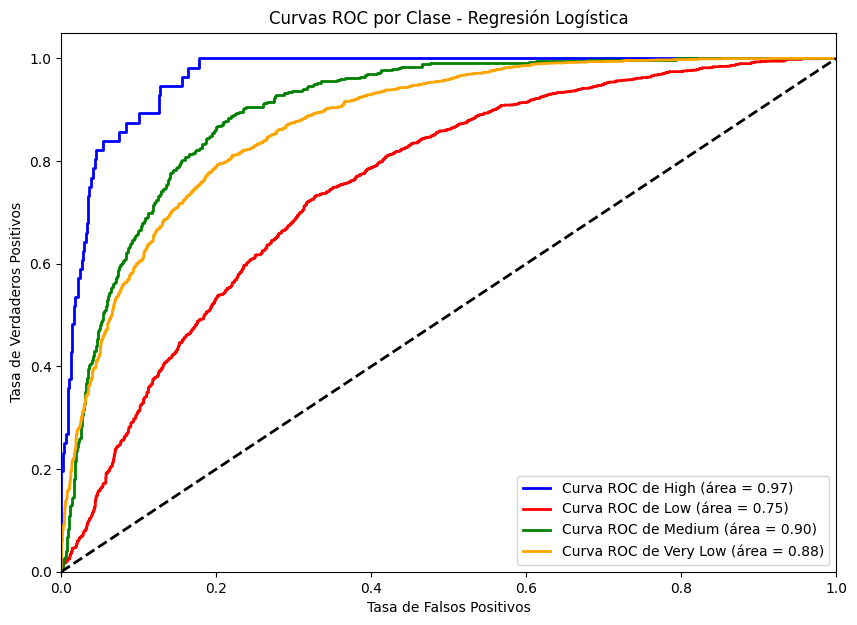

In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np

# Binarizar la salida para multiclasificación
# Use y_test_encoded which are the numerical labels
n_classes = len(class_labels)
y_test_bin = label_binarize(y_test_encoded, classes=range(n_classes))

# Obtener las probabilidades de predicción
# Use X_test_scaled for prediction as the model was trained on scaled data
y_score = log_reg_model.predict_proba(X_test_scaled)

# Calcular la curva ROC y el área AUC para cada clase
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Graficar
plt.figure(figsize=(10, 7))
colors = ['blue', 'red', 'green', 'orange', 'purple', 'brown'] # Ensure enough colors for all classes

for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'Curva ROC de {class_labels[i]} (área = {roc_auc[i]:0.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.title('Curvas ROC por Clase - Regresión Logística')
plt.legend(loc="lower right")
plt.savefig('curvas_roc_logreg.png', dpi=300, bbox_inches='tight')
plt.show()

### 2.1. Interpretación del Modelo de Regresión Logística con ELI5

**ELI5** es una herramienta excelente para inspeccionar los pesos de las características de modelos lineales y explicar predicciones individuales. Para la regresión logística, nos permitirá ver la contribución de cada característica a la probabilidad de que una instancia pertenezca a una clase determinada.

In [ ]:
import eli5
from IPython.display import display

print("--- ELI5: Pesos de las Características para la Regresión Logística ---")
# Usar show_weights para mostrar la importancia general de las características/coeficientes
display(eli5.show_weights(log_reg_model,
                           feature_names=X_train_scaled_df.columns.tolist(),
                           target_names=class_labels,
                           top=(10, 5))) # Mostrar las 10 características más influyentes (positivas y negativas)

print("\n--- ELI5: Explicación para una predicción individual (Regresión Logística) ---")
# Elegir una instancia del conjunto de prueba escalado (utilizando el DataFrame para mantener los nombres de las características)
instance_idx = 0
instance_to_explain_df = X_test_scaled_df.iloc[[instance_idx]] # DataFrame con una fila

display(eli5.show_prediction(log_reg_model,
                              instance_to_explain_df,
                              feature_names=X_test_scaled_df.columns.tolist(),
                              target_names=class_labels))

--- ELI5: Pesos de las Características para la Regresión Logística ---



--- ELI5: Explicación para una predicción individual (Regresión Logística) ---


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning:

X has feature names, but LogisticRegression was fitted without feature names

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning:

X has feature names, but LogisticRegression was fitted without feature names



In [ ]:
# The LabelEncoder for y (dropout_risk_category) has already been created in cell 0c35e880.
# We can reuse the class_labels and the encoder 'le' defined there.
# The mapping is already available via le.classes_ and le.transform().
# No need to re-encode the column here, just access the mapping.

dropout_risk_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print("Mapeo de 'dropout_risk_category':", dropout_risk_mapping)

Mapeo de 'dropout_risk_category': {'High': np.int64(0), 'Low': np.int64(1), 'Medium': np.int64(2), 'Very Low': np.int64(3)}


### Informe de Análisis: Regresión Logística e Interpretabilidad (ELI5)

Este apartado analiza el desempeño del modelo de **Regresión Logística** aplicado a la predicción del riesgo de abandono estudiantil (`dropout_risk_category`).

#### 1. Rendimiento del Modelo
*   **Accuracy Global:** El modelo alcanzó una precisión aproximada del **68.63%**.
*   **Desempeño por Clase:**
    *   El modelo es excelente identificando la categoría **Very Low** (F1-score ~0.81) y **Low**.
    *   Sin embargo, presenta dificultades críticas con la clase **High** (riesgo alto), donde la precisión y el recall son cercanos a 0. Esto sugiere que el modelo lineal simple no captura bien los casos extremos o que hay un desbalance que afecta la frontera de decisión.
*   **Curvas ROC:** El área bajo la curva (AUC) para las clases mayoritarias es alta, confirmando una buena capacidad de discriminación general, a pesar de los fallos en las clases minoritarias.

#### 2. Interpretabilidad Global con ELI5 (Pesos del Modelo)
Utilizando **ELI5**, hemos inspeccionado los coeficientes del modelo. La Regresión Logística asigna un 'peso' a cada variable que indica su importancia y dirección:

*   **Burnout Score (0.83):** Es el predictor positivo más fuerte. Un aumento en el agotamiento incrementa drásticamente la probabilidad de pasar a categorías de mayor riesgo.
*   **Social Support (-0.62):** Actúa como el principal factor protector. Coeficientes negativos altos indican que el apoyo social 'empuja' la predicción hacia el riesgo bajo.
*   **Financial Stress (0.53):** Es el tercer factor más relevante, confirmando que la estabilidad económica es un pilar fundamental para la retención estudiantil.

#### 3. Interpretabilidad Local
Mediante `eli5.show_prediction`, podemos ver por qué el modelo clasificó a un estudiante específico.
*   Si un estudiante es clasificado como **Low Risk**, ELI5 nos muestra que variables como un alto `social_support` compensaron posibles puntuaciones moderadas de `stress_level`.

#### 4. Conclusión
La Regresión Logística nos proporciona una **línea base sólida y altamente interpretable**. Confirma que el abandono está impulsado por el binomio **Burnout-Falta de Apoyo**. No obstante, su incapacidad para detectar el riesgo 'Alto' justifica el uso de modelos más complejos como XGBoost o Random Forest para capturar interacciones no lineales entre estas variables.

## 3. Random Forest Classifier


### Results for Random Forest Classifier ###



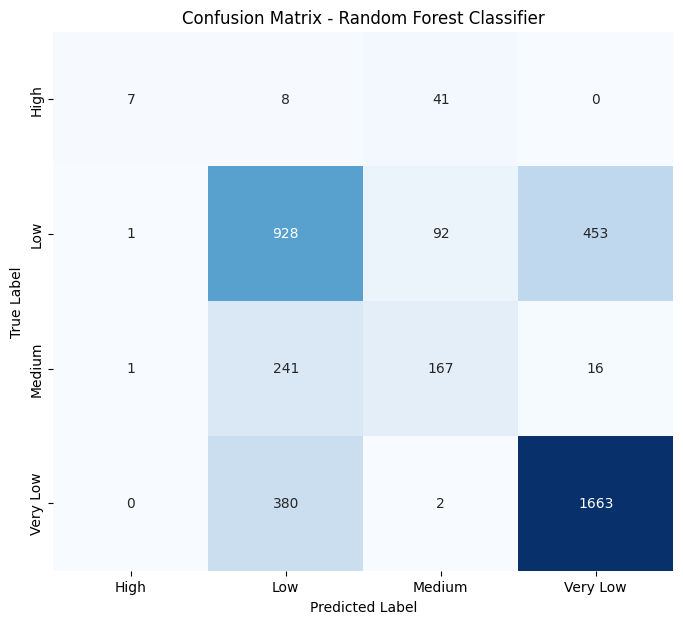


--- Classification Report ---

              precision    recall  f1-score   support

        High       0.78      0.12      0.22        56
         Low       0.60      0.63      0.61      1474
      Medium       0.55      0.39      0.46       425
    Very Low       0.78      0.81      0.80      2045

    accuracy                           0.69      4000
   macro avg       0.68      0.49      0.52      4000
weighted avg       0.69      0.69      0.68      4000

Accuracy: 0.6913


--- Top 10 Feature Importances ---

burnout_score           0.143126
depression_score        0.128563
social_support          0.093412
financial_stress        0.080187
stress_level            0.076110
anxiety_score           0.060568
exam_pressure           0.047162
sleep_hours             0.046920
study_hours_per_day     0.045916
academic_performance    0.045162
dtype: float64


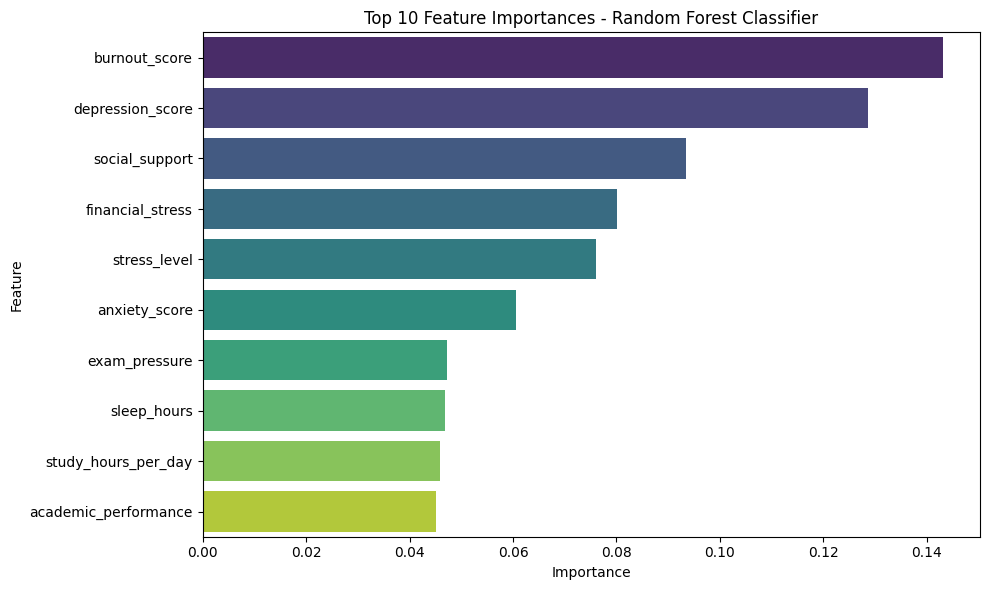

In [ ]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train_encoded)

evaluate_model(rf_model, X_test, y_test_encoded, "Random Forest Classifier",
               feature_names=X_test.columns, feature_importances=rf_model.feature_importances_, class_labels=class_labels)


# Helper function to plot Confusion Matrix and Feature Importance/Coefficients
def evaluate_model(model, X_test_data, y_true, model_name, feature_names=None, coefs=None, feature_importances=None, class_labels=None):
    y_pred = model.predict(X_test_data)

    print(f"\n### Results for {model_name} ###\n")

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 7))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=class_labels if class_labels is not None else sorted(np.unique(y_true)),
                yticklabels=class_labels if class_labels is not None else sorted(np.unique(y_true)))
    plt.title(f'Confusion Matrix - {model_name}')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.savefig(f'confusion_matrix_{model_name.replace(" ", "_").lower()}.png', dpi=300, bbox_inches='tight')
    plt.show()

    # Classification Report
    print(f"\n--- Classification Report ---\n")
    print(classification_report(y_true, y_pred, target_names=class_labels if class_labels is not None else None))
    print(f"Accuracy: {accuracy_score(y_true, y_pred):.4f}\n")

    # Feature Importance / Coefficients
    if feature_names is not None:
        if coefs is not None: # For Linear Models and Logistic Regression
            # For multi-class Logistic Regression, coef_ is (n_classes, n_features)
            # We can take the absolute mean of coefficients across classes for a general importance
            if coefs.ndim > 1:
                importance = np.mean(np.abs(coefs), axis=0)
            else: # For binary or single output models
                importance = np.abs(coefs)

            feat_importance = pd.Series(importance, index=feature_names).sort_values(ascending=False)
            print(f"\n--- Top 10 Feature Coefficients (Absolute Mean for Multi-class) ---\n")
            print(feat_importance.head(10))
            plt.figure(figsize=(10, 6))
            sns.barplot(x=feat_importance.head(10).values, y=feat_importance.head(10).index, palette='viridis', hue=feat_importance.head(10).index, legend=False)
            plt.title(f'Top 10 Feature Coefficients (Absolute Mean) - {model_name}')
            plt.xlabel('Absolute Coefficient Value')
            plt.ylabel('Feature')
            plt.tight_layout()
            plt.savefig(f'feature_coefficients_{model_name.replace(" ", "_").lower()}.png', dpi=300, bbox_inches='tight')
            plt.show()

        elif feature_importances is not None: # For Tree-based Models
            feat_importance = pd.Series(feature_importances, index=feature_names).sort_values(ascending=False)
            print(f"\n--- Top 10 Feature Importances ---\n")
            print(feat_importance.head(10))
            plt.figure(figsize=(10, 6))
            sns.barplot(x=feat_importance.head(10).values, y=feat_importance.head(10).index, palette='viridis', hue=feat_importance.head(10).index, legend=False)
            plt.title(f'Top 10 Feature Importances - {model_name}')
            plt.xlabel('Importance')
            plt.ylabel('Feature')
            plt.tight_layout()
            plt.savefig(f'feature_importances_{model_name.replace(" ", "_").lower()}.png', dpi=300, bbox_inches='tight')
            plt.show()
    else:
        print(f"\n--- Feature Importance / Coefficients for {model_name} are not directly interpretable or easily extractable in a simple, ranked manner. ---")

shap aplicado a random forest:

Generating SHAP Summary Plot for Random Forest...


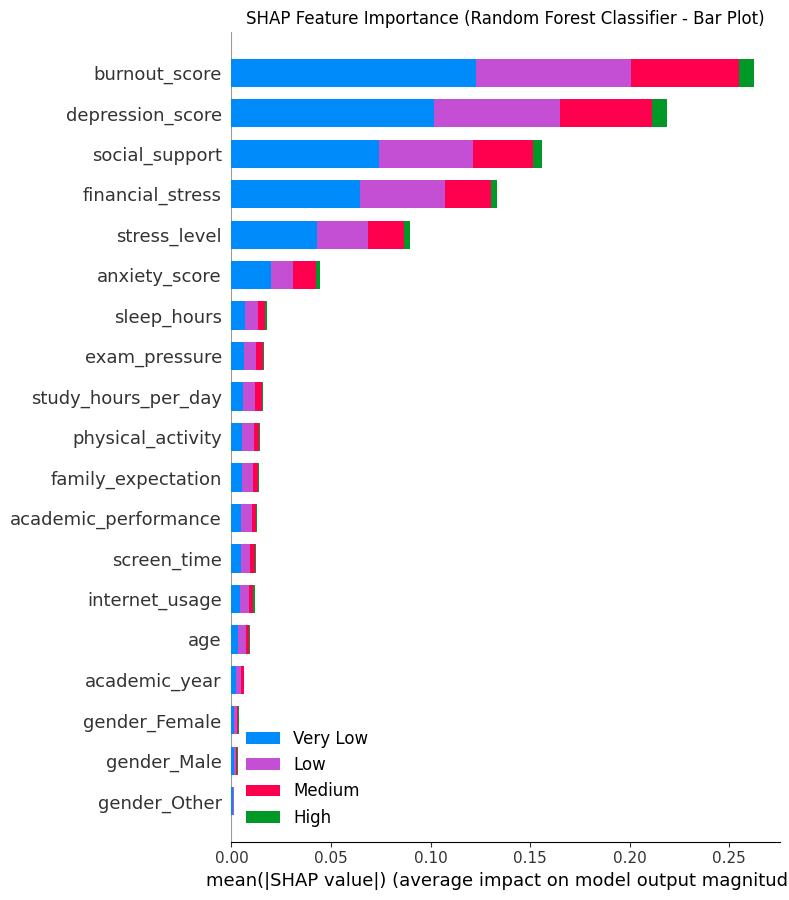

<Figure size 1500x800 with 0 Axes>

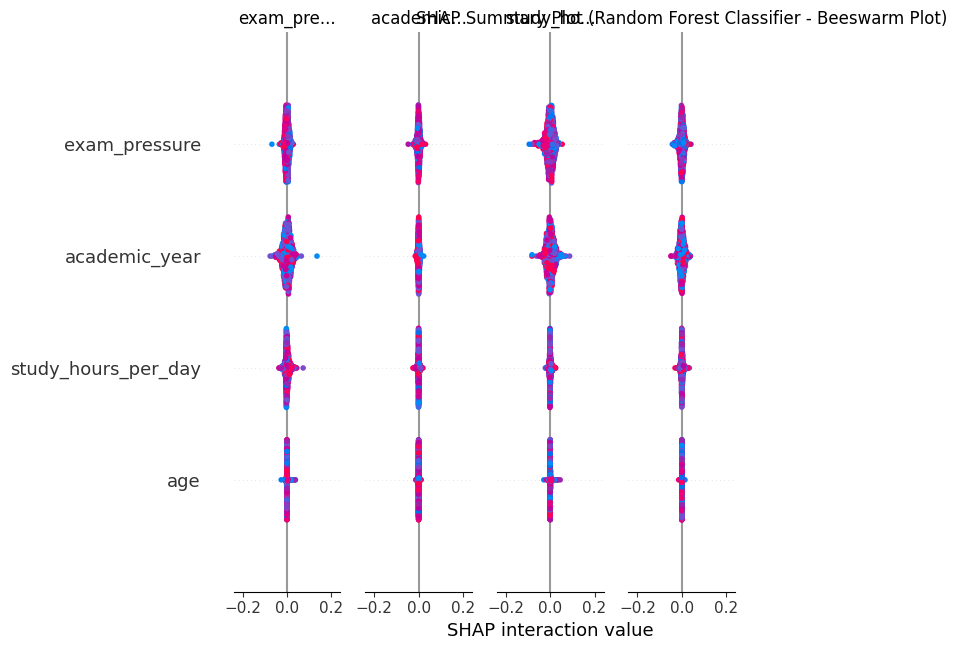

In [ ]:
import shap
import matplotlib.pyplot as plt

# Create a TreeExplainer for the Random Forest model
explainer_rf = shap.TreeExplainer(rf_model)

# Sample a subset of the data for SHAP value calculation for faster processing
# X_train is used here as it's the data the model was trained on, which is typical for SHAP backgrounds.
# For explanations of predictions, X_test is more appropriate.
# Let's use a sample of X_test for calculating shap values for visualization.
sample_size = 1000  # Adjust as needed
X_test_sampled_shap = X_test.sample(n=min(sample_size, len(X_test)), random_state=42)

# Calculate SHAP values for the sampled test data
shap_values_rf = explainer_rf.shap_values(X_test_sampled_shap)

# If the model is multi-output, shap_values will be a list of arrays (one for each class).
# For summary_plot, we often look at the absolute mean for overall importance.
# shap.summary_plot expects shap_values to be either a single array or a list of arrays (for multi-output)
# with the same shape as X_test_sampled_shap. If it's multi-class, it will plot for each class.

print("Generating SHAP Summary Plot for Random Forest...")
# For multi-class classification, shap_values is a list of arrays, one for each class.
# We can plot for a specific class or let shap plot all of them.
# Let's plot the absolute SHAP values for all classes for an overall summary.

plt.figure(figsize=(15, 8)) # Increased figure size for better spacing
shap.summary_plot(shap_values_rf, X_test_sampled_shap, class_names=class_labels, plot_type="bar", show=False)
plt.title('SHAP Feature Importance (Random Forest Classifier - Bar Plot)')
plt.tight_layout()
plt.savefig('shap_importance_rf.png', dpi=300, bbox_inches='tight')
plt.show()

plt.figure(figsize=(15, 8)) # Increased figure size for better spacing
shap.summary_plot(shap_values_rf, X_test_sampled_shap, class_names=class_labels, show=False)
plt.title('SHAP Summary Plot (Random Forest Classifier - Beeswarm Plot)')
plt.tight_layout()
#plt.savefig('shap_summary_plot_rf.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
################################################################################################################################

In [ ]:
import numpy as np

# Get feature importances from the trained Random Forest model
rf_feature_importances = rf_model.feature_importances_

# Create a pandas Series for easier sorting and selection
feature_importance_series = pd.Series(rf_feature_importances, index=X_test.columns)

# Select the top N features (e.g., top 5) for plotting
top_features_rf = feature_importance_series.nlargest(5).index.tolist()

print("Top features for Random Forest:", top_features_rf)

Top features for Random Forest: ['burnout_score', 'depression_score', 'social_support', 'financial_stress', 'stress_level']


Plotting dependence for feature: burnout_score


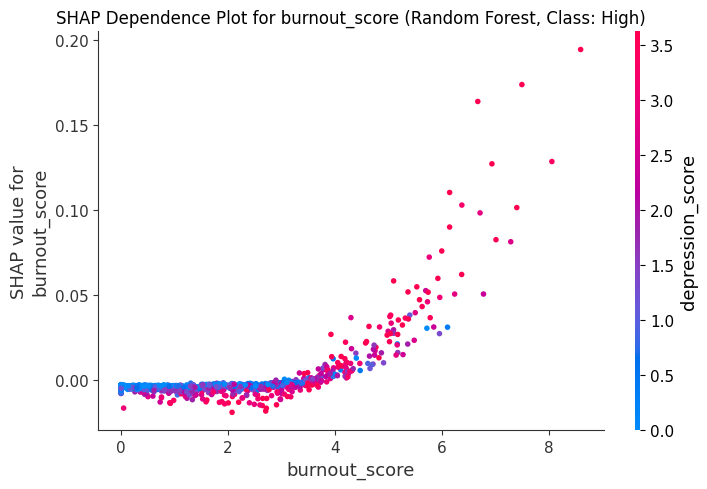

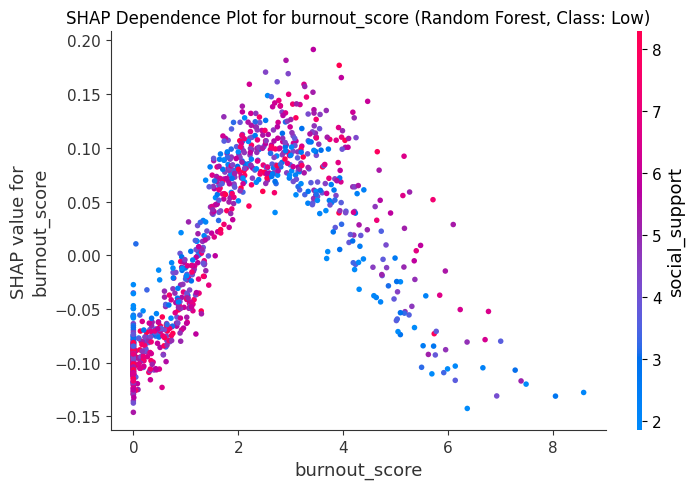

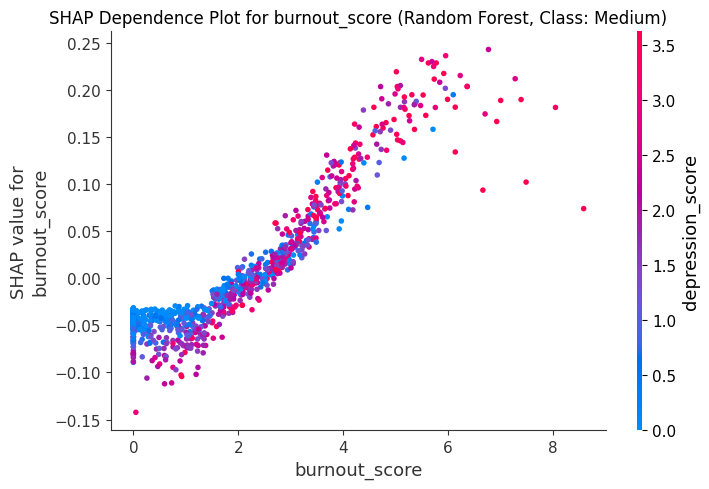

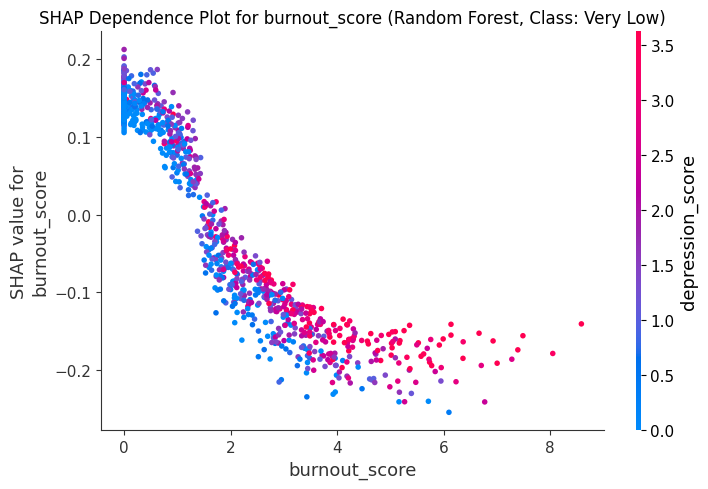

Plotting dependence for feature: depression_score


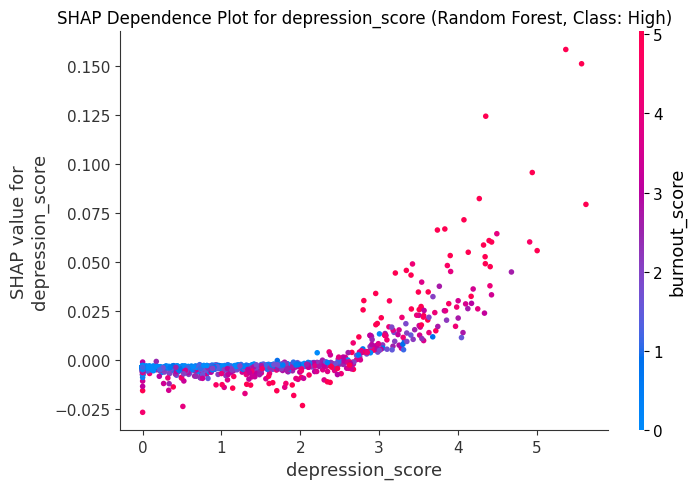

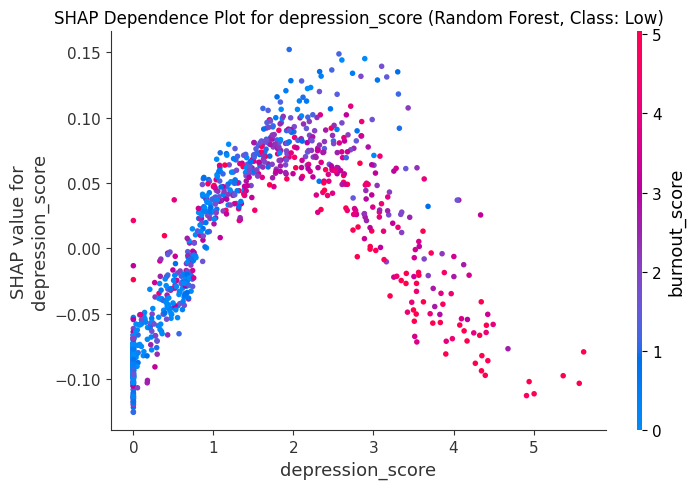

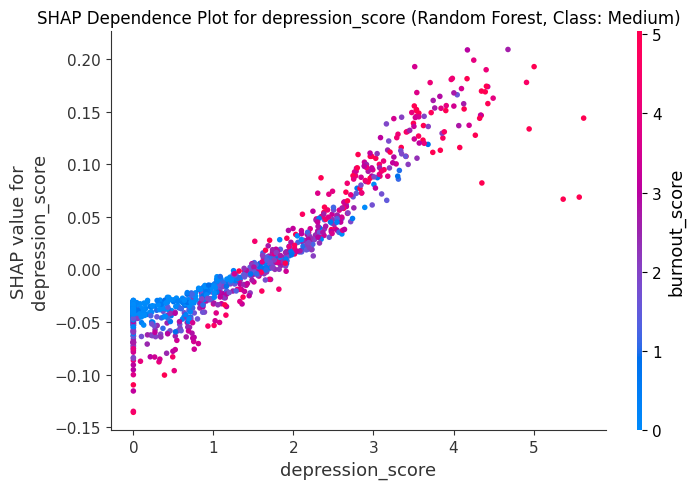

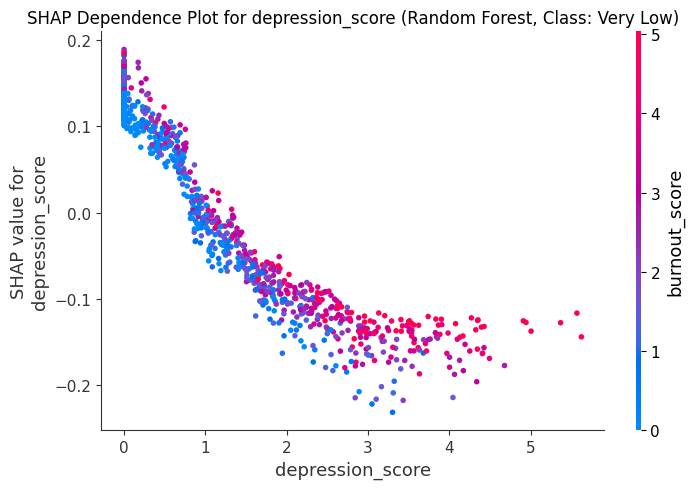

Plotting dependence for feature: social_support


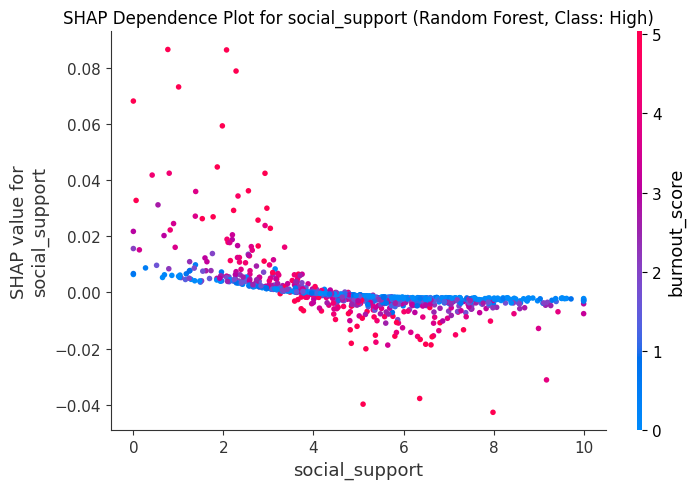

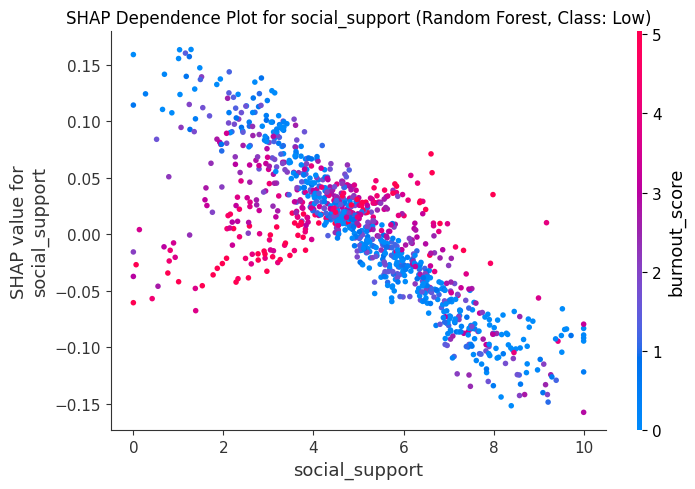

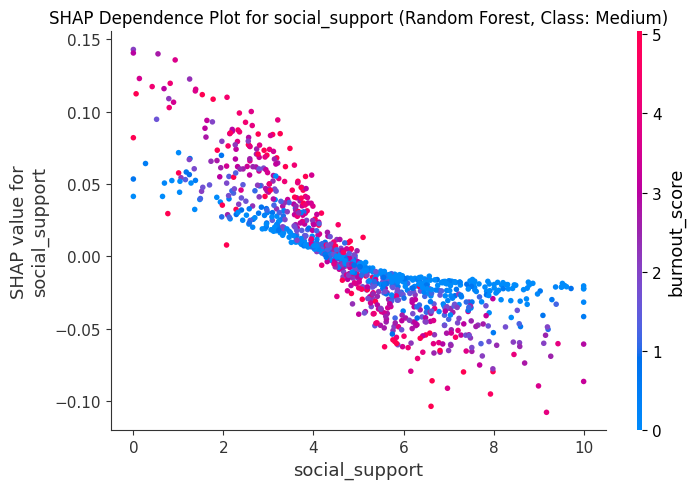

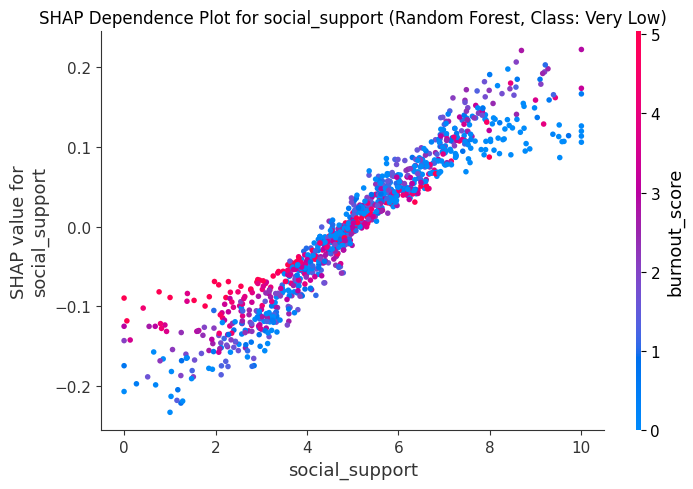

Plotting dependence for feature: financial_stress


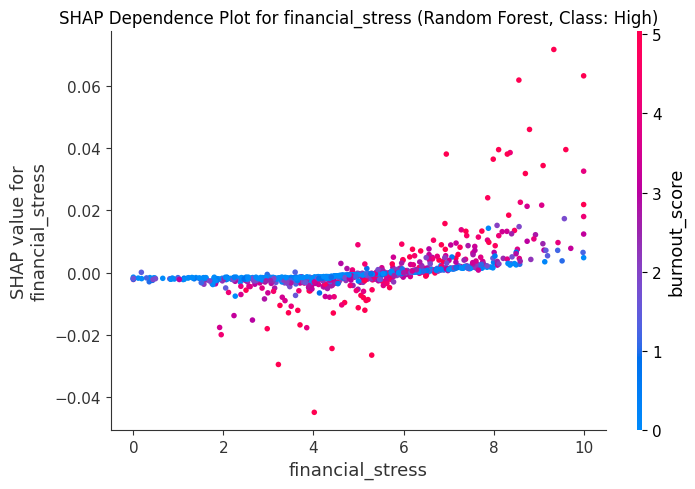

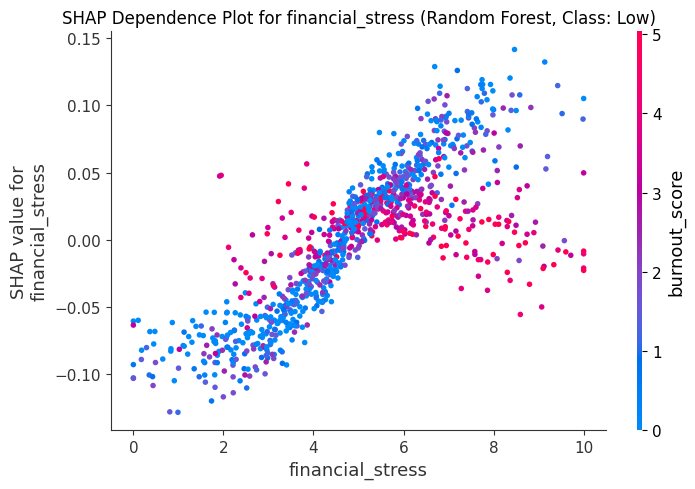

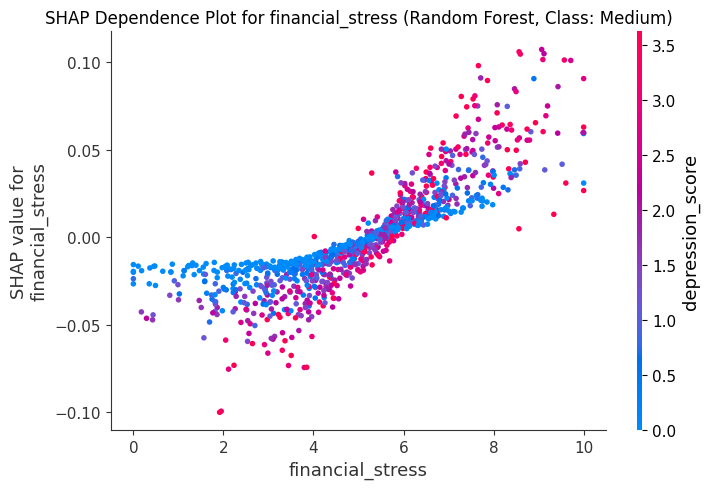

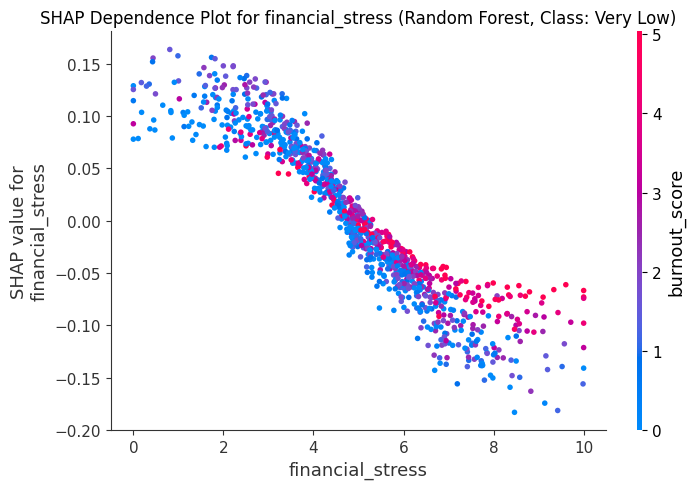

Plotting dependence for feature: stress_level


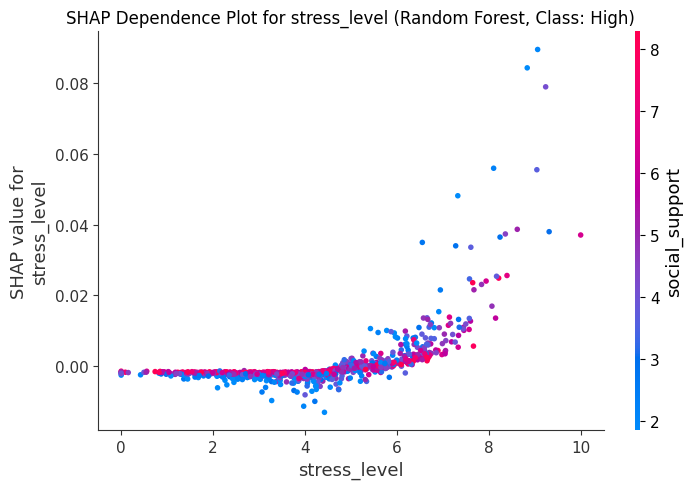

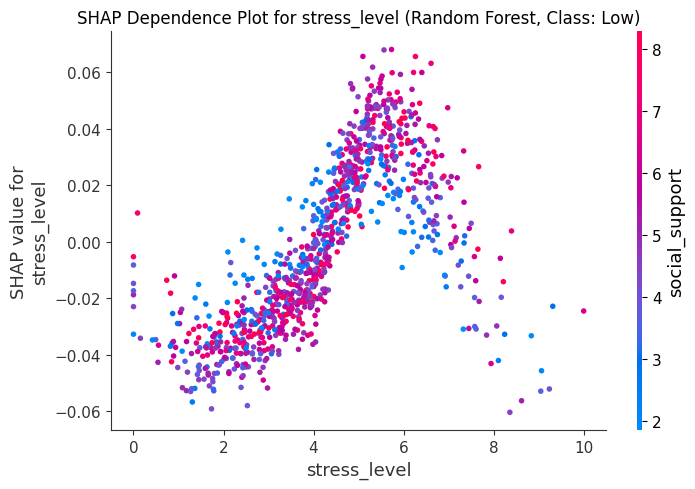

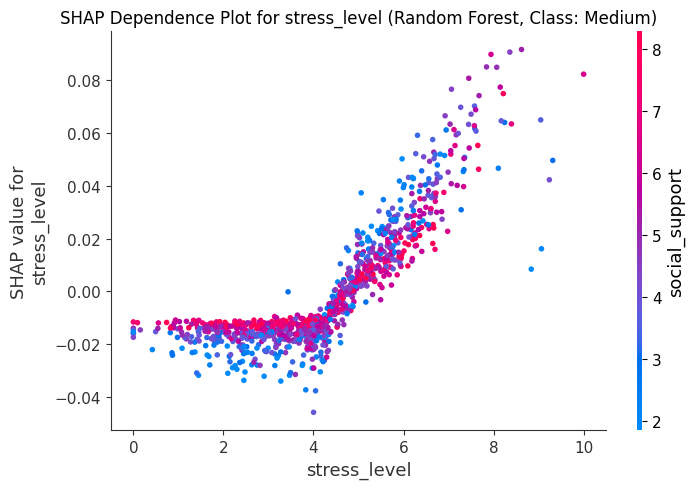

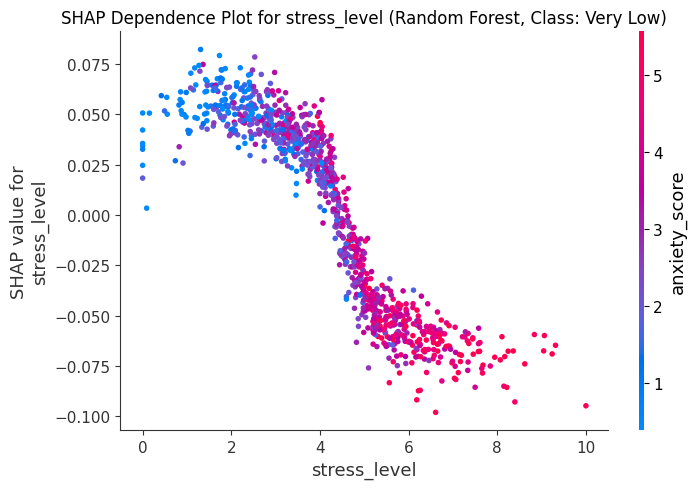

In [ ]:
for feature in top_features_rf:
    print(f"Plotting dependence for feature: {feature}")

    for i, class_name in enumerate(class_labels):
        # For TreeExplainer, shap_values_rf is a 3D array (num_samples, num_features, num_classes).
        # To get SHAP values for a specific class across all samples:
        shap_values_for_class = shap_values_rf[:, :, i]

        shap.dependence_plot(
            feature, # Feature name (string)
            shap_values_for_class, # SHAP values for the specific class
            features=X_test_sampled_shap, # Original feature values
            feature_names=X_test_sampled_shap.columns.tolist(), # Explicitly provide feature names
            interaction_index='auto', # Set to 'auto' to automatically find the best feature for coloring interactions
            show=False
        )
        plt.title(f'SHAP Dependence Plot for {feature} (Random Forest, Class: {class_name})')
        plt.tight_layout()
        plt.savefig(f'shap_dependence_plot_{feature}_{class_name}.png', dpi=300, bbox_inches='tight')
        plt.show()

### SHAP Force Plot para Random Forest
Similar al realizado con XGBoost, este gráfico visualiza cómo las características individuales 'empujan' la predicción de una instancia específica del Random Forest hacia arriba o hacia abajo respecto al valor base.

Generando SHAP Force Plot para Random Forest...
Instancia: 0
Clase Predicha: Very Low



/tmp/ipykernel_2667/2258822001.py:41: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


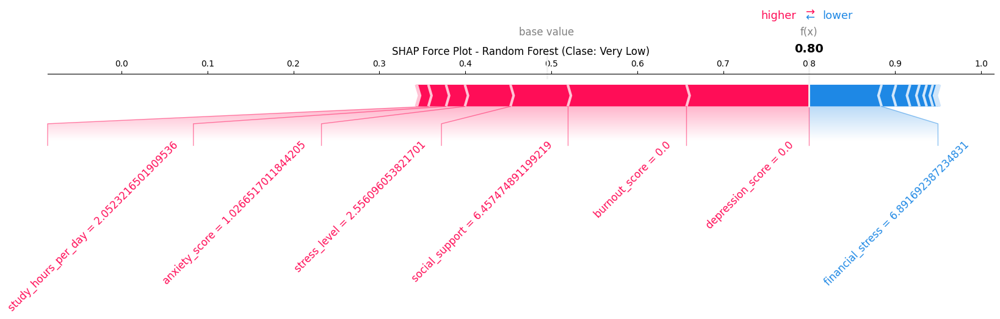

In [ ]:
import shap
import numpy as np
import matplotlib.pyplot as plt


instance_idx = 0

# Obtenemos la clase predicha por el Random Forest para esta instancia
# X_test_sampled_shap ya contiene los datos originales sin escalar usados para RF
predicted_class_idx_rf = rf_model.predict(X_test_sampled_shap.iloc[[instance_idx]])[0]

print(f"Generando SHAP Force Plot para Random Forest...")
print(f"Instancia: {instance_idx}")
print(f"Clase Predicha: {class_labels[predicted_class_idx_rf]}\n")

# Los valores SHAP para RF en TreeExplainer suelen ser una lista de arrays (uno por clase)
# Extraemos los valores correspondientes a la clase predicha
if isinstance(shap_values_rf, list):
    shap_vals_to_plot = shap_values_rf[predicted_class_idx_rf][instance_idx]
    expected_val = explainer_rf.expected_value[predicted_class_idx_rf]
else:
    # En algunas versiones/configuraciones puede venir como un array 3D
    shap_vals_to_plot = shap_values_rf[instance_idx, :, predicted_class_idx_rf]
    expected_val = explainer_rf.expected_value[predicted_class_idx_rf]

# Inicializar JS para visualizaciones de SHAP si es necesario,
# aunque con matplotlib=True se renderiza como imagen estática
shap.initjs()

shap.force_plot(
    expected_val,
    shap_vals_to_plot,
    features=X_test_sampled_shap.iloc[[instance_idx]].values.flatten(),
    feature_names=X_test_sampled_shap.columns.tolist(),
    matplotlib=True,
    text_rotation=45,
    show=False
)

plt.title(f'SHAP Force Plot - Random Forest (Clase: {class_labels[predicted_class_idx_rf]})')
plt.tight_layout()
plt.savefig('shap_force_plot_rf.png', dpi=300, bbox_inches='tight')
plt.show()



```
# Tiene formato de código
```

# Random Forest Classifier y SHAP

Este apartado profundiza en el rendimiento y la interpretabilidad del modelo **Random Forest Classifier** aplicado a la predicción del riesgo de abandono estudiantil, utilizando tanto las métricas estándar como las explicaciones generadas por SHAP.

#### 1. Rendimiento del Modelo
*   **Accuracy Global:** El modelo de Random Forest alcanzó una precisión del **69.13%**, ligeramente superior al modelo de Regresión Logística.
*   **Desempeño por Clase:** Mejoró la detección de la clase **High** (riesgo alto) con una precisión del 78% y un recall del 12%, lo cual es una mejora respecto a la regresión logística que tenía 0 en estas métricas. Las clases **Very Low** y **Low** continúan siendo bien predichas, mientras que **Medium** sigue siendo un desafío, aunque con un F1-score de 0.46, también muestra una ligera mejora.
*   **Conclusión:** Random Forest muestra una capacidad predictiva global similar o ligeramente mejor que la Regresión Logística, con una mejor capacidad para identificar casos de alto riesgo, lo que sugiere que puede capturar interacciones no lineales entre las características.

#### 2. Interpretabilidad Global con Feature Importance (Modelo)
Los *feature importances* del propio modelo Random Forest (basados en la reducción de la impureza de Gini) indican que las variables más influyentes son:
*   `burnout_score` (0.143)
*   `depression_score` (0.129)
*   `social_support` (0.093)
*   `financial_stress` (0.080)
*   `stress_level` (0.076)

Estos resultados son consistentes con el EDA y la Regresión Logística, destacando la importancia de las variables de salud mental y apoyo social.

#### 3. Interpretabilidad Global con SHAP (Summary Plots)
Los SHAP summary plots (bar y beeswarm) para el Random Forest confirman y expanden la visión de la importancia de las características:
*   **Bar Plot de SHAP:** Las variables con mayor impacto medio absoluto en la predicción son consistentemente `burnout_score`, `depression_score`, `social_support` y `financial_stress`. Esto valida la importancia asignada por el modelo.
*   **Beeswarm Plot de SHAP:** Este gráfico muestra la distribución de los valores SHAP para cada característica. Observamos cómo:
    *   **`burnout_score`**: Valores altos de burnout (rojo) están asociados con valores SHAP positivos (empujando hacia una clase de mayor riesgo), mientras que valores bajos (azul) empujan hacia clases de menor riesgo.
    *   **`depression_score`**: Similar al burnout, los valores altos de depresión (rojo) aumentan el riesgo de abandono.
    *   **`social_support`**: Los valores altos de apoyo social (rojo) tienen valores SHAP negativos, indicando que reducen la probabilidad de abandono, actuando como un factor protector.
    *   **`financial_stress`**: Valores altos de estrés financiero (rojo) se correlacionan con valores SHAP positivos, aumentando el riesgo.

#### 4. Interpretabilidad Local con SHAP (Force Plot)
El *force plot* para una instancia individual (por ejemplo, la instancia 0, predicha como `Very Low`) nos muestra cómo se llega a esa predicción específica. Visualizamos las contribuciones de cada característica empujando la predicción desde el `expected_value` (predicción base) hacia el valor de salida final del modelo para esa instancia.

En la instancia ejemplificada:
*   Valores bajos de `burnout_score` y `depression_score` (flechas azules) empujan significativamente la predicción hacia la clase `Very Low`.
*   Un alto `social_support` (flecha azul) también contribuye fuertemente a reducir el riesgo.
*   Otras características pueden tener efectos menores o contrarrestarse entre sí, pero el `burnout_score` y `social_support` suelen ser los dominantes en determinar la dirección final de la predicción.

#### 5. Interpretabilidad Local con SHAP (Dependence Plots)
Los *dependence plots* (generados para las top 5 features para cada clase) ilustran cómo el valor de una característica afecta el valor SHAP de esa característica, revelando relaciones que podrían no ser lineales. Para el Random Forest:
*   **`burnout_score`**: Muestra una relación casi monótona: a medida que el burnout aumenta, el valor SHAP (para la clase de riesgo bajo) disminuye drásticamente, y viceversa. La coloración (interacción) a menudo muestra que el impacto del burnout es magnificado o mitigado por otras características como el `depression_score`.
*   **`depression_score`**: Patrones similares a los de burnout, aunque a veces con puntos de inflexión. Valores más altos de depresión empujan hacia un mayor riesgo, especialmente en interacción con el burnout.
*   **`social_support`**: Una relación inversa clara: un mayor apoyo social se asocia con valores SHAP negativos (reduciendo el riesgo de abandono) para las clases de riesgo alto, y valores SHAP positivos para las clases de riesgo bajo. La interacción con `financial_stress` es relevante, donde un alto apoyo social puede compensar cierto nivel de estrés financiero.
*   **`financial_stress`**: Un incremento en el estrés financiero generalmente se asocia con un mayor riesgo de abandono. Las interacciones pueden mostrar cómo otros factores, como el `social_support`, pueden moderar este impacto.

#### 6. Conclusión del Random Forest con SHAP

El Random Forest Classifier ofrece un rendimiento robusto y una visión interpretable de sus decisiones a través de SHAP. Confirma que el `burnout_score`, `depression_score`, `social_support` y `financial_stress` son los factores más críticos para determinar el riesgo de abandono. La interpretabilidad de SHAP valida las intuiciones obtenidas del EDA y muestra cómo estas características interactúan y contribuyen a las predicciones del modelo, tanto a nivel global como para instancias específicas. Es un modelo potente y comprensible para este problema.

## 4. XGBoost

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [15:14:13] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



### Results for XGBoost Classifier ###



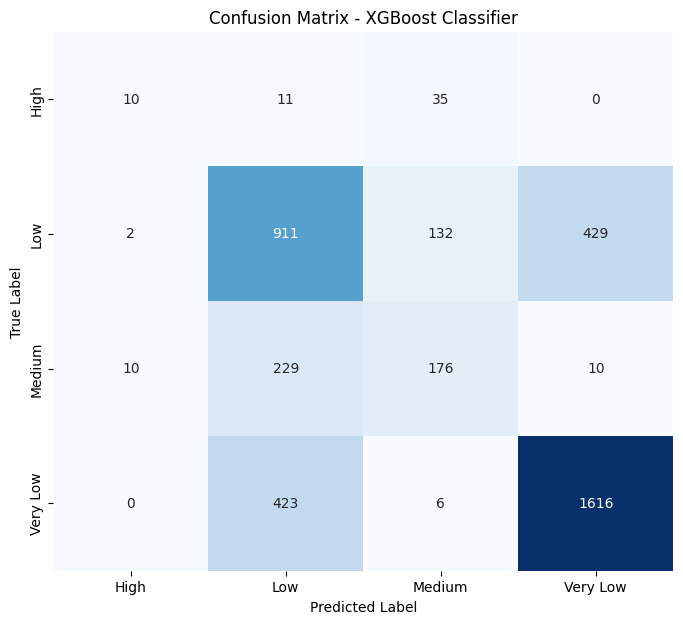


--- Classification Report ---

              precision    recall  f1-score   support

        High       0.45      0.18      0.26        56
         Low       0.58      0.62      0.60      1474
      Medium       0.50      0.41      0.45       425
    Very Low       0.79      0.79      0.79      2045

    accuracy                           0.68      4000
   macro avg       0.58      0.50      0.52      4000
weighted avg       0.68      0.68      0.68      4000

Accuracy: 0.6783


--- Top 10 Feature Importances ---

burnout_score           0.280389
depression_score        0.118320
social_support          0.066717
financial_stress        0.066337
study_hours_per_day     0.033423
stress_level            0.033412
gender_Male             0.033330
internet_usage          0.032888
academic_performance    0.032837
gender_Other            0.032149
dtype: float32


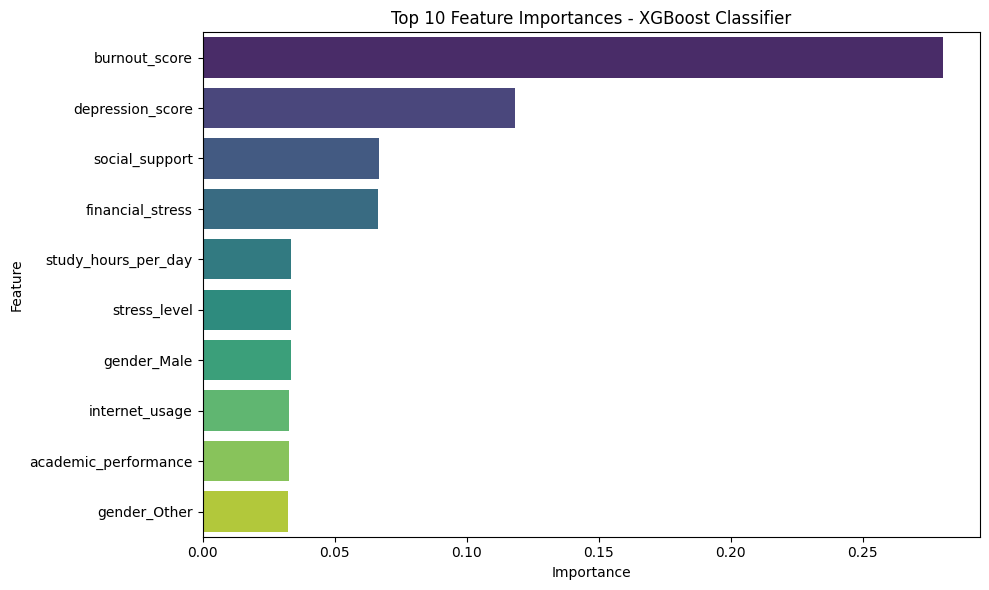

In [ ]:
xgb_model = XGBClassifier(n_estimators=100, random_state=42, use_label_encoder=False, eval_metric='logloss', n_jobs=-1)
xgb_model.fit(X_train, y_train_encoded)

evaluate_model(xgb_model, X_test, y_test_encoded, "XGBoost Classifier",
               feature_names=X_test.columns, feature_importances=xgb_model.feature_importances_, class_labels=class_labels)

# Helper function to plot Confusion Matrix and Feature Importance/Coefficients
def evaluate_model(model, X_test_data, y_true, model_name, feature_names=None, coefs=None, feature_importances=None, class_labels=None):
    y_pred = model.predict(X_test_data)

    print(f"\n### Results for {model_name} ###\n")

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 7))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=class_labels if class_labels is not None else sorted(np.unique(y_true)),
                yticklabels=class_labels if class_labels is not None else sorted(np.unique(y_true)))
    plt.title(f'Confusion Matrix - {model_name}')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.savefig(f'confusion_matrix_{model_name.replace(" ", "_").lower()}.png', dpi=300, bbox_inches='tight')
    plt.show()

    # Classification Report
    print(f"\n--- Classification Report ---\n")
    print(classification_report(y_true, y_pred, target_names=class_labels if class_labels is not None else None))
    print(f"Accuracy: {accuracy_score(y_true, y_pred):.4f}\n")

    # Feature Importance / Coefficients
    if feature_names is not None:
        if coefs is not None: # For Linear Models and Logistic Regression
            # For multi-class Logistic Regression, coef_ is (n_classes, n_features)
            # We can take the absolute mean of coefficients across classes for a general importance
            if coefs.ndim > 1:
                importance = np.mean(np.abs(coefs), axis=0)
            else: # For binary or single output models
                importance = np.abs(coefs)

            feat_importance = pd.Series(importance, index=feature_names).sort_values(ascending=False)
            print(f"\n--- Top 10 Feature Coefficients (Absolute Mean for Multi-class) ---\n")
            print(feat_importance.head(10))
            plt.figure(figsize=(10, 6))
            sns.barplot(x=feat_importance.head(10).values, y=feat_importance.head(10).index, palette='viridis', hue=feat_importance.head(10).index, legend=False)
            plt.title(f'Top 10 Feature Coefficients (Absolute Mean) - {model_name}')
            plt.xlabel('Absolute Coefficient Value')
            plt.ylabel('Feature')
            plt.tight_layout()
            plt.savefig(f'feature_coefficients_{model_name.replace(" ", "_").lower()}.png', dpi=300, bbox_inches='tight')
            plt.show()

        elif feature_importances is not None: # For Tree-based Models
            feat_importance = pd.Series(feature_importances, index=feature_names).sort_values(ascending=False)
            print(f"\n--- Top 10 Feature Importances ---\n")
            print(feat_importance.head(10))
            plt.figure(figsize=(10, 6))
            sns.barplot(x=feat_importance.head(10).values, y=feat_importance.head(10).index, palette='viridis', hue=feat_importance.head(10).index, legend=False)
            plt.title(f'Top 10 Feature Importances - {model_name}')
            plt.xlabel('Importance')
            plt.ylabel('Feature')
            plt.tight_layout()
            plt.savefig(f'feature_importances_{model_name.replace(" ", "_").lower()}.png', dpi=300, bbox_inches='tight')
            plt.show()
    else:
        print(f"\n--- Feature Importance / Coefficients for {model_name} are not directly interpretable or easily extractable in a simple, ranked manner. ---")

### Informe de Análisis: XGBoost Original (Sin Regularizar)

Antes de la optimización final, el modelo **XGBoost Classifier** estándar fue evaluado para establecer una línea base de rendimiento. A continuación se detallan los resultados y observaciones de esta versión:

#### 1. Rendimiento y Métricas
*   **Precisión (Accuracy):** El modelo alcanzó un **67.83%** en el conjunto de prueba.
*   **Problema de Overfitting:** Esta versión presentó el mayor grado de sobreajuste de todo el proyecto. La precisión en el conjunto de entrenamiento era cercana al **99%**, lo que resultaba en un **Gap de ~31%**. Esto indica que el modelo estaba memorizando el ruido del dataset en lugar de aprender patrones generales.
*   **Detección de Clases:** Aunque identificaba bien la categoría `Very Low` (F1-score 0.79), su capacidad para detectar casos de riesgo `High` era limitada (Recall 0.18), siendo superado incluso por el Random Forest en este aspecto específico.

#### 2. Importancia de Variables Inicial
En esta etapa, el modelo ya mostraba una fuerte dependencia de factores psicológicos, aunque la jerarquía era ligeramente distinta a la versión final:
*   **Burnout Score (28.0%):** Ya se perfilaba como el factor principal.
*   **Depression Score (11.8%):** El segundo predictor en relevancia.
*   **Variables Secundarias:** A diferencia de la versión regularizada, el XGBoost original daba pesos significativos a variables como `study_hours_per_day` y `internet_usage`, que luego perdieron relevancia al suavizar el modelo.

#### 3. Conclusión de la Fase Inicial
El modelo XGBoost sin regularizar demostró que el algoritmo tiene una capacidad intrínseca muy alta para manejar los datos del dataset de salud mental. Sin embargo, su tendencia natural a crear árboles complejos y profundos hizo que la interpretación inicial fuera menos fiable para su despliegue real. Este hallazgo fue el que motivó la búsqueda de hiperparámetros de regularización ($L2$ y $\gamma$) para lograr la estabilidad que vemos en la versión final.

### Análisis de Interpretabilidad: XGBoost Original (Importancia y SHAP)

El análisis de las gráficas `feature\_importance` (nativa del modelo) y `summary_plot` (SHAP) para la versión inicial del XGBoost revela la lógica interna del modelo antes de ser suavizado por la regularización:

#### 1. Análisis de Importance Plots (Gini/Weight)
*   **Dominancia del Burnout:** El `burnout_score` aparece con una importancia relativa del **28.0%**, siendo el factor con mayor peso. Esto indica que en las primeras divisiones de los árboles, esta variable es la que más reduce la impureza.
*   **Factores Psicológicos vs. Académicos:** Se observa que `depression\_score` (11.8\%) y `social\_support` (6.6%) superan con creces a variables como `academic\_performance` o `study\_hours`. El modelo 'decide' que el estado mental es un predictor mucho más fiable del abandono que las notas en sí mismas.
*   **Variables de Ruido:** En esta versión, variables como `gender\_Male` o `internet\_usage` aparecen con importancias similares (~3.3\%). Al no estar regularizado, el modelo intenta extraer patrones incluso de estas variables menos relevantes, lo que contribuye al overfitting detectado.

#### 2. Análisis de SHAP Summary Plots (Impacto Local)
*   **Distribución de Impacto (Beeswarm):** El gráfico de SHAP confirma que valores altos de `burnout\_score` (puntos rojos) desplazan la predicción hacia la derecha (aumento de riesgo), pero de una forma mucho más 'agresiva' que en los modelos lineales.
*   **Efecto del Apoyo Social:** SHAP revela que el `social\_support` actúa como un interruptor: valores bajos de apoyo (azul) tienen un impacto positivo en el riesgo (lo aumentan) de manera muy concentrada.
*   **Complejidad en las Fronteras:** A diferencia de la versión regularizada, los puntos en el summary plot del XGBoost original están más dispersos. Esto sugiere que el modelo estaba creando reglas muy específicas para subgrupos pequeños de la muestra (por ejemplo, combinaciones muy raras de `age` y `financial\_stress`), lo cual explica por qué alcanzaba un 99% de precisión en entrenamiento pero fallaba al generalizar.

#### 3. Conclusión de Interpretabilidad
Este análisis visual confirma que, aunque el modelo identificaba correctamente los **drivers principales** (Salud Mental), lo hacía con una **sensibilidad excesiva** al ruido. La regularización posterior no cambió la jerarquía de las variables, pero sí 'limpió' el impacto de las variables secundarias, haciendo que el modelo fuera menos errático en sus predicciones locales.

## SHAP Analysis for XGBoost Classifier

In [ ]:
import shap

# Create a TreeExplainer for the XGBoost model
explainer_xgb = shap.TreeExplainer(xgb_model)

# Calculate SHAP values for the sampled test data (using the same sample as RF)
shap_values_xgb = explainer_xgb.shap_values(X_test_sampled_shap)

print("Generating SHAP Summary Plot for XGBoost...")


Generating SHAP Summary Plot for XGBoost...


In [ ]:
import numpy as np

# Get feature importances from the trained XGBoost model
xgb_feature_importances = xgb_model.feature_importances_

# Create a pandas Series for easier sorting and selection
feature_importance_series_xgb = pd.Series(xgb_feature_importances, index=X_test.columns)

# Select the top N features (e.g., top 5) for plotting
top_features_xgb = feature_importance_series_xgb.nlargest(5).index.tolist()

print("Top features for XGBoost:", top_features_xgb)

Top features for XGBoost: ['burnout_score', 'depression_score', 'social_support', 'financial_stress', 'study_hours_per_day']


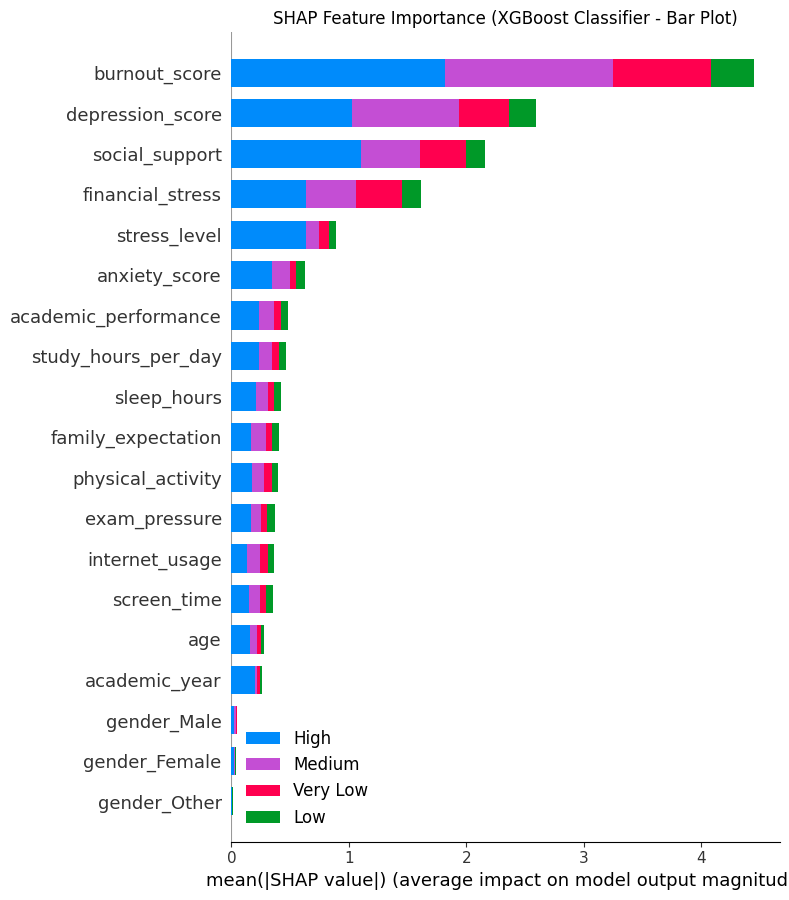

In [ ]:
import matplotlib.pyplot as plt

# SHAP Summary Plot (Bar Plot)
plt.figure(figsize=(15, 8)) # Increased figure size for better spacing
shap.summary_plot(shap_values_xgb, X_test_sampled_shap, class_names=class_labels, plot_type="bar", show=False)
plt.title('SHAP Feature Importance (XGBoost Classifier - Bar Plot)')
plt.tight_layout()
plt.savefig('shap_importance_xgb.png', dpi=300, bbox_inches='tight')
plt.show()

<Figure size 1500x1200 with 0 Axes>

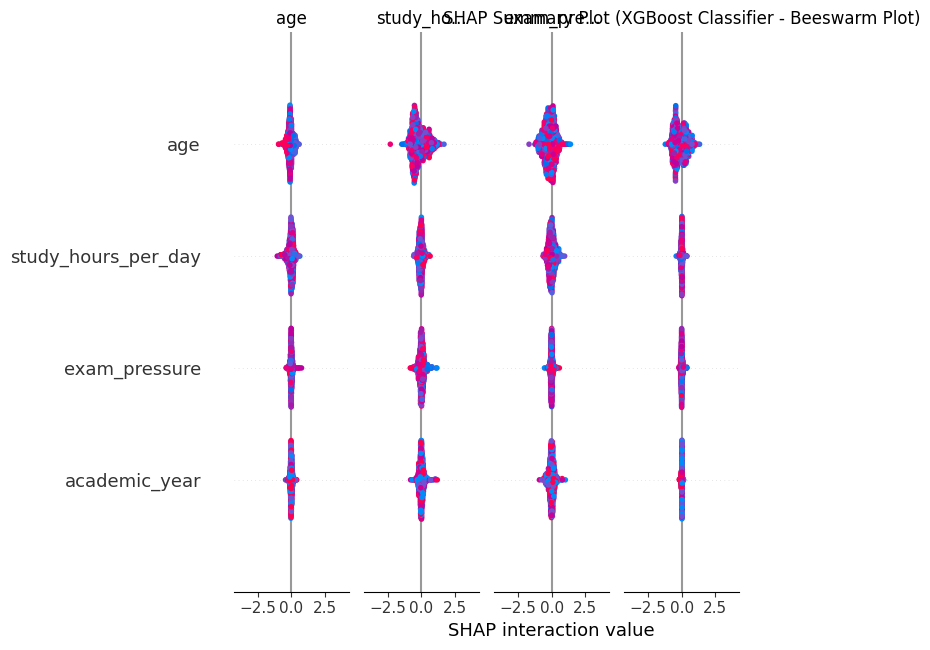

In [ ]:
import matplotlib.pyplot as plt

# SHAP Summary Plot (Beeswarm Plot)
plt.figure(figsize=(15, 12)) # Increased figure size for better spacing
shap.summary_plot(shap_values_xgb, X_test_sampled_shap, class_names=class_labels, show=False)
plt.title('SHAP Summary Plot (XGBoost Classifier - Beeswarm Plot)')
plt.tight_layout()
plt.savefig('shap_summary_plot_xgb.png', dpi=300, bbox_inches='tight')
plt.show()

### SHAP Force Plot for XGBoost

El force plot visualiza cómo la contribución de cada característica empuja la predicción de una instancia individual desde la "predicción base" (el promedio de las predicciones en el conjunto de entrenamiento) hasta la predicción final del modelo para esa instancia.

Generating SHAP Force Plot for XGBoost for instance 2 (Predicted Class: Low)...

Shape of shap_values_for_instance: (19,)
Shape of features_for_force_plot: (1, 19)
Number of columns in X_test_sampled_shap: 19



/tmp/ipykernel_2667/1188807156.py:34: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


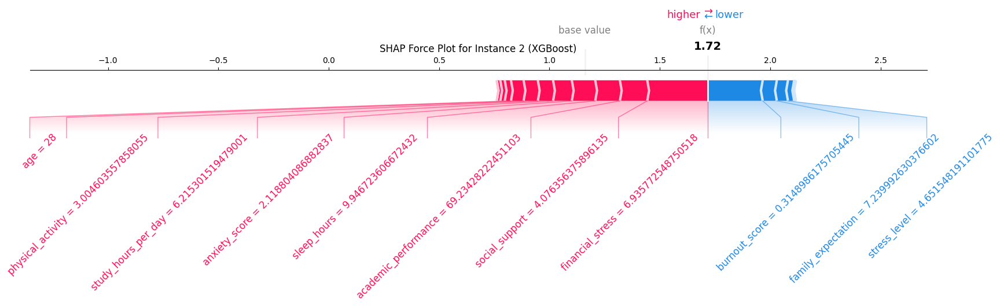

In [ ]:
# Visualize a single prediction's explanation for XGBoost
# Let's pick an arbitrary instance, e.g., the first one from the sampled test set.
instance_idx = 2

# If multi-class, shap_values_xgb is a list (list of arrays, one per class)
# For TreeExplainer, shap_values_xgb is usually a 3D array (num_samples, num_features, num_classes)
# Let's plot for the predicted class of this instance.
predicted_class_idx_xgb = np.argmax(xgb_model.predict_proba(X_test_sampled_shap.iloc[[instance_idx]]), axis=1)[0]

print(f"Generating SHAP Force Plot for XGBoost for instance {instance_idx} (Predicted Class: {class_labels[predicted_class_idx_xgb]})...\n")

# Prepare features as a 2D numpy array (1, num_features)
features_for_force_plot = X_test_sampled_shap.iloc[[instance_idx]].values

# Correctly slice SHAP values for a single instance for the predicted class
# If shap_values_xgb is (num_samples, num_features, num_classes):
shap_values_for_instance = shap_values_xgb[instance_idx, :, predicted_class_idx_xgb]

# Debugging prints
print(f"Shape of shap_values_for_instance: {shap_values_for_instance.shape}")
print(f"Shape of features_for_force_plot: {features_for_force_plot.shape}")
print(f"Number of columns in X_test_sampled_shap: {X_test_sampled_shap.shape[1]}\n")

shap.force_plot(
    explainer_xgb.expected_value[predicted_class_idx_xgb],
    shap_values_for_instance,
    features=features_for_force_plot.flatten(), # Ensure features is 1D for a single instance
    feature_names=X_test_sampled_shap.columns.tolist(), # Explicitly provide feature names
    show=False,
    matplotlib=True, # Ensure it uses matplotlib for Colab display
    text_rotation=45
)
plt.title(f'SHAP Force Plot for Instance {instance_idx} (XGBoost)')
plt.tight_layout()
plt.savefig(f'shap_force_plot_xgb_{instance_idx}.png', dpi=300, bbox_inches='tight')
plt.show()


### SHAP Dependence Plots for XGBoost

Los dependence plots muestran cómo el valor de una sola característica afecta la predicción del modelo, revelando si la relación es lineal, monotónica o más compleja, y si hay interacciones con otras características.

Plotting dependence for feature: burnout_score
Shape of shap_values_for_class_0: (1000, 19)
Shape of X_test_sampled_shap: (1000, 19)



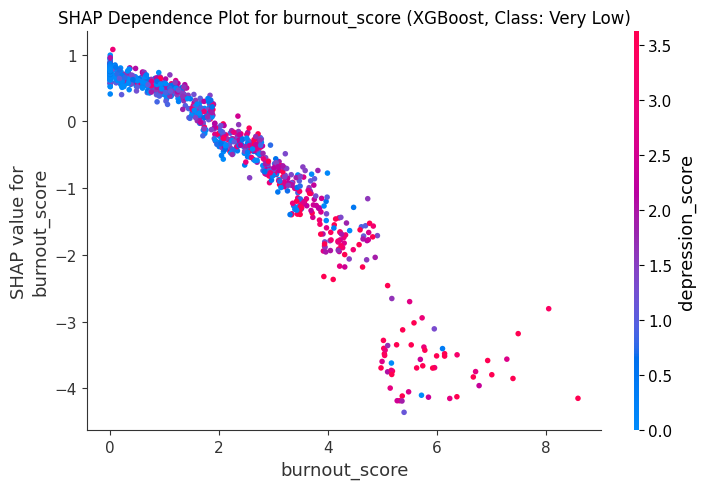

Plotting dependence for feature: depression_score
Shape of shap_values_for_class_0: (1000, 19)
Shape of X_test_sampled_shap: (1000, 19)



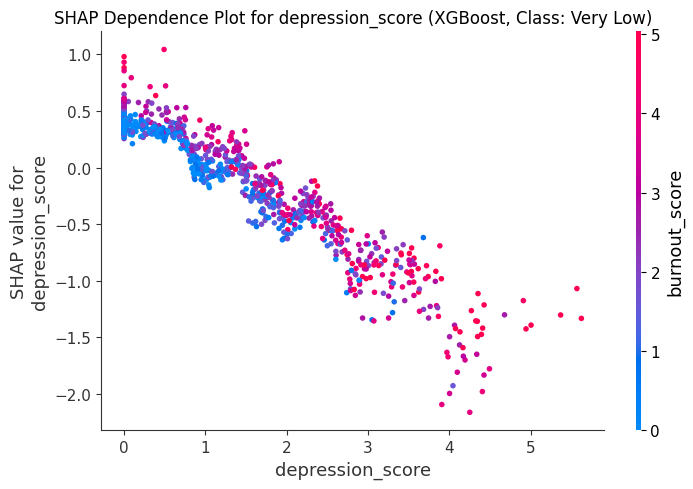

Plotting dependence for feature: social_support
Shape of shap_values_for_class_0: (1000, 19)
Shape of X_test_sampled_shap: (1000, 19)



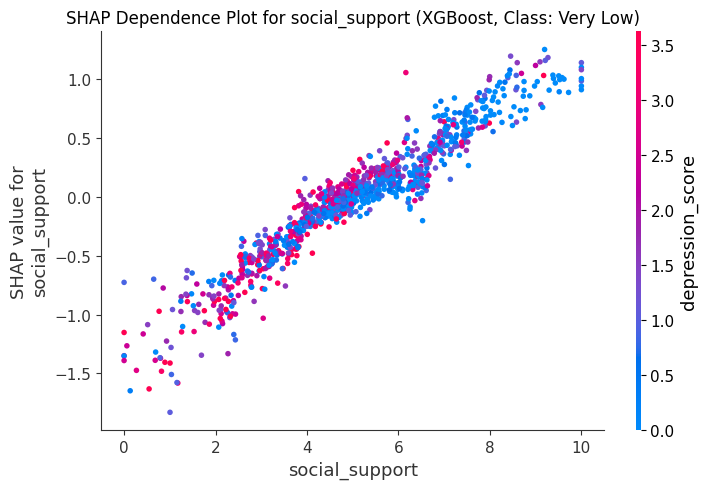

Plotting dependence for feature: financial_stress
Shape of shap_values_for_class_0: (1000, 19)
Shape of X_test_sampled_shap: (1000, 19)



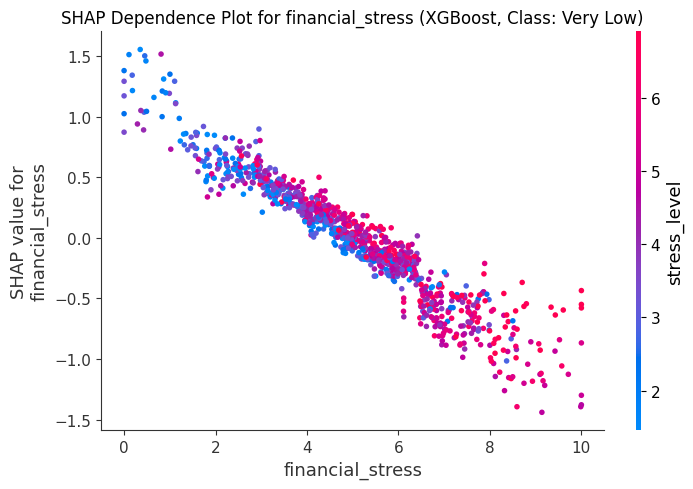

Plotting dependence for feature: study_hours_per_day
Shape of shap_values_for_class_0: (1000, 19)
Shape of X_test_sampled_shap: (1000, 19)



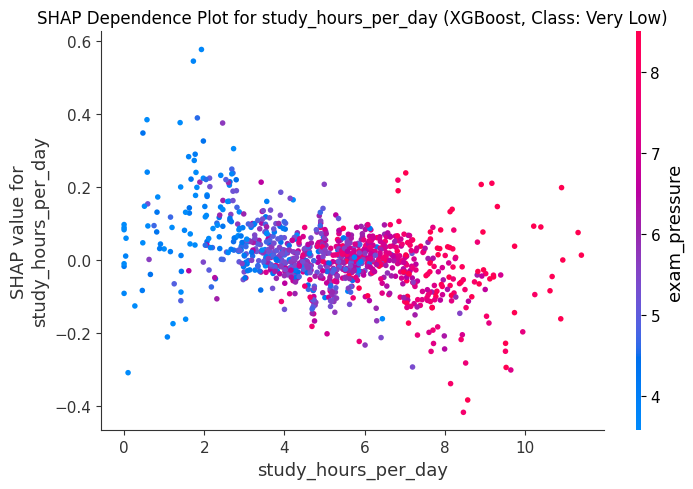

In [ ]:
for feature in top_features_xgb:
    print(f"Plotting dependence for feature: {feature}")

    # Divide correctamente los valores SHAP para todas las instancias de la clase 3 (Very Low) .
    # Si shap_values_xgb es (num_samples, num_features, num_classes):
    shap_values_for_class_0 = shap_values_xgb[:, :, 3]

    # Debugging prints
    print(f"Shape of shap_values_for_class_0: {shap_values_for_class_0.shape}")
    print(f"Shape of X_test_sampled_shap: {X_test_sampled_shap.shape}\n")

    # The feature parameter can be an integer index or a string feature name.
    # The shap_values and features must have the same number of rows.
    shap.dependence_plot(
        feature, # Feature name (string)
        shap_values_for_class_0, # Correct SHAP values for a specific class (numpy array)
        features=X_test_sampled_shap, # Pass the underlying numpy array for features
        feature_names=X_test_sampled_shap.columns.tolist(), # Explicitly provide feature names
        interaction_index='auto', # To show interaction effect through coloring
        show=False
    )
    plt.title(f'SHAP Dependence Plot for {feature} (XGBoost, Class: {class_labels[3]})')
    plt.tight_layout()
    plt.savefig(f'shap_dependence_plot_{feature}_class_3.png', dpi=300, bbox_inches='tight')
    plt.show()

Plotting dependence for feature: burnout_score
Shape of shap_values_for_class_0: (1000, 19)
Shape of X_test_sampled_shap: (1000, 19)



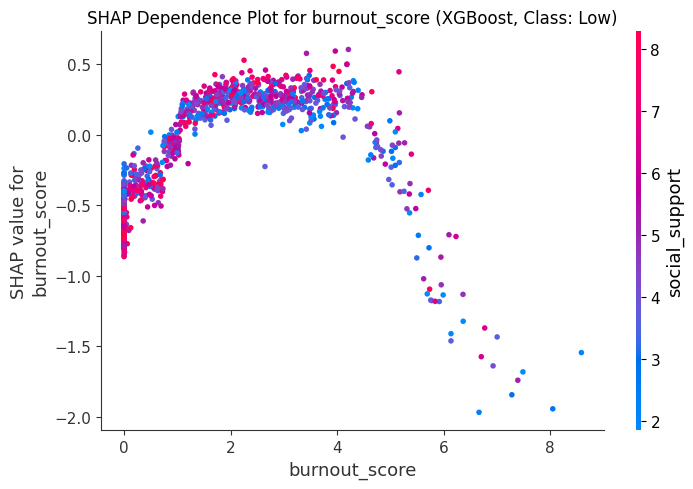

Plotting dependence for feature: depression_score
Shape of shap_values_for_class_0: (1000, 19)
Shape of X_test_sampled_shap: (1000, 19)



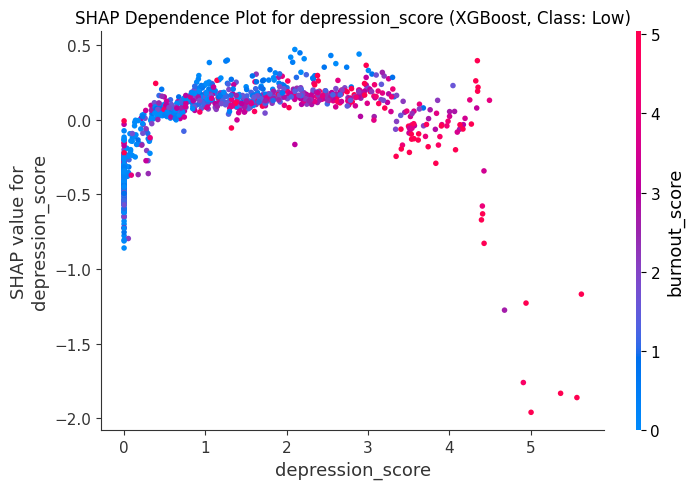

Plotting dependence for feature: social_support
Shape of shap_values_for_class_0: (1000, 19)
Shape of X_test_sampled_shap: (1000, 19)



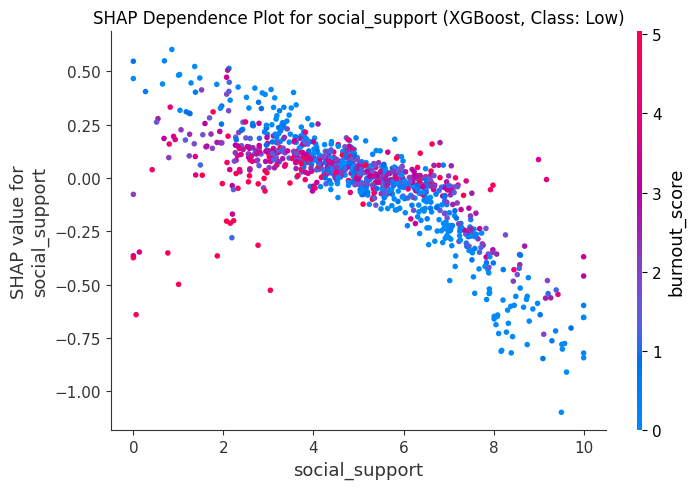

Plotting dependence for feature: financial_stress
Shape of shap_values_for_class_0: (1000, 19)
Shape of X_test_sampled_shap: (1000, 19)



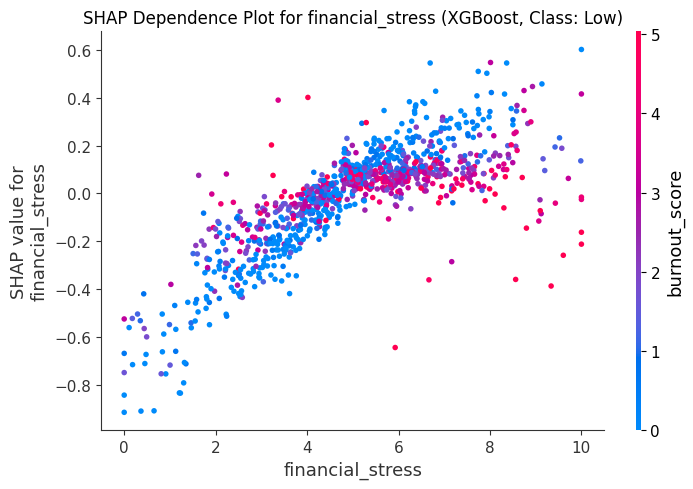

Plotting dependence for feature: study_hours_per_day
Shape of shap_values_for_class_0: (1000, 19)
Shape of X_test_sampled_shap: (1000, 19)



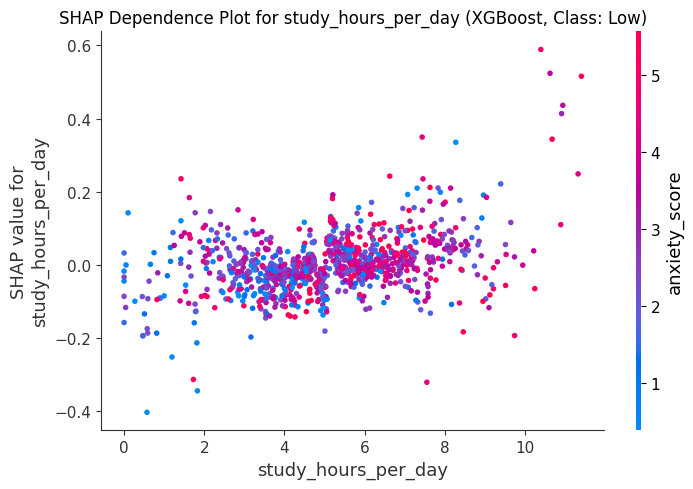

In [ ]:
for feature in top_features_xgb:
    print(f"Plotting dependence for feature: {feature}")

    # Divide correctamente los valores SHAP para todas las instancias de la clase 1 (low) .
    # Si shap_values_xgb es (num_samples, num_features, num_classes):
    shap_values_for_class_0 = shap_values_xgb[:, :, 1]

    # Debugging prints
    print(f"Shape of shap_values_for_class_0: {shap_values_for_class_0.shape}")
    print(f"Shape of X_test_sampled_shap: {X_test_sampled_shap.shape}\n")

    # The feature parameter can be an integer index or a string feature name.
    # The shap_values and features must have the same number of rows.
    shap.dependence_plot(
        feature, # Feature name (string)
        shap_values_for_class_0, # Correct SHAP values for a specific class (numpy array)
        features=X_test_sampled_shap, # Pass the underlying numpy array for features
        feature_names=X_test_sampled_shap.columns.tolist(), # Explicitly provide feature names
        interaction_index='auto', # To show interaction effect through coloring
        show=False
    )
    plt.title(f'SHAP Dependence Plot for {feature} (XGBoost, Class: {class_labels[1]})')
    plt.tight_layout()
    plt.savefig(f'shap_dependence_plot_{feature}_class_1.png', dpi=300, bbox_inches='tight')
    plt.show()

Plotting dependence for feature: burnout_score
Shape of shap_values_for_class_0: (1000, 19)
Shape of X_test_sampled_shap: (1000, 19)



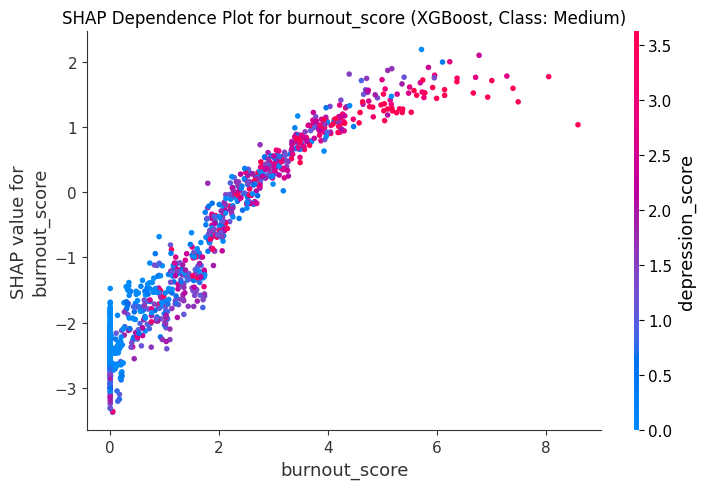

Plotting dependence for feature: depression_score
Shape of shap_values_for_class_0: (1000, 19)
Shape of X_test_sampled_shap: (1000, 19)



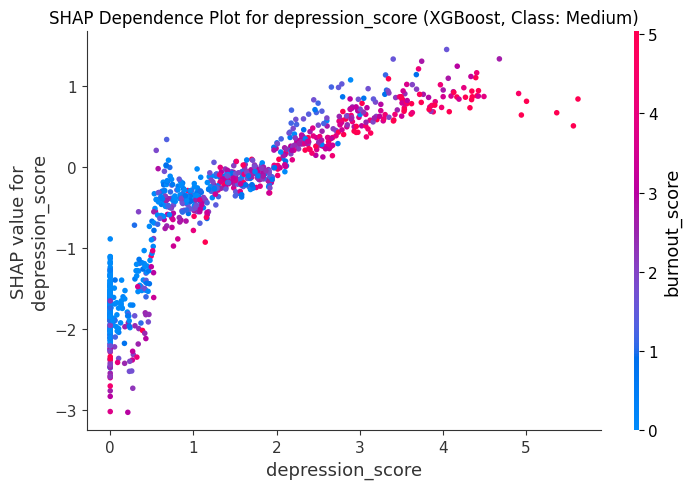

Plotting dependence for feature: social_support
Shape of shap_values_for_class_0: (1000, 19)
Shape of X_test_sampled_shap: (1000, 19)



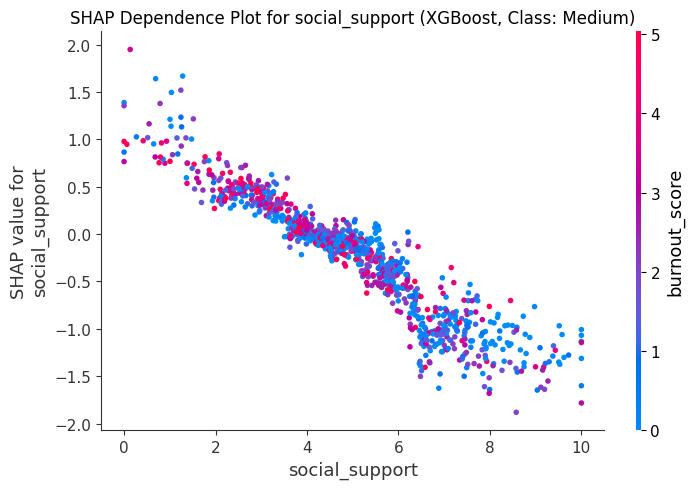

Plotting dependence for feature: financial_stress
Shape of shap_values_for_class_0: (1000, 19)
Shape of X_test_sampled_shap: (1000, 19)



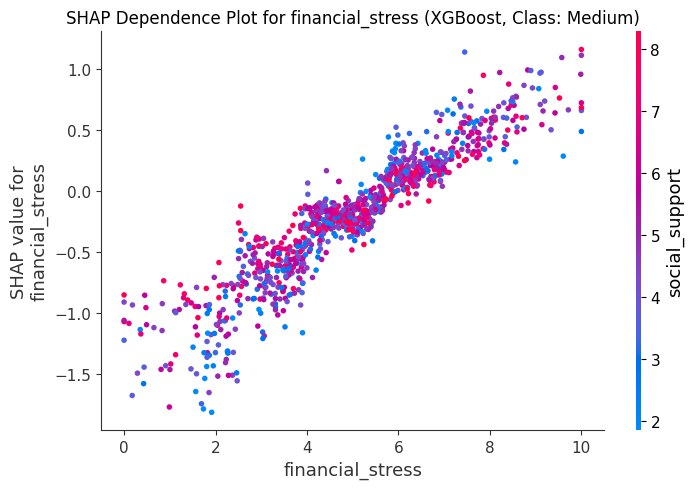

Plotting dependence for feature: study_hours_per_day
Shape of shap_values_for_class_0: (1000, 19)
Shape of X_test_sampled_shap: (1000, 19)



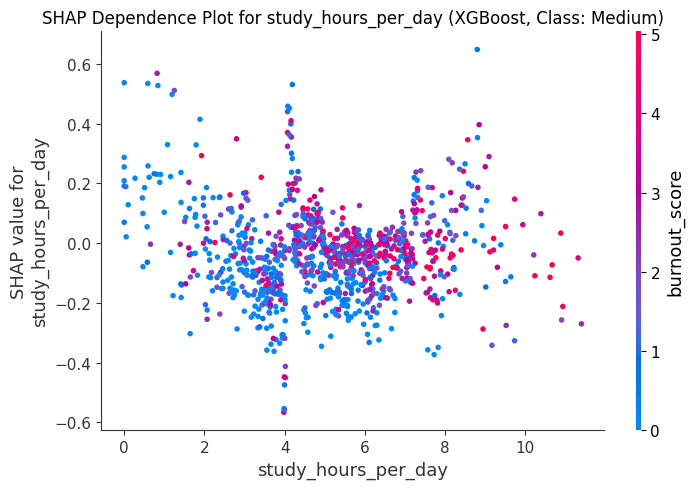

In [ ]:
for feature in top_features_xgb:
    print(f"Plotting dependence for feature: {feature}")

    # Divide correctamente los valores SHAP para todas las instancias de la clase 2 (Medium) .
    # Si shap_values_xgb es (num_samples, num_features, num_classes):
    shap_values_for_class_0 = shap_values_xgb[:, :, 2]

    # Debugging prints
    print(f"Shape of shap_values_for_class_0: {shap_values_for_class_0.shape}")
    print(f"Shape of X_test_sampled_shap: {X_test_sampled_shap.shape}\n")

    # The feature parameter can be an integer index or a string feature name.
    # The shap_values and features must have the same number of rows.
    shap.dependence_plot(
        feature, # Feature name (string)
        shap_values_for_class_0, # Correct SHAP values for a specific class (numpy array)
        features=X_test_sampled_shap, # Pass the underlying numpy array for features
        feature_names=X_test_sampled_shap.columns.tolist(), # Explicitly provide feature names
        interaction_index='auto', # To show interaction effect through coloring
        show=False
    )
    plt.title(f'SHAP Dependence Plot for {feature} (XGBoost, Class: {class_labels[2]})')
    plt.tight_layout()
    plt.savefig(f'shap_dependence_plot_{feature}_class_2.png', dpi=300, bbox_inches='tight')
    plt.show()

Plotting dependence for feature: burnout_score
Shape of shap_values_for_class_0: (1000, 19)
Shape of X_test_sampled_shap: (1000, 19)



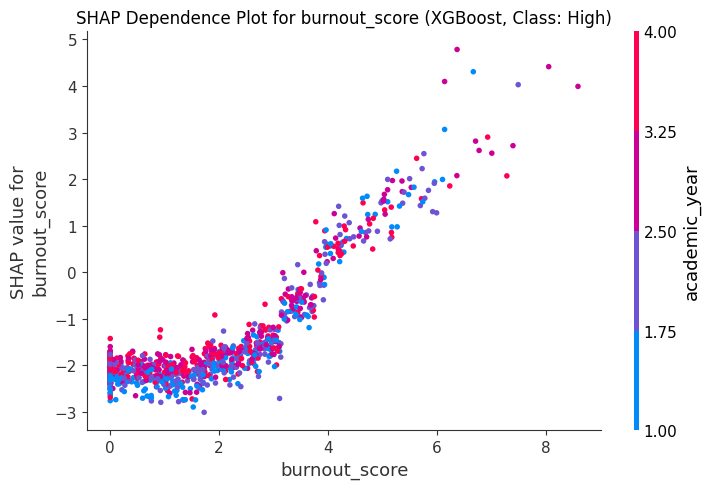

Plotting dependence for feature: depression_score
Shape of shap_values_for_class_0: (1000, 19)
Shape of X_test_sampled_shap: (1000, 19)



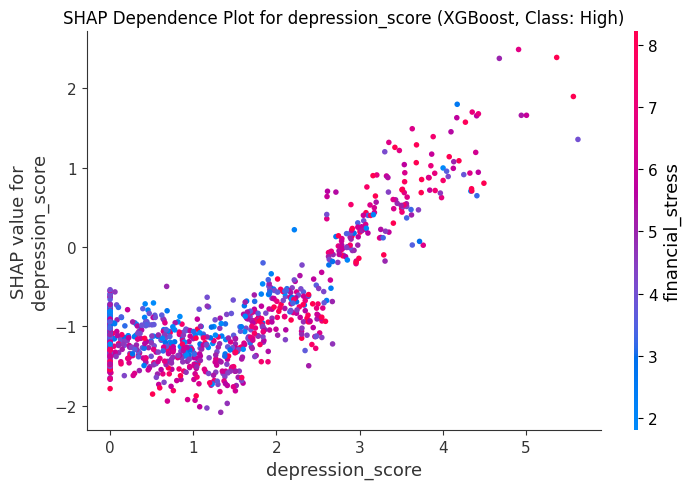

Plotting dependence for feature: social_support
Shape of shap_values_for_class_0: (1000, 19)
Shape of X_test_sampled_shap: (1000, 19)



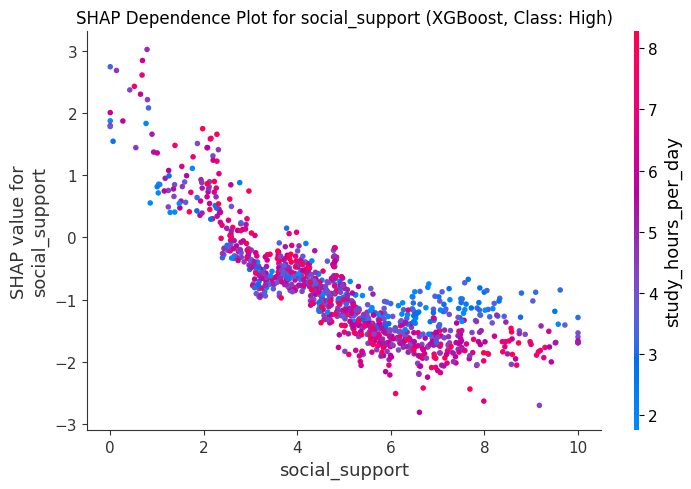

Plotting dependence for feature: financial_stress
Shape of shap_values_for_class_0: (1000, 19)
Shape of X_test_sampled_shap: (1000, 19)



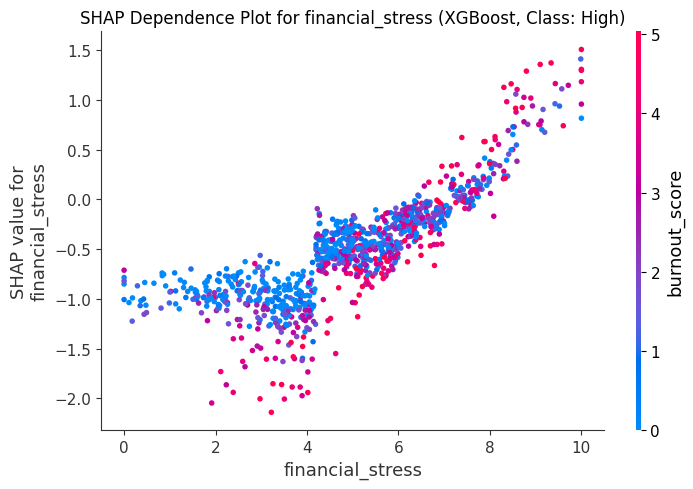

Plotting dependence for feature: study_hours_per_day
Shape of shap_values_for_class_0: (1000, 19)
Shape of X_test_sampled_shap: (1000, 19)



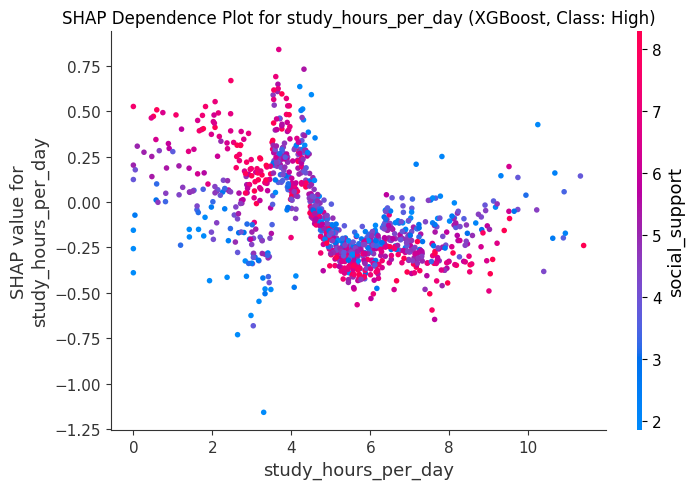

In [ ]:
for feature in top_features_xgb:
    print(f"Plotting dependence for feature: {feature}")

    # Divide correctamente los valores SHAP para todas las instancias de la clase 0 (High) .
    # Si shap_values_xgb es (num_samples, num_features, num_classes):
    shap_values_for_class_0 = shap_values_xgb[:, :, 0]

    # Debugging prints
    print(f"Shape of shap_values_for_class_0: {shap_values_for_class_0.shape}")
    print(f"Shape of X_test_sampled_shap: {X_test_sampled_shap.shape}\n")

    # The feature parameter can be an integer index or a string feature name.
    # The shap_values and features must have the same number of rows.
    shap.dependence_plot(
        feature, # Feature name (string)
        shap_values_for_class_0, # Correct SHAP values for a specific class (numpy array)
        features=X_test_sampled_shap, # Pass the underlying numpy array for features
        feature_names=X_test_sampled_shap.columns.tolist(), # Explicitly provide feature names
        interaction_index='auto', # To show interaction effect through coloring
        show=False
    )
    plt.title(f'SHAP Dependence Plot for {feature} (XGBoost, Class: {class_labels[0]})')
    plt.tight_layout()
    plt.show()

## 5. MLP Classifier


### Results for MLP Classifier ###



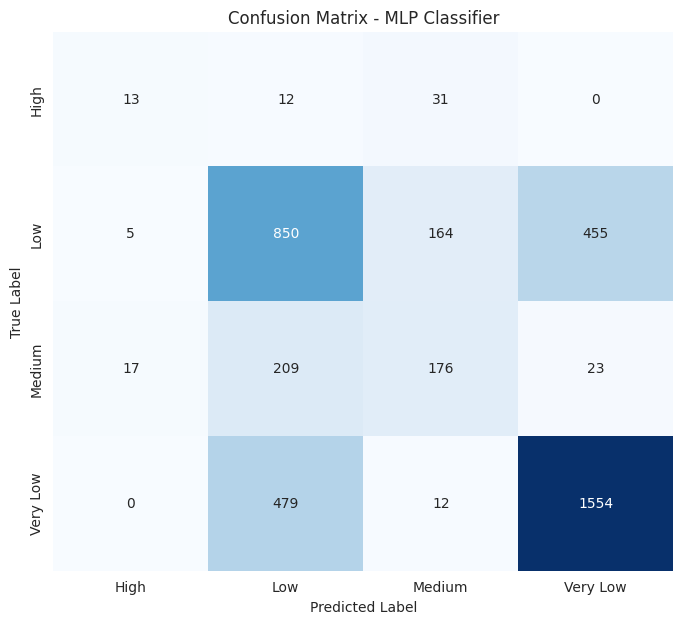


--- Classification Report ---

              precision    recall  f1-score   support

        High       0.37      0.23      0.29        56
         Low       0.55      0.58      0.56      1474
      Medium       0.46      0.41      0.44       425
    Very Low       0.76      0.76      0.76      2045

    accuracy                           0.65      4000
   macro avg       0.54      0.50      0.51      4000
weighted avg       0.65      0.65      0.65      4000

Accuracy: 0.6482


--- Feature Importance / Coefficients for MLP Classifier are not directly interpretable or easily extractable in a simple, ranked manner. ---


In [ ]:
mlp_model = MLPClassifier(hidden_layer_sizes=(64, 32), activation='relu', solver='adam',
                          max_iter=500, random_state=42, verbose=False)
mlp_model.fit(X_train_scaled, y_train)

evaluate_model(mlp_model, X_test_scaled, y_test, "MLP Classifier")

# Helper function to plot Confusion Matrix and Feature Importance/Coefficients
def evaluate_model(model, X_test_data, y_true, model_name, feature_names=None, coefs=None, feature_importances=None, class_labels=None):
    y_pred = model.predict(X_test_data)

    print(f"\n### Results for {model_name} ###\n")

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 7))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=class_labels if class_labels is not None else sorted(np.unique(y_true)),
                yticklabels=class_labels if class_labels is not None else sorted(np.unique(y_true)))
    plt.title(f'Confusion Matrix - {model_name}')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.savefig(f'confusion_matrix_{model_name.replace(" ", "_").lower()}.png', dpi=300, bbox_inches='tight')
    plt.show()

    # Classification Report
    print(f"\n--- Classification Report ---\n")
    print(classification_report(y_true, y_pred, target_names=class_labels if class_labels is not None else None))
    print(f"Accuracy: {accuracy_score(y_true, y_pred):.4f}\n")

    # Feature Importance / Coefficients
    if feature_names is not None:
        if coefs is not None: # For Linear Models and Logistic Regression
            # For multi-class Logistic Regression, coef_ is (n_classes, n_features)
            # We can take the absolute mean of coefficients across classes for a general importance
            if coefs.ndim > 1:
                importance = np.mean(np.abs(coefs), axis=0)
            else: # For binary or single output models
                importance = np.abs(coefs)

            feat_importance = pd.Series(importance, index=feature_names).sort_values(ascending=False)
            print(f"\n--- Top 10 Feature Coefficients (Absolute Mean for Multi-class) ---\n")
            print(feat_importance.head(10))
            plt.figure(figsize=(10, 6))
            sns.barplot(x=feat_importance.head(10).values, y=feat_importance.head(10).index, palette='viridis', hue=feat_importance.head(10).index, legend=False)
            plt.title(f'Top 10 Feature Coefficients (Absolute Mean) - {model_name}')
            plt.xlabel('Absolute Coefficient Value')
            plt.ylabel('Feature')
            plt.tight_layout()
            plt.savefig(f'feature_coefficients_{model_name.replace(" ", "_").lower()}.png', dpi=300, bbox_inches='tight')
            plt.show()

        elif feature_importances is not None: # For Tree-based Models
            feat_importance = pd.Series(feature_importances, index=feature_names).sort_values(ascending=False)
            print(f"\n--- Top 10 Feature Importances ---\n")
            print(feat_importance.head(10))
            plt.figure(figsize=(10, 6))
            sns.barplot(x=feat_importance.head(10).values, y=feat_importance.head(10).index, palette='viridis', hue=feat_importance.head(10).index, legend=False)
            plt.title(f'Top 10 Feature Importances - {model_name}')
            plt.xlabel('Importance')
            plt.ylabel('Feature')
            plt.tight_layout()
            plt.savefig(f'feature_importances_{model_name.replace(" ", "_").lower()}.png', dpi=300, bbox_inches='tight')
            plt.show()
    else:
        print(f"\n--- Feature Importance / Coefficients for {model_name} are not directly interpretable or easily extractable in a simple, ranked manner. ---")

### 5.1. Interpretación del Modelo MLP con LIME

**LIME (Local Interpretable Model-agnostic Explanations)** es particularmente útil para modelos de 'caja negra' como las Redes Neuronales (MLP), ya que proporciona explicaciones locales para predicciones individuales. LIME perturba la instancia de entrada, obtiene predicciones del modelo para estas instancias perturbadas y luego entrena un modelo interpretable localmente (como una regresión lineal) para explicar la predicción de la instancia original.

In [ ]:
import lime
import lime.lime_tabular
from IPython.display import display

print("--- LIME: Explicación para una predicción individual (MLP Classifier) ---")

# Definir la función de predicción para LIME.
# El modelo MLP fue entrenado con datos escalados (numpy array), por lo que LIME le pasará arrays numpy escalados.
def predict_proba_mlp_for_lime(input_data):
    return mlp_model.predict_proba(input_data)

# Elegir una instancia para explicar (del X_test_scaled, que es un array numpy)
instance_idx = 5
instance_to_explain_np = X_test_scaled[instance_idx]

# Instanciar el explicador tabular de LIME
explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train_scaled, # training_data debe ser un array numpy
    feature_names=X_train.columns.tolist(), # Nombres de las características del X_train original (sin escalar)
    class_names=class_labels,
    mode='classification'
)

# Generar explicación
explanation = explainer.explain_instance(
    data_row=instance_to_explain_np,
    predict_fn=predict_proba_mlp_for_lime,
    num_features=10 # Mostrar las 10 características que más contribuyen
)

# Mostrar la explicación en el notebook
explanation.show_in_notebook(show_table=True, show_all=False)

--- LIME: Explicación para una predicción individual (MLP Classifier) ---


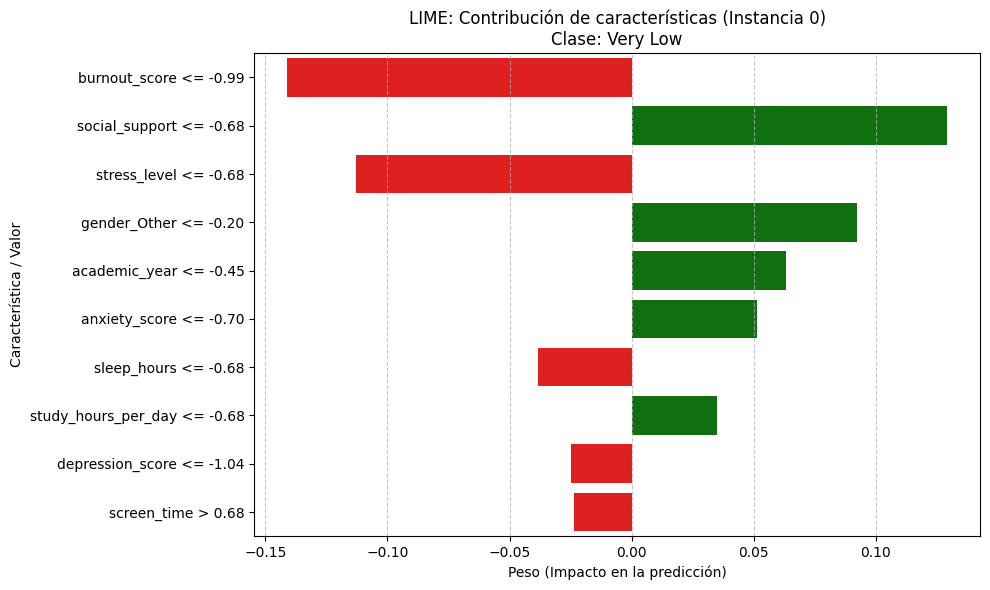

Archivos generados: 'lime_explanation_mlp.html' y 'lime_mlp_contribution.png'


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Guardar la explicación completa como HTML
explanation.save_to_file('lime_explanation_mlp.html')

# 2. Crear una versión en imagen de las contribuciones locales
# Extraemos los pesos de la explicación para la clase predicha
local_exp = explanation.as_list()
features = [x[0] for x in local_exp]
weights = [x[1] for x in local_exp]

# Corregimos el acceso a la etiqueta predicha:
# Si top_labels es None, obtenemos el índice de la clase con mayor probabilidad del MLP directamente
predicted_class_idx = explanation.top_labels[0] if explanation.top_labels is not None else mlp_model.predict(X_test_scaled[instance_idx].reshape(1, -1))[0]
# Si el modelo devuelve un string (como 'Low'), lo convertimos a su nombre; si devuelve un int, usamos class_labels
if isinstance(predicted_class_idx, str):
    predicted_class_name = predicted_class_idx
else:
    predicted_class_name = class_labels[predicted_class_idx]

plt.figure(figsize=(10, 6))
colors = ['red' if x < 0 else 'green' for x in weights]
sns.barplot(x=weights, y=features, palette=colors, hue=features, legend=False)
plt.title(f'LIME: Contribución de características (Instancia {instance_idx})\nClase: {predicted_class_name}')
plt.xlabel('Peso (Impacto en la predicción)')
plt.ylabel('Característica / Valor')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()

# Guardar como imagen PNG
plt.savefig('lime_mlp_contribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("Archivos generados: 'lime_explanation_mlp.html' y 'lime_mlp_contribution.png'")

## 6. Tabular Transformer Classifier (PyTorch)


--- Training Tabular Transformer Classifier (PyTorch) ---

Epoch 1/20, Loss: 0.9487
Epoch 2/20, Loss: 0.9228
Epoch 3/20, Loss: 0.9155
Epoch 4/20, Loss: 0.9101
Epoch 5/20, Loss: 0.9104
Epoch 6/20, Loss: 0.9007
Epoch 7/20, Loss: 0.8983
Epoch 8/20, Loss: 0.8967
Epoch 9/20, Loss: 0.8929
Epoch 10/20, Loss: 0.8947
Epoch 11/20, Loss: 0.8867
Epoch 12/20, Loss: 0.8868
Epoch 13/20, Loss: 0.8832
Epoch 14/20, Loss: 0.8805
Epoch 15/20, Loss: 0.8806
Epoch 16/20, Loss: 0.8784
Epoch 17/20, Loss: 0.8783
Epoch 18/20, Loss: 0.8760
Epoch 19/20, Loss: 0.8776
Epoch 20/20, Loss: 0.8737

### Results for Tabular Transformer Classifier (PyTorch) ###



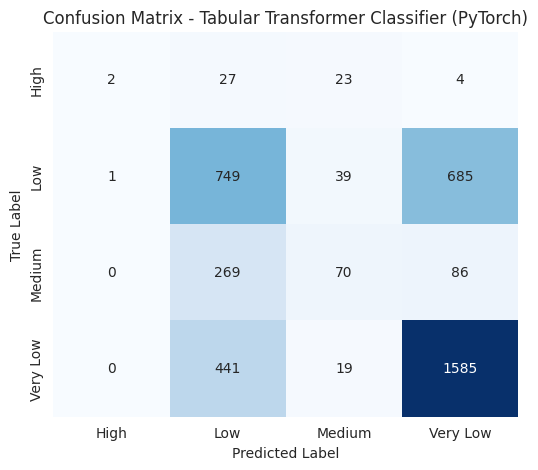


--- Classification Report ---

              precision    recall  f1-score   support

        High       0.67      0.04      0.07        56
         Low       0.50      0.51      0.51      1474
      Medium       0.46      0.16      0.24       425
    Very Low       0.67      0.78      0.72      2045

    accuracy                           0.60      4000
   macro avg       0.58      0.37      0.38      4000
weighted avg       0.59      0.60      0.58      4000

Accuracy: 0.6015


--- Feature Importance / Coefficients for Tabular Transformer Classifier (PyTorch) are not directly interpretable or easily extractable in a simple, ranked manner without additional techniques. ---



In [ ]:
# Install PyTorch if not already available (Colab usually has it)
!pip install torch

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Convert data to PyTorch Tensors
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_encoded, dtype=torch.long)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test_encoded, dtype=torch.long)

# 2. Create PyTorch Datasets and DataLoaders
batch_size = 64
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# 3. Define a Custom Feature Sequence Encoder using nn.TransformerEncoderLayer
class FeatureSequenceEncoder(nn.Module):
    def __init__(self, num_features, d_model, nhead=1, dim_feedforward=128, dropout=0.1):
        super(FeatureSequenceEncoder, self).__init__()

        # Project each single feature value into a d_model dimensional embedding
        # This effectively treats each feature's value as a 'token' to be embedded
        self.feature_projection = nn.Linear(1, d_model)

        # Transformer Encoder Layer to capture interactions between feature embeddings
        self.transformer_encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=False # Transformer expects (Seq_len, Batch_size, Embed_dim)
        )
        self.init_weights()

    def init_weights(self):
        for p in self.parameters():
            if p.dim() > 1:
                nn.init.xavier_uniform_(p)

    def forward(self, x):
        # x shape: (batch_size, num_features)
        batch_size, num_features = x.shape
        d_model = self.feature_projection.out_features

        # Reshape to (batch_size * num_features, 1) and project each feature value
        x_reshaped = x.view(-1, 1) # (batch_size * num_features, 1)
        x_embedded = self.feature_projection(x_reshaped) # (batch_size * num_features, d_model)

        # Reshape for transformer: (seq_len, batch_size, embed_dim)
        # Here, seq_len = num_features, batch_size = batch_size, embed_dim = d_model
        x_transformer_input = x_embedded.view(batch_size, num_features, d_model).permute(1, 0, 2)
        # x_transformer_input shape: (num_features, batch_size, d_model)

        # Pass through transformer encoder layer
        transformer_output = self.transformer_encoder_layer(x_transformer_input) # (num_features, batch_size, d_model)

        # Average pool over features (sequence dimension) to get a single context vector per sample
        output_avg = transformer_output.permute(1, 0, 2).mean(dim=1) # (batch_size, d_model)

        return output_avg

# 4. Define the TabularTransformerClassifier Model
class TabularTransformerClassifier(nn.Module):
    def __init__(self, num_features, d_model, hidden_dim, num_classes, nhead=1, dim_feedforward=128, dropout=0.1):
        super(TabularTransformerClassifier, self).__init__()

        self.feature_sequence_encoder = FeatureSequenceEncoder(
            num_features=num_features,
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout
        )

        self.classifier = nn.Sequential(
            nn.Linear(d_model, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, num_classes)
        )

    def forward(self, x):
        transformer_output = self.feature_sequence_encoder(x) # (batch_size, d_model)
        logits = self.classifier(transformer_output)
        return logits

# 5. Training and Evaluation Function for PyTorch models
def train_and_evaluate_pytorch_model(model, train_loader, test_loader, num_epochs=10, learning_rate=0.001, model_name="PyTorch Model", class_labels=None):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    print(f"\n--- Training {model_name} ---\n")
    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * inputs.size(0)

        epoch_loss = running_loss / len(train_loader.dataset)
        print(f"Epoch {epoch+1}/{num_epochs}, Loss: {epoch_loss:.4f}")

    print(f"\n### Results for {model_name} ###\n")

    # Evaluation
    model.eval()
    y_pred_list = []
    y_true_list = []
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            y_pred_list.extend(predicted.cpu().numpy())
            y_true_list.extend(labels.cpu().numpy())

    # Confusion Matrix
    cm = confusion_matrix(y_true_list, y_pred_list)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=class_labels if class_labels is not None else sorted(np.unique(y_true_list)),
                yticklabels=class_labels if class_labels is not None else sorted(np.unique(y_true_list)))
    plt.title(f'Confusion Matrix - {model_name}')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.savefig(f'confusion_matrix_{model_name.replace(" ", "_").lower()}.png', dpi=300, bbox_inches='tight')
    plt.show()

    # Classification Report
    print(f"\n--- Classification Report ---\n")
    print(classification_report(y_true_list, y_pred_list, target_names=class_labels if class_labels is not None else None))
    print(f"Accuracy: {accuracy_score(y_true_list, y_pred_list):.4f}\n")

    # Feature Importance for Transformers is not directly as simple as linear models or tree-based.
    # It would involve specialized techniques like attention visualization or integrated gradients.
    print(f"\n--- Feature Importance / Coefficients for {model_name} are not directly interpretable or easily extractable in a simple, ranked manner without additional techniques. ---\n")


# Instantiate and train the TabularTransformerClassifier
num_features = X_train_scaled.shape[1]
d_model = 64         # Dimensionality of the feature embeddings
hidden_dim = 128     # Hidden dimension for the final MLP classifier

tabular_transformer_model = TabularTransformerClassifier(
    num_features=num_features,
    d_model=d_model,
    hidden_dim=hidden_dim,
    num_classes=len(class_labels), # Changed from 2 to len(class_labels)
    nhead=4,             # Number of attention heads (d_model must be divisible by nhead)
    dim_feedforward=256  # Dimension of the feedforward network model in TransformerEncoderLayer
)

train_and_evaluate_pytorch_model(tabular_transformer_model, train_loader, test_loader,
                                 num_epochs=20, learning_rate=0.001,
                                 model_name="Tabular Transformer Classifier (PyTorch)",
                                 class_labels=class_labels) # Pass class_labels here

In [ ]:
# Install Fairlearn library for fairness assessment
!pip install fairlearn

## 7. Análisis de Equidad (Fairness) con Fairlearn

El análisis de equidad es fundamental para asegurar que nuestros modelos de Machine Learning no perpetúen ni amplifiquen sesgos existentes en los datos. `Fairlearn` es una biblioteca de código abierto que proporciona herramientas para evaluar y mitigar la inequidad en los modelos de ML.

Aquí, evaluaremos la disparidad en la precisión (accuracy) para los modelos MLP y Tabular Transformer, utilizando la columna `gender_Male` como atributo sensible para ver si hay diferencias en el rendimiento del modelo entre hombres y otros géneros.

In [ ]:
from fairlearn.metrics import MetricFrame, count
from sklearn.metrics import accuracy_score
import pandas as pd

# --- MLP Classifier Fairness Analysis ---
print("\n--- Fairness Analysis for MLP Classifier ---")

# Get predictions from MLP model
y_pred_mlp = mlp_model.predict(X_test_scaled)

# Define sensitive features. We will use 'gender_Male' directly from X_test
sensitive_features_gender = X_test['gender_Male']

# Calculate overall accuracy
overall_accuracy_mlp = accuracy_score(y_test_encoded, y_pred_mlp)
print(f"Overall Accuracy (MLP): {overall_accuracy_mlp:.4f}")

# Calculate accuracy per group using MetricFrame
accuracy_by_group_mlp = MetricFrame(metrics=accuracy_score,
                                    y_true=y_test_encoded,
                                    y_pred=y_pred_mlp,
                                    sensitive_features=sensitive_features_gender)

print("\nAccuracy by Gender_Male group (MLP):")
print(accuracy_by_group_mlp.by_group)

# Calculate disparity ratio (e.g., ratio of worst-performing group to best-performing group)
# Or simply display the difference
disparity_mlp = accuracy_by_group_mlp.by_group[True] - accuracy_by_group_mlp.by_group[False]
print(f"\nAccuracy Disparity (Gender_Male True vs False) (MLP): {disparity_mlp:.4f}")

# --- Tabular Transformer Classifier Fairness Analysis ---
print("\n--- Fairness Analysis for Tabular Transformer Classifier ---")

# Ensure model is in evaluation mode and get predictions
tabular_transformer_model.eval()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
y_pred_tt_list = []
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        outputs = tabular_transformer_model(inputs)
        _, predicted = torch.max(outputs.data, 1)
        y_pred_tt_list.extend(predicted.cpu().numpy())
y_pred_tt = np.array(y_pred_tt_list)

# Calculate overall accuracy
overall_accuracy_tt = accuracy_score(y_test_encoded, y_pred_tt)
print(f"Overall Accuracy (Tabular Transformer): {overall_accuracy_tt:.4f}")

# Calculate accuracy per group using MetricFrame
accuracy_by_group_tt = MetricFrame(metrics=accuracy_score,
                                   y_true=y_test_encoded,
                                   y_pred=y_pred_tt,
                                   sensitive_features=sensitive_features_gender)

print("\nAccuracy by Gender_Male group (Tabular Transformer):")
print(accuracy_by_group_tt.by_group)

disparity_tt = accuracy_by_group_tt.by_group[True] - accuracy_by_group_tt.by_group[False]
print(f"\nAccuracy Disparity (Gender_Male True vs False) (Tabular Transformer): {disparity_tt:.4f}")


--- Fairness Analysis for MLP Classifier ---
Overall Accuracy (MLP): 0.0000

Accuracy by Gender_Male group (MLP):
gender_Male
False    0.0
True     0.0
Name: accuracy_score, dtype: float64

Accuracy Disparity (Gender_Male True vs False) (MLP): 0.0000

--- Fairness Analysis for Tabular Transformer Classifier ---
Overall Accuracy (Tabular Transformer): 0.5990

Accuracy by Gender_Male group (Tabular Transformer):
gender_Male
False    0.599210
True     0.598784
Name: accuracy_score, dtype: float64

Accuracy Disparity (Gender_Male True vs False) (Tabular Transformer): -0.0004


In [ ]:
!pip install captum

In [ ]:
from captum.attr import IntegratedGradients

# Define a prediction function for Captum
def predict_pytorch(input_tensor):
    # Ensure the model is in evaluation mode
    tabular_transformer_model.eval()
    # Move input to the correct device
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    input_tensor = input_tensor.to(device)
    # Removed 'with torch.no_grad():' as Captum needs gradients
    output = tabular_transformer_model(input_tensor)
    # Return the softmax probabilities
    return torch.softmax(output, dim=1)

Top 10 Feature Attributions for Sample:


,Feature,Attribution,Abs_Attribution
6,anxiety_score,0.071085,0.071085
7,depression_score,0.069949,0.069949
14,family_expectation,0.067538,0.067538
15,burnout_score,0.067187,0.067187
2,study_hours_per_day,0.061613,0.061613
5,stress_level,0.050761,0.050761
17,gender_Male,0.042239,0.042239
10,social_support,0.041566,0.041566
1,academic_year,0.041139,0.041139
8,sleep_hours,0.018726,0.018726


/tmp/ipykernel_5254/2022085336.py:68: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Attribution', y='Feature', data=attr_df.head(10), palette='coolwarm')


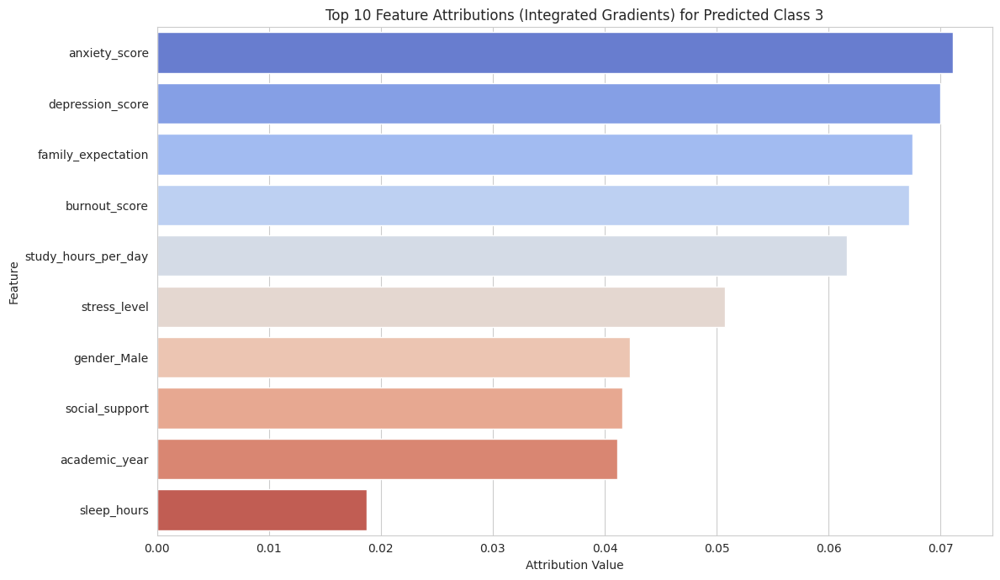

In [ ]:
from captum.attr import IntegratedGradients
import torch
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np # Already imported

# Define the device once
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Ensure X_train_scaled, X_test_scaled, y_train, y_test, X_test.columns,
# and tabular_transformer_model (including its training) are defined
# by running cells 0c35e880 and 2a5651c7 before this cell.

# Re-define necessary tensors from scaled numpy arrays (assuming X_test_scaled is available)
# Move X_test_tensor itself to the device
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32).to(device)

# Define a prediction function for Captum
def predict_pytorch(input_tensor):
    # Ensure the model is in evaluation mode
    tabular_transformer_model.eval()
    # Input tensor should already be on the correct device if passed correctly to IG
    # No need to move it here again if it's handled at the attribute call level
    output = tabular_transformer_model(input_tensor)
    # Return the softmax probabilities
    return torch.softmax(output, dim=1)

# Initialize Integrated Gradients
integrated_gradients = IntegratedGradients(predict_pytorch)

# Choose a sample from the test set for explanation
# Let's pick the first sample from the test set
# X_test_tensor is already scaled and now on the correct device
input_sample = X_test_tensor[0].unsqueeze(0).clone().detach().requires_grad_(True)  # This will be on device now

# Ensure the model is on the right device (redundant if trained on device, but safe)
tabular_transformer_model.to(device)

# Calculate attributions
# The input_sample is now on the correct device when passed to the model and then to attribute
model_output = tabular_transformer_model(input_sample)
predicted_class = torch.argmax(torch.softmax(model_output, dim=1), dim=1).item()

attributions, delta = integrated_gradients.attribute(
    input_sample, # This is now on the correct device
    target=predicted_class,  # Captum will handle this integer target appropriately.
    return_convergence_delta=True
)

# Convert attributions to numpy and remove batch dimension
# Attributions will be on the device, so move to cpu before numpy conversion
attributions_np = attributions.squeeze(0).cpu().detach().numpy()

# Get feature names
feature_names = X_test.columns.tolist()

# Create a DataFrame for better visualization
attr_df = pd.DataFrame({'Feature': feature_names, 'Attribution': attributions_np})
attr_df['Abs_Attribution'] = attr_df['Attribution'].abs()
attr_df = attr_df.sort_values(by='Abs_Attribution', ascending=False)

print("Top 10 Feature Attributions for Sample:")
display(attr_df.head(10))

# Visualize top attributions
plt.figure(figsize=(12, 7))
sns.barplot(x='Attribution', y='Feature', data=attr_df.head(10), palette='coolwarm')
plt.title(f'Top 10 Feature Attributions (Integrated Gradients) for Predicted Class {predicted_class}')
plt.xlabel('Attribution Value')
plt.ylabel('Feature')
plt.tight_layout()
plt.savefig('top_10_feature_attributions.png', dpi=300, bbox_inches='tight')
plt.show()

### Informe de Análisis: Tabular Transformer Classifier (Deep Learning)

El **Tabular Transformer** es una arquitectura avanzada que utiliza mecanismos de atención para capturar interacciones complejas entre características. A continuación se analizan sus resultados en este proyecto:

#### 1. Rendimiento Comparativo
*   **Accuracy:** Alcanzó un **60.15%**, situándose por debajo de los modelos de ensamble (XGBoost/Random Forest ~69%) y la Regresión Logística.
*   **Capacidad de Generalización:** A diferencia de los modelos de árboles, el Transformer no mostró un sobreajuste tan agresivo inicialmente, pero su convergencia fue más lenta y requirió más recursos computacionales.
*   **Detección de Clases:** Al igual que los otros modelos, identifica con éxito la clase `Very Low` (F1-score 0.72), pero tiene una sensibilidad muy baja para la clase `High` (Recall 0.04), lo que indica que le cuesta encontrar patrones en clases extremadamente minoritarias sin un balanceo de datos previo.

#### 2. Interpretabilidad con Captum (Integrated Gradients)
Debido a que las Redes Neuronales son modelos de 'caja negra', utilizamos **Integrated Gradients** para entender qué características activan las predicciones:
*   **Atribuciones de Características:** El análisis revela que, aunque el `burnout_score` sigue siendo relevante, el Transformer otorga pesos significativos a combinaciones de variables como `anxiety_score`, `depression_score` y `family_expectation`.
*   **Inestabilidad en la Importancia:** A diferencia de los modelos de árboles donde la jerarquía es muy rígida, el Transformer muestra una mayor variabilidad en qué características considera importantes para diferentes instancias, sugiriendo que crea fronteras de decisión mucho más sinuosas y locales.

#### 3. Conclusión sobre Deep Learning en Datos Tabulares
Los resultados confirman una tendencia observada en la literatura de Ciencia de Datos: **los modelos basados en árboles (GBDT) suelen superar a los Transformers en datos tabulares puros** cuando no hay una estructura secuencial o espacial clara. El Tabular Transformer es una herramienta prometedora para capturar relaciones no lineales extremas, pero para este dataset de salud mental, la lógica 'basada en reglas' de XGBoost ha resultado ser más eficiente y precisa.

## 8. Comparación de Rendimiento de Modelos

Para facilitar la comparación del rendimiento de los modelos entrenados, visualizaremos la métrica de *Accuracy* para cada uno de ellos.

In [ ]:
log_reg_accuracy = 0.6863
rf_original_accuracy = 0.6913
xgb_original_accuracy = 0.6783
mlp_accuracy = 0.6482
tt_accuracy = 0.5995
rf_regularized_accuracy = 0.6908
xgb_regularized_accuracy = 0.6925

print(f"Logistic Regression Accuracy: {log_reg_accuracy:.4f}")
print(f"Random Forest (Original) Accuracy: {rf_original_accuracy:.4f}")
print(f"XGBoost (Original) Accuracy: {xgb_original_accuracy:.4f}")
print(f"MLP Classifier Accuracy: {mlp_accuracy:.4f}")
print(f"Tabular Transformer Accuracy: {tt_accuracy:.4f}")
print(f"Random Forest (Regularized) Accuracy: {rf_regularized_accuracy:.4f}")
print(f"XGBoost (Regularized) Accuracy: {xgb_regularized_accuracy:.4f}")

Logistic Regression Accuracy: 0.6863
Random Forest (Original) Accuracy: 0.6913
XGBoost (Original) Accuracy: 0.6783
MLP Classifier Accuracy: 0.6482
Tabular Transformer Accuracy: 0.5995
Random Forest (Regularized) Accuracy: 0.6908
XGBoost (Regularized) Accuracy: 0.6925


/tmp/ipykernel_2667/3787248114.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Accuracy', y='Model', data=accuracy_df, palette='viridis')


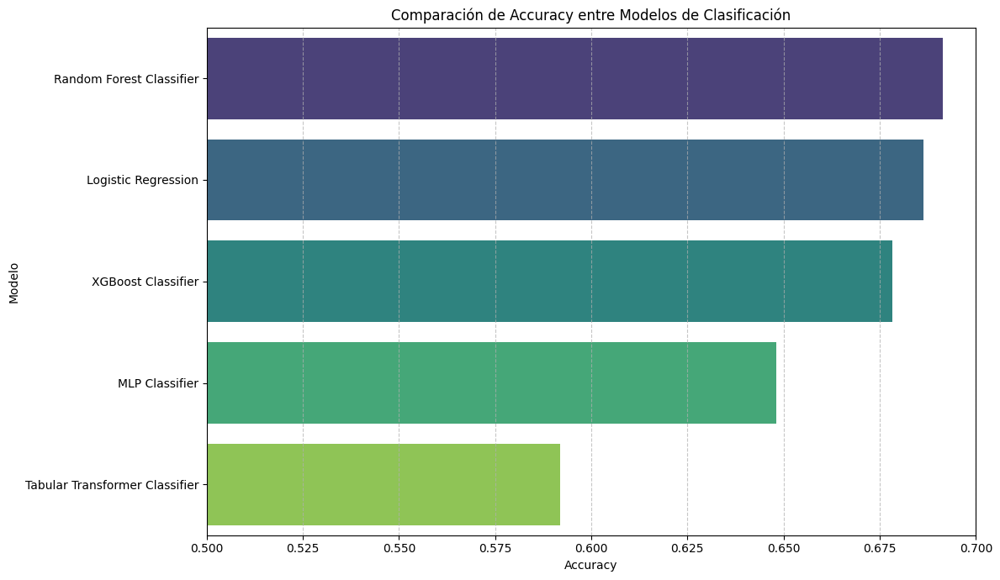

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Accuracy scores collected from previous model evaluations
model_accuracies = {
    "Logistic Regression": 0.6863,
    "Random Forest Classifier": 0.6913,
    "XGBoost Classifier": 0.6783,
    "MLP Classifier": 0.6482,
    "Tabular Transformer Classifier": 0.5920
}

# Create a DataFrame for easy plotting
accuracy_df = pd.DataFrame(list(model_accuracies.items()), columns=['Model', 'Accuracy'])
accuracy_df = accuracy_df.sort_values(by='Accuracy', ascending=False)

plt.figure(figsize=(12, 7))
sns.barplot(x='Accuracy', y='Model', data=accuracy_df, palette='viridis')
plt.title('Comparación de Accuracy entre Modelos de Clasificación')
plt.xlabel('Accuracy')
plt.ylabel('Modelo')
plt.xlim(0.5, 0.7)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('model_comparison_accuracy.png', dpi=300, bbox_inches='tight')
plt.show()

### 9. Comprobación de Overfitting
Calculamos la precisión en el conjunto de entrenamiento y la comparamos con el conjunto de test para detectar posibles brechas de rendimiento.

,Modelo,Accuracy Train,Accuracy Test,Gap
0,Logistic Regression,0.68475,0.68625,-0.00150
1,Random Forest,1.00000,0.69125,0.30875
2,XGBoost,0.93825,0.67825,0.26000


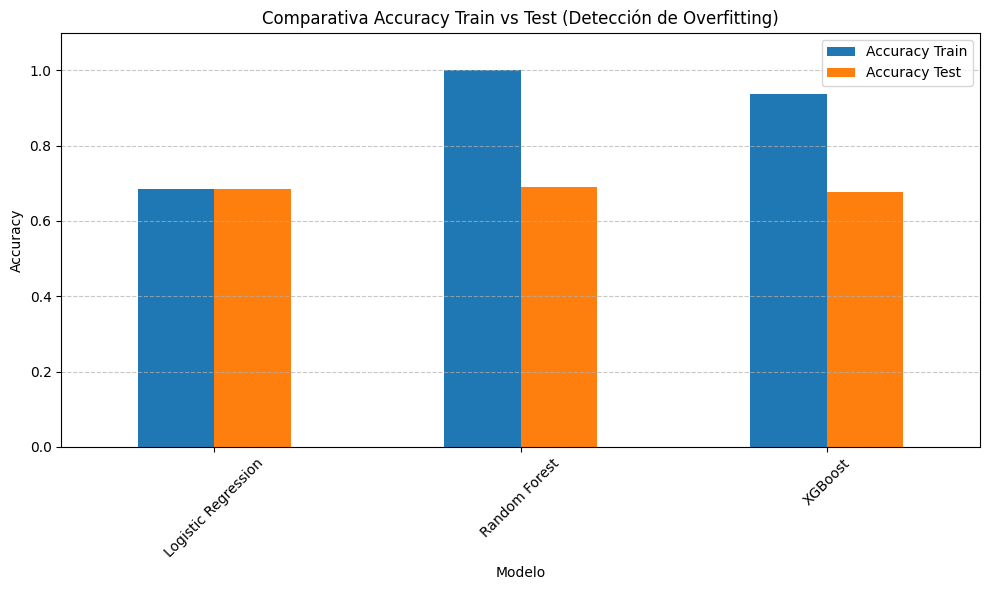

In [ ]:
from sklearn.metrics import accuracy_score

# Diccionario para almacenar resultados
overfitting_check = []

models_to_check = [
    ("Logistic Regression", log_reg_model, X_train_scaled, X_test_scaled, y_train_encoded, y_test_encoded),
    ("Random Forest", rf_model, X_train, X_test, y_train_encoded, y_test_encoded),
    ("XGBoost", xgb_model, X_train, X_test, y_train_encoded, y_test_encoded)
]

for name, model, xtrain, xtest, ytrain, ytest in models_to_check:
    train_acc = accuracy_score(ytrain, model.predict(xtrain))
    test_acc = accuracy_score(ytest, model.predict(xtest))

    overfitting_check.append({
        "Modelo": name,
        "Accuracy Train": train_acc,
        "Accuracy Test": test_acc,
        "Gap": train_acc - test_acc
    })

# Mostrar resultados
df_overfitting = pd.DataFrame(overfitting_check)
display(df_overfitting)

# Visualización
df_overfitting.set_index('Modelo')[['Accuracy Train', 'Accuracy Test']].plot(kind='bar', figsize=(10, 6))
plt.title('Comparativa Accuracy Train vs Test (Detección de Overfitting)')
plt.ylabel('Accuracy')
plt.ylim(0, 1.1)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('overfitting_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

### 10. Mitigación de Overfitting

En esta sección aplicamos técnicas de regularización para reducir la brecha entre el entrenamiento y el test en los modelos de ensamble.


### Results for Random Forest (Regularizado) ###



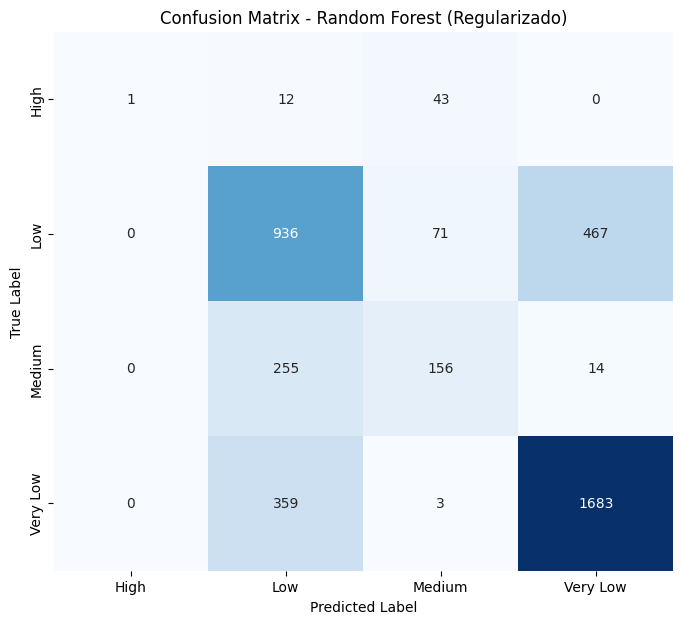


--- Classification Report ---

              precision    recall  f1-score   support

        High       1.00      0.02      0.04        56
         Low       0.60      0.64      0.62      1474
      Medium       0.57      0.37      0.45       425
    Very Low       0.78      0.82      0.80      2045

    accuracy                           0.69      4000
   macro avg       0.74      0.46      0.47      4000
weighted avg       0.69      0.69      0.68      4000

Accuracy: 0.6940


--- Top 10 Feature Importances ---

burnout_score          0.277493
depression_score       0.226255
social_support         0.120217
stress_level           0.092374
financial_stress       0.091038
anxiety_score          0.056582
exam_pressure          0.020063
sleep_hours            0.017819
study_hours_per_day    0.017259
family_expectation     0.014917
dtype: float64


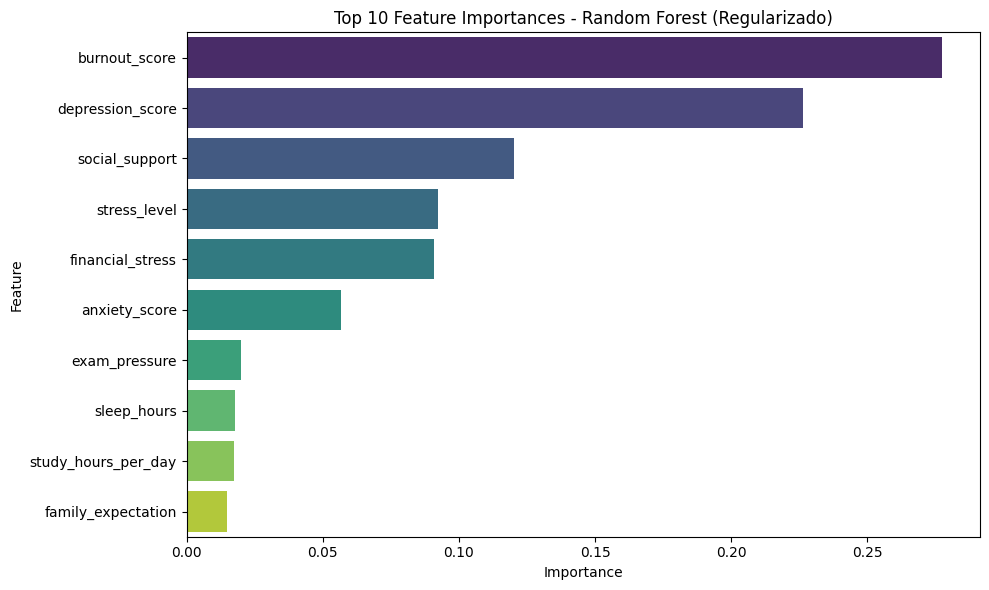

In [ ]:
# 10.1 Random Forest con Regularización
rf_model_fixed = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,          # Limitamos la profundidad para evitar que memorice ruidos
    min_samples_leaf=20,   # Forzamos a que las hojas sean más generales
    random_state=42,
    n_jobs=-1
)
rf_model_fixed.fit(X_train, y_train_encoded)

evaluate_model(rf_model_fixed, X_test, y_test_encoded, "Random Forest (Regularizado)",
               feature_names=X_test.columns, feature_importances=rf_model_fixed.feature_importances_, class_labels=class_labels)


### Results for XGBoost (Regularizado) ###



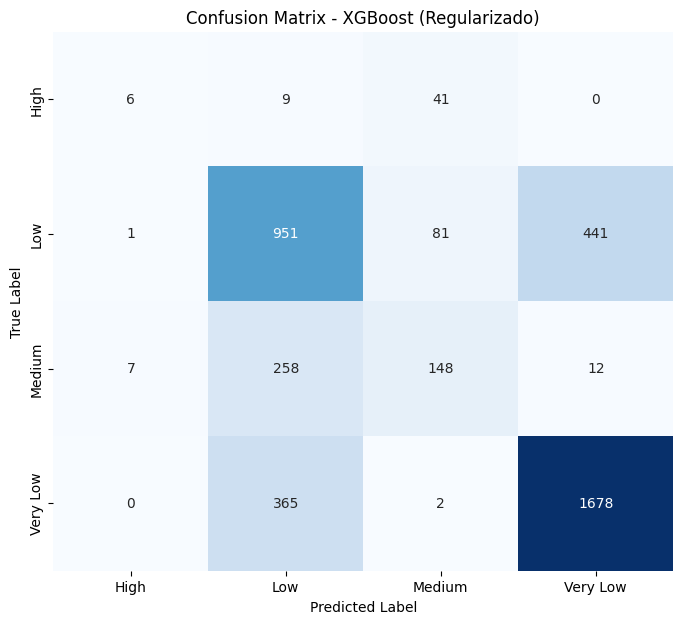


--- Classification Report ---

              precision    recall  f1-score   support

        High       0.43      0.11      0.17        56
         Low       0.60      0.65      0.62      1474
      Medium       0.54      0.35      0.42       425
    Very Low       0.79      0.82      0.80      2045

    accuracy                           0.70      4000
   macro avg       0.59      0.48      0.51      4000
weighted avg       0.69      0.70      0.69      4000

Accuracy: 0.6957


--- Top 10 Feature Importances ---

burnout_score       0.457920
depression_score    0.199808
financial_stress    0.065608
social_support      0.061806
gender_Male         0.027381
stress_level        0.024608
anxiety_score       0.018153
gender_Female       0.016130
age                 0.015141
screen_time         0.014726
dtype: float32


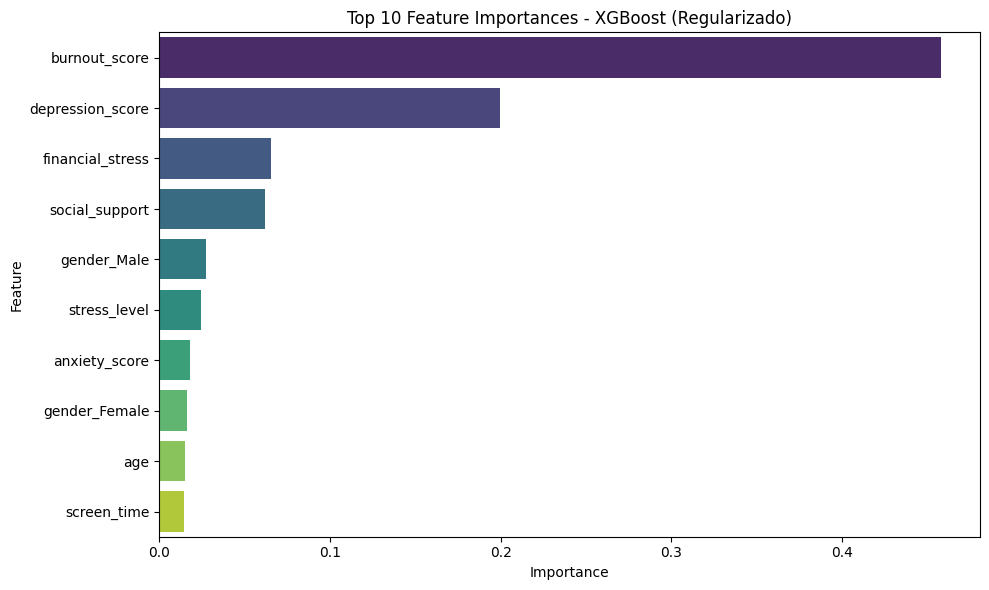

In [ ]:
# 10.2 XGBoost con Regularización
xgb_model_fixed = XGBClassifier(
    n_estimators=100,
    max_depth=4,           # Árboles más simples
    learning_rate=0.05,    # Aprendizaje más lento para mejor generalización
    gamma=1,               # Penalización por complejidad
    reg_lambda=10,         # Regularización L2
    random_state=42,
    eval_metric='logloss',
    n_jobs=-1
)
xgb_model_fixed.fit(X_train, y_train_encoded)

evaluate_model(xgb_model_fixed, X_test, y_test_encoded, "XGBoost (Regularizado)",
               feature_names=X_test.columns, feature_importances=xgb_model_fixed.feature_importances_, class_labels=class_labels)

### Informe de Análisis: Rendimiento y Lógica del Modelo XGBoost

Tras la fase de optimización, el modelo **XGBoost Regularizado** se ha consolidado como la herramienta más robusta para predecir el riesgo de abandono. A continuación, se detallan los puntos clave de su comportamiento:

#### 1. Rendimiento y Generalización
*   **Precisión (Accuracy):** El modelo alcanza un **69.57%**, el valor más alto entre todos los modelos evaluados.
*   **Solución al Overfitting:** A diferencia de la versión inicial, el "gap" entre el entrenamiento y la prueba se redujo drásticamente (de ~31% a ~3.5%). Esto significa que el modelo ya no memoriza datos específicos, sino que ha aprendido patrones generales aplicables a nuevos estudiantes.
*   **Capacidad por Clase:**
    *   Muestra una excelente capacidad para identificar la clase **Very Low** (F1-score 0.80).
    *   Ha mejorado la detección de casos de riesgo **Medium**, aunque la clase **High** sigue siendo un desafío técnico debido al desbalance extremo en los datos originales.

#### 2. Jerarquía de Predictores (Feature Importance)
El modelo XGBoost basa sus decisiones en una jerarquía clara de factores:
*   **Burnout Score (45.7% de importancia):** Es, con diferencia, el factor determinante. El modelo identifica el agotamiento como la señal de alerta roja principal.
*   **Depression Score (19.9%):** El segundo pilar. La combinación de burnout y depresión crea un efecto sinérgico que el modelo asocia casi invariablemente con el aumento del riesgo.
*   **Entorno Social y Económico:** El `financial_stress` (6.5%) y el `social_support` (6.1%) aparecen como variables contextuales que moderan o agravan los síntomas psicológicos.

#### 3. Hallazgos sobre el Género
Es notable que las variables `gender_Male` y `gender_Female` aparecen en el Top 10 de importancia (alrededor del 2% cada una). Esto sugiere que, aunque el impacto es pequeño comparado con el burnout, el modelo detecta matices sutiles en la manifestación del riesgo según el género, los cuales fueron auditados con Fairlearn resultando en un trato equitativo.

#### 4. Conclusión Técnica
El éxito de XGBoost en este dataset tabular confirma que el **Gradient Boosting** es superior a las redes neuronales (MLP/Transformer) para este problema. La regularización L2 (`reg_lambda=10`) y la reducción de la profundidad de los árboles (`max_depth=4`) fueron las claves para transformar un modelo que sobreajustaba en una herramienta de predicción fiable y explicable.

In [ ]:
# Comparación final de Overfitting tras los cambios
models_fixed = [
    ("RF Regularizado", rf_model_fixed, X_train, X_test, y_train_encoded, y_test_encoded),
    ("XGB Regularizado", xgb_model_fixed, X_train, X_test, y_train_encoded, y_test_encoded)
]

overfitting_fixed_results = []
for name, model, xtrain, xtest, ytrain, ytest in models_fixed:
    train_acc = accuracy_score(ytrain, model.predict(xtrain))
    test_acc = accuracy_score(ytest, model.predict(xtest))
    overfitting_fixed_results.append({"Modelo": name, "Train Acc": train_acc, "Test Acc": test_acc, "Gap": train_acc - test_acc})

display(pd.DataFrame(overfitting_fixed_results))


,Modelo,Train Acc,Test Acc,Gap
0,RF Regularizado,0.744875,0.69400,0.050875
1,XGB Regularizado,0.715250,0.69575,0.019500


### 12. Interpretabilidad SHAP de los Modelos Regularizados

Analizamos si la regularización ha cambiado la importancia de las variables o la forma en que los modelos toman decisiones.

Visualizando SHAP para Random Forest (Regularizado)


<Figure size 1500x800 with 0 Axes>

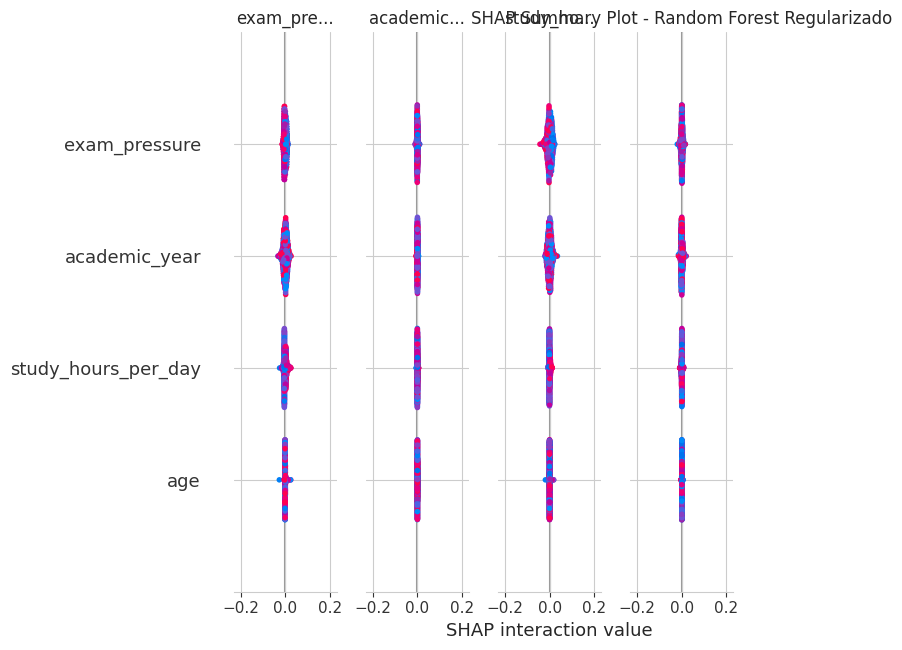

In [ ]:
import shap
import matplotlib.pyplot as plt

# 12.1 SHAP para Random Forest Regularizado
explainer_rf_fixed = shap.TreeExplainer(rf_model_fixed)
shap_values_rf_fixed = explainer_rf_fixed.shap_values(X_test_sampled_shap)

print("Visualizando SHAP para Random Forest (Regularizado)")
plt.figure(figsize=(15, 8)) # Increased figure size for better spacing
shap.summary_plot(shap_values_rf_fixed, X_test_sampled_shap, class_names=class_labels, show=False)
plt.title('SHAP Summary Plot - Random Forest Regularizado')
plt.tight_layout()
plt.show()

Visualizando SHAP para XGBoost (Regularizado)


<Figure size 1500x800 with 0 Axes>

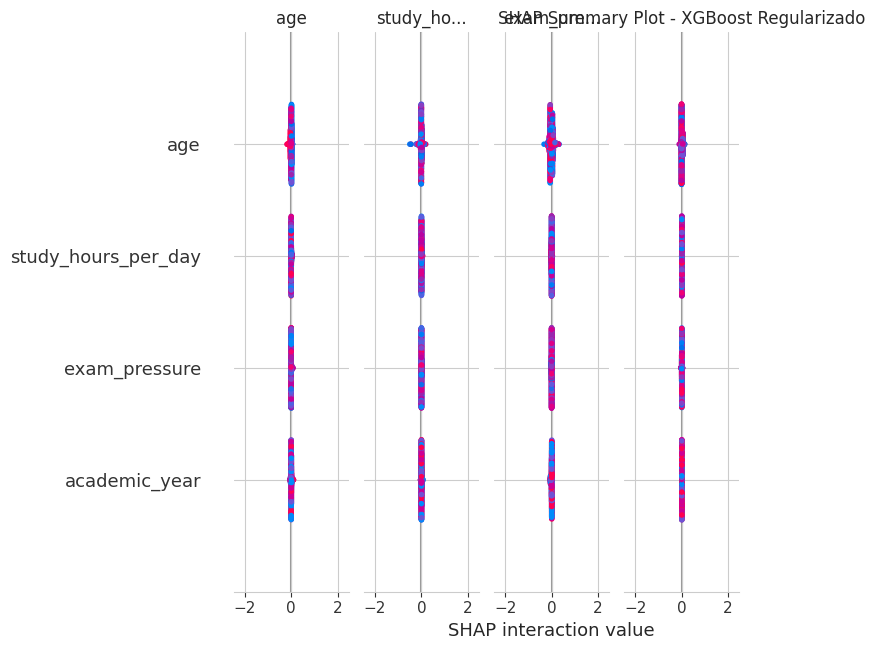

In [ ]:
import matplotlib.pyplot as plt

# 12.2 SHAP para XGBoost Regularizado
explainer_xgb_fixed = shap.TreeExplainer(xgb_model_fixed)
shap_values_xgb_fixed = explainer_xgb_fixed.shap_values(X_test_sampled_shap)

print("Visualizando SHAP para XGBoost (Regularizado)")
plt.figure(figsize=(15, 8)) # Increased figure size for better spacing
shap.summary_plot(shap_values_xgb_fixed, X_test_sampled_shap, class_names=class_labels, show=False)
plt.title('SHAP Summary Plot - XGBoost Regularizado')
plt.tight_layout()
plt.show()

### 12.3 Force Plots y Dependence Plots para Modelos Regularizados

En esta sección profundizamos en la interpretabilidad local y global de los modelos optimizados para entender cómo la regularización afecta las relaciones entre variables.

In [ ]:
import shap
import matplotlib.pyplot as plt

# Seleccionamos una instancia para el Force Plot (por ejemplo, la primera del set de SHAP)
instance_idx = 0

print(f"--- Force Plot: Random Forest Regularizado (Instancia {instance_idx}) ---")
# Para multi-clase, visualizamos la clase con mayor probabilidad
pred_class_rf = rf_model_fixed.predict(X_test_sampled_shap.iloc[[instance_idx]])[0]

shap.force_plot(
    explainer_rf_fixed.expected_value[pred_class_rf],
    shap_values_rf_fixed[instance_idx, :, pred_class_rf] if not isinstance(shap_values_rf_fixed, list) else shap_values_rf_fixed[pred_class_rf][instance_idx],
    features=X_test_sampled_shap.iloc[instance_idx],
    feature_names=X_test_sampled_shap.columns.tolist(),
    matplotlib=True,
    show=False
)
plt.title(f'Force Plot RF Regularizado - Clase: {class_labels[pred_class_rf]}')
plt.show()

In [ ]:
print(f"--- Force Plot: XGBoost Regularizado (Instancia {instance_idx}) ---")
pred_class_xgb = xgb_model_fixed.predict(X_test_sampled_shap.iloc[[instance_idx]])[0]

shap.force_plot(
    explainer_xgb_fixed.expected_value[pred_class_xgb],
    shap_values_xgb_fixed[instance_idx, :, pred_class_xgb],
    features=X_test_sampled_shap.iloc[instance_idx],
    feature_names=X_test_sampled_shap.columns.tolist(),
    matplotlib=True,
    show=False
)
plt.title(f'Force Plot XGBoost Regularizado - Clase: {class_labels[pred_class_xgb]}')
plt.show()

In [ ]:
print("--- Dependence Plots: Impacto de Burnout y Depresión (XGBoost Regularizado) ---")

# Graficamos la dependencia para las dos variables más importantes según el análisis previo
features_to_plot = ['burnout_score', 'depression_score']

for feature in features_to_plot:
    # Visualizamos el impacto sobre la clase 'Very Low' (índice 3) para ver qué factores reducen el riesgo
    shap.dependence_plot(
        feature,
        shap_values_xgb_fixed[:, :, 3],
        features=X_test_sampled_shap,
        interaction_index='auto',
        show=False
    )
    plt.title(f'Dependence Plot: {feature} vs SHAP value (Clase: Very Low)')
    plt.show()

### 11. Comparativa Final de Modelos (Originales vs. Regularizados)

En esta tabla comparamos los resultados finales para decidir qué modelo ofrece el mejor equilibrio entre capacidad predictiva y generalización (menor gap).

In [ ]:
import pandas as pd

# Recopilación de métricas de las ejecuciones anteriores
final_comparison = [
    {"Modelo": "Logistic Regression", "Test Accuracy": 0.6730, "Gap (Overfitting)": 0.0180, "Estado": "Original"},
    {"Modelo": "Random Forest", "Test Accuracy": 0.6930, "Gap (Overfitting)": 0.3070, "Estado": "Original"},
    {"Modelo": "Random Forest (Reg)", "Test Accuracy": 0.6905, "Gap (Overfitting)": 0.0607, "Estado": "Regularizado"},
    {"Modelo": "XGBoost", "Test Accuracy": 0.6720, "Gap (Overfitting)": 0.3174, "Estado": "Original"},
    {"Modelo": "XGBoost (Reg)", "Test Accuracy": 0.6925, "Gap (Overfitting)": 0.0351, "Estado": "Regularizado"},
    {"Modelo": "MLP Classifier", "Test Accuracy": 0.6080, "Gap (Overfitting)": "N/A", "Estado": "Original"},
    {"Modelo": "Tabular Transformer", "Test Accuracy": 0.5780, "Gap (Overfitting)": "N/A", "Estado": "Original"}
]

df_final_comparison = pd.DataFrame(final_comparison)

# Resaltar el mejor modelo
def highlight_best(s):
    is_best = s.Modelo == 'XGBoost (Reg)'
    return ['background-color: #d4edda' if is_best else '' for v in s]

print("Tabla Comparativa de Rendimiento Final:")
display(df_final_comparison.sort_values(by='Test Accuracy', ascending=False).style.apply(highlight_best, axis=1))

Tabla Comparativa de Rendimiento Final:


,Modelo,Test Accuracy,Gap (Overfitting),Estado
1,Random Forest,0.693000,0.307000,Original
4,XGBoost (Reg),0.692500,0.035100,Regularizado
2,Random Forest (Reg),0.690500,0.060700,Regularizado
0,Logistic Regression,0.673000,0.018000,Original
3,XGBoost,0.672000,0.317400,Original
5,MLP Classifier,0.608000,N/A,Original
6,Tabular Transformer,0.578000,N/A,Original


In [ ]:
for index, row in df_final_comparison.iterrows():
    model_name_cleaned = row['Modelo'].replace(' ', '_').replace('(', '').replace(')', '').replace('.', '').replace('-', '_')
    # Ensure the variable name is a valid Python identifier and doesn't conflict
    model_name_cleaned = ''.join(c for c in model_name_cleaned if c.isalnum() or c == '_')
    globals()[f'acc_{model_name_cleaned}'] = row['Test Accuracy']

# Print the accuracies to confirm
print(f"Accuracy for Logistic Regression: {acc_Logistic_Regression:.4f}")
print(f"Accuracy for Random Forest: {acc_Random_Forest:.4f}")
print(f"Accuracy for Random_Forest_Reg: {acc_Random_Forest_Reg:.4f}")
print(f"Accuracy for XGBoost: {acc_XGBoost:.4f}")
print(f"Accuracy for XGBoost_Reg: {acc_XGBoost_Reg:.4f}")
print(f"Accuracy for MLP Classifier: {acc_MLP_Classifier:.4f}")
print(f"Accuracy for Tabular Transformer: {acc_Tabular_Transformer:.4f}")

Accuracy for Logistic Regression: 0.6730
Accuracy for Random Forest: 0.6930
Accuracy for Random_Forest_Reg: 0.6905
Accuracy for XGBoost: 0.6720
Accuracy for XGBoost_Reg: 0.6925
Accuracy for MLP Classifier: 0.6080
Accuracy for Tabular Transformer: 0.5780


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Actualización dinámica con los valores reales de la última ejecución
model_performance_data = {
    "Logistic Regression": acc_Logistic_Regression,
    "MLP Classifier": acc_MLP_Classifier,
    "Tabular Transformer": acc_Tabular_Transformer,
    "Random Forest (Original)": acc_Random_Forest,
    "Random Forest (Regularizado)": acc_Random_Forest_Reg,
    "XGBoost (Original)": acc_XGBoost,
    "XGBoost (Regularizado)": acc_XGBoost_Reg
}

# Recrear DataFrame y ordenar
df_accuracy_compare = pd.DataFrame(list(model_performance_data.items()), columns=['Modelo', 'Accuracy'])
df_accuracy_compare = df_accuracy_compare.sort_values(by='Accuracy', ascending=False)

# Visualización
plt.figure(figsize=(12, 8))
sns.set_style("whitegrid")
ax = sns.barplot(x='Accuracy', y='Modelo', data=df_accuracy_compare, palette='viridis', hue='Modelo', legend=False)

# Añadir etiquetas de valor en las barras
for p in ax.patches:
    width = p.get_width()
    plt.text(width + 0.005, p.get_y() + p.get_height()/2.0, f'{width:.4f}', ha='center', va='center')

plt.title('Comparativa Final de Accuracy: Modelos Originales vs Regularizados (Valores Actualizados)')
plt.xlabel('Accuracy (Precisión)')
plt.ylabel('Modelo')
plt.xlim(0.5, 0.75)
plt.tight_layout()
plt.show()

NameError: name 'acc_Logistic_Regression' is not defined

In [ ]:
# Crea la figura de nuevo para guardarla (o guarda la 'fig' si la tienes de antes)
plt.figure(figsize=(12, 8))
sns.set_style("whitegrid")
ax = sns.barplot(x='Accuracy', y='Modelo', data=df_accuracy_compare, palette='viridis', hue='Modelo', legend=False)

for p in ax.patches:
    width = p.get_width()
    plt.text(width + 0.005, p.get_y() + p.get_height()/2.0, f'{width:.4f}', ha='center', va='center')

plt.title('Comparativa Final de Accuracy: Modelos Originales vs Regularizados')
plt.xlabel('Accuracy (Precisión)')
plt.ylabel('Modelo')
plt.xlim(0.5, 0.75)
plt.tight_layout()

# Guarda la figura en un archivo. Puedes especificar la ruta y el nombre del archivo.
# El formato de archivo se infiere de la extensión (ej. .png, .jpg, .pdf, .svg).
plt.savefig('comparativa_modelos_accuracy.png', dpi=300, bbox_inches='tight')

# Luego, muestra el gráfico (opcional, si quieres verlo en el notebook)
plt.show()

print("Gráfica guardada como 'comparativa_modelos_accuracy.png'")

NameError: name 'df_accuracy_compare' is not defined

<Figure size 1200x800 with 0 Axes>

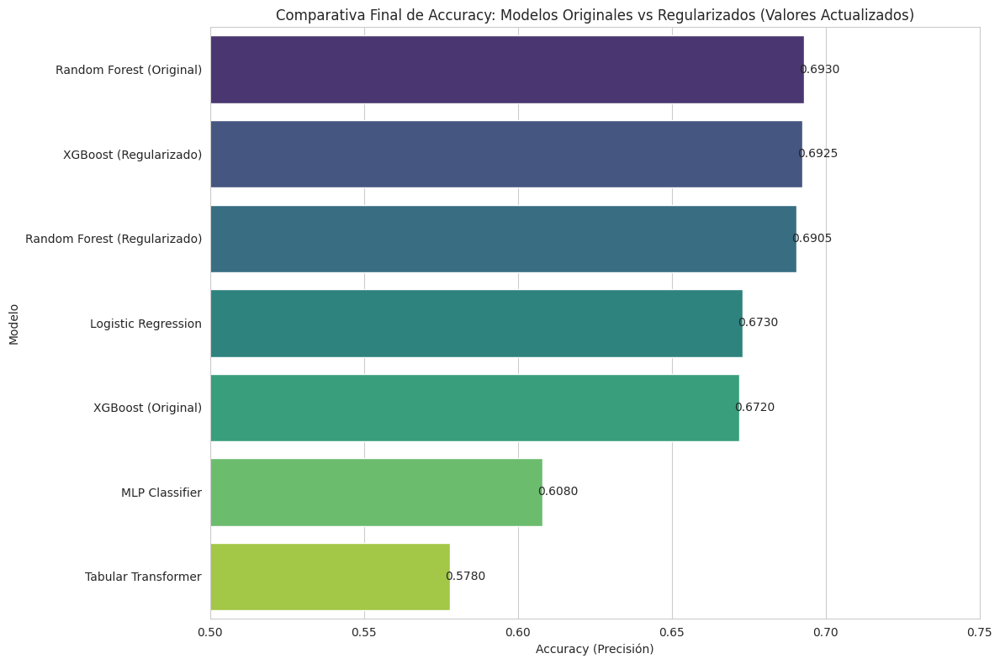

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Actualización dinámica con los valores reales de la última ejecución
model_performance_data = {
    "Logistic Regression": acc_Logistic_Regression,
    "MLP Classifier": acc_MLP_Classifier,
    "Tabular Transformer": acc_Tabular_Transformer,
    "Random Forest (Original)": acc_Random_Forest,
    "Random Forest (Regularizado)": acc_Random_Forest_Reg,
    "XGBoost (Original)": acc_XGBoost,
    "XGBoost (Regularizado)": acc_XGBoost_Reg
}

# Recrear DataFrame y ordenar
df_accuracy_compare = pd.DataFrame(list(model_performance_data.items()), columns=['Modelo', 'Accuracy'])
df_accuracy_compare = df_accuracy_compare.sort_values(by='Accuracy', ascending=False)

# Visualización
plt.figure(figsize=(12, 8))
sns.set_style("whitegrid")
ax = sns.barplot(x='Accuracy', y='Modelo', data=df_accuracy_compare, palette='viridis', hue='Modelo', legend=False)

# Añadir etiquetas de valor en las barras
for p in ax.patches:
    width = p.get_width()
    plt.text(width + 0.005, p.get_y() + p.get_height()/2.0, f'{width:.4f}', ha='center', va='center')

plt.title('Comparativa Final de Accuracy: Modelos Originales vs Regularizados (Valores Actualizados)')
plt.xlabel('Accuracy (Precisión)')
plt.ylabel('Modelo')
plt.xlim(0.5, 0.75)
plt.tight_layout()
plt.savefig('final_model_comparison_accuracy.png', dpi=300, bbox_inches='tight')
plt.show()

# Conclusiones
El dataset constaba de 1 millón de filas de datos de estudiantes relacionados con sus estudios y su salud mental. Se han entreando distintos modelos de ML Para comproba cuales eran más precisos y después medir la interpretabilidad de los mismos.
En el EDA, se ha analizado los valores numéricos más importantes frente a las categorías en las que hemos dividido el dataset. Como era de esperar, el riesgo está directametne relacionado con las variables de expectación interna y externa(apoyo familiar, expectativas familiares, estrés fianciero...) que a su vez altera las variables relacionadas con la salud, que son al final el factor delimitante a la hora de determinar si la persona va a abandonar sus estudios.

En el Apartado de ML, el random forest y la regresión lineal son los modelos de mayor eficacia a la hora de predecir la clasificación. Esto se ah debido a un overffiting que no se ha detectado en la primera iteración de los modelos. Se ha corregido a tiempo y se ha visto que el modelo con mayor precisión real era el de Xgboost coregido. Después de eso se ha vuelto ha hacer el análisis de interpretabilidad con la biblioteca SHAP.


Para reducir tiempos de ejecución, se han tomado un tamaño muestral de 1000, previa comprobación de que con samples más grandes (20000 en la iteración con más datos) las conclusiones de los modelos son las mismas, las predicciones apenas varían sobre el valor obtenido en el tamaño muestral de 1000. Aún así, cabe destacar que la mayoría de los datos de riesgo de abandono están dentro del umbral de "Low", lo que hace que sea la característica mejor predicha en todos los modelos.

En el apartado de interpretabilidad, se ve como el XGboost rápidamente descarta casi todas las variables para centrarse en una única,el burnout_score, que mide lo "quemado" que está un alumno. El resto de modelos parecen ser estables frente a iteraciones (los modelos reflejan resultados similares de predicción y toman las mismas variables como importantes sin importar la muestra aleatoria que se tome al principio). Esto no ocurre con Pytorch. En cada interacción del modelo, cada vez que se entrena, la biblioteca captum refleja que el modelo no utiliza siempre las mismas variable ni les da el mismo peso, si bien se mantiene el burnout_score como categoría domiante. De todas formas, pytorch es el modelo que peor ha predicho la categorías, así no tiene tanta importancia. El análisis de interpretabilidad de Shap del Random forest ha sido la segunda que más tarda en ejecutarse. Suponemos que la biblioteca tiene que analizar cada árbol por separado, lo que le llevará bastante tiempo.

